# Predicción de resultados del Mundial 2026 mediante modelos aditivos, Logit, Poisson, Random Forest y visualización

**Trabajo final en Google Colab**  
**Modelos trabajados:** Regresión Logística Ridge, Regresión Logística Lasso, Modelo Poisson, Random Forest, Baseline y Random Forest ajustado.  
**Enfoque:** comparación de modelos, validación temporal, interpretación matemática, métricas de clasificación y visualización 3D.




# 1. Planteamiento del problema

La predicción de resultados de fútbol es un problema complejo porque el resultado depende de factores históricos, ofensivos, defensivos, experiencia internacional y forma reciente.

La pregunta central del trabajo es:

> **¿Qué modelo predice mejor el resultado de un partido del Mundial usando información disponible antes del partido?**

## Aclaración sobre local y visitante

En Copas del Mundo, `home_team` y `away_team` no siempre significan localía real, porque muchos partidos se juegan en sede neutral.  
En este trabajo se interpretan como:

> **equipo local y visitante según el orden registrado en la base de datos.**

# 2. Objetivos

## Objetivo general

Construir, comparar e interpretar modelos predictivos para estimar resultados de partidos del Mundial usando datos históricos y modelos vistos o mencionados en clase.

## Objetivos específicos

1. Cargar e inspeccionar cinco archivos de datos.
2. Limpiar y estandarizar nombres de columnas y equipos.
3. Construir variables predictoras antes del partido.
4. Formular matemáticamente el modelo aditivo general.
5. Aplicar modelos Logit con regularización Ridge y Lasso.
6. Aplicar un modelo Poisson para goles esperados.
7. Aplicar Random Forest como modelo no lineal.
8. Evaluar los modelos mediante Accuracy, Balanced Accuracy, Precision, Recall, F1-score y ROC-AUC.
9. Generar predicciones para el Mundial 2026.

# 3. Fundamento matemático

## 3.1 Modelo aditivo general

La idea base de varios modelos estadísticos es construir un **predictor lineal aditivo**:

$$
\eta_i =
\beta_0+
\sum_{j=1}^{p}
\beta_j X_{ij}
$$

Donde:

- $i$ representa el partido.
- $j$ representa la variable predictora.
- $p$ es el número total de variables.
- $X_{ij}$ es el valor de la variable $j$ en el partido $i$.
- $\beta_j$ es el efecto o peso de la variable $j$.
- $\eta_i$ es el predictor lineal.

Si se trabajan 36 variables, entonces:

$$
\eta_i =
\beta_0+
\beta_1X_{i1}+
\beta_2X_{i2}+
\cdots+
\beta_{36}X_{i36}
$$

La diferencia entre modelos está en la función de enlace:

$$
g(\mu_i)=\eta_i
$$

---

## 3.2 Modelo Logit

Para una respuesta binaria, el modelo Logit usa:

$$
\log\left(\frac{p_i}{1-p_i}\right)
=
\beta_0+
\sum_{j=1}^{p}
\beta_jX_{ij}
$$

En este proyecto la respuesta tiene tres clases, por eso se usa una versión multiclase mediante Softmax:

$$
\hat{p}_{ik}
=
P(Y_i=k \mid X_i)
=
\frac{
\exp(\beta_{0k}+\sum_{j=1}^{p}\beta_{jk}X_{ij})
}{
\sum_{r=0}^{2}
\exp(\beta_{0r}+\sum_{j=1}^{p}\beta_{jr}X_{ij})
}
$$

La clase predicha es:

$$
\hat{Y}_i =
\arg\max_{k \in \{0,1,2\}}
\hat{p}_{ik}
$$

---

## 3.3 Regresión Logística Ridge

Ridge agrega una penalización L2 para controlar coeficientes grandes:

$$
L_{Ridge}(\beta)
=
-
\sum_{i=1}^{n}
\sum_{k=0}^{2}
\mathbf{1}_{\{y_i=k\}}
\log(\hat{p}_{ik})
+
\lambda
\sum_{j=1}^{p}
\beta_j^2
$$

La penalización Ridge es:

$$
\lambda
\sum_{j=1}^{p}
\beta_j^2
$$

---

## 3.4 Regresión Logística Lasso

Lasso agrega una penalización L1:

$$
L_{Lasso}(\beta)
=
-
\sum_{i=1}^{n}
\sum_{k=0}^{2}
\mathbf{1}_{\{y_i=k\}}
\log(\hat{p}_{ik})
+
\lambda
\sum_{j=1}^{p}
|\beta_j|
$$

La penalización Lasso es:

$$
\lambda
\sum_{j=1}^{p}
|\beta_j|
$$

Lasso puede reducir coeficientes a cero, por lo que también funciona como una forma de selección de variables.

---

## 3.5 Modelo Poisson

El modelo Poisson se usa para conteos. En fútbol, los goles son conteos:

$$
Goles = 0,1,2,3,\ldots
$$

Se modela:

$$
Y_i \sim Poisson(\lambda_i)
$$

La función de probabilidad es:

$$
P(Y_i=y_i)
=
\frac{e^{-\lambda_i}\lambda_i^{y_i}}{y_i!}
$$

La función de enlace es logarítmica:

$$
\log(\lambda_i)
=
\beta_0+
\sum_{j=1}^{p}
\beta_jX_{ij}
$$

Por tanto:

$$
\lambda_i =
\exp\left(
\beta_0+
\sum_{j=1}^{p}
\beta_jX_{ij}
\right)
$$

En este proyecto se ajustan dos modelos Poisson:

$$
GolesLocal_i \sim Poisson(\lambda_{home,i})
$$

$$
GolesVisitante_i \sim Poisson(\lambda_{away,i})
$$

Luego se convierten los goles esperados en probabilidades de resultado:

$$
P(\text{Victoria local}) = P(GolesLocal > GolesVisitante)
$$

$$
P(\text{Empate}) = P(GolesLocal = GolesVisitante)
$$

$$
P(\text{Derrota local}) = P(GolesLocal < GolesVisitante)
$$

---

## 3.6 Random Forest

Random Forest no usa una ecuación de betas.  
Construye múltiples árboles de decisión:

$$
T_1(X),T_2(X),\ldots,T_B(X)
$$

La predicción final es la votación mayoritaria:

$$
\hat{Y}
=
\operatorname{mode}
\left(
T_1(X),T_2(X),\ldots,T_B(X)
\right)
$$

La probabilidad de una clase se estima como:

$$
\hat{P}(Y=k \mid X)
=
\frac{1}{B}
\sum_{b=1}^{B}
\mathbf{1}_{\{T_b(X)=k\}}
$$

El criterio de división puede usar impureza de Gini:

$$
Gini(t)
=
1-
\sum_{k=0}^{2}
p_{k,t}^{2}
$$

# 4. Importación de librerías

In [1]:
import os
import re
import math
import unicodedata
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression, PoissonRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    auc,
    log_loss
)

pd.set_option("display.max_columns", 150)
pd.set_option("display.max_rows", 120)

RANDOM_STATE = 42
CLASSES = [0, 1, 2]
CLASS_NAMES = ["Derrota local", "Empate", "Victoria local"]
CLASS_MAP = dict(zip(CLASSES, CLASS_NAMES))

# 5. Carga de datos

El notebook acepta nombres en inglés o español para evitar errores al subir los archivos a Colab.

Archivos esperados:

- `fifa_ranking_2022-10-06.csv`
- `fifa_ranking_2026-06-08.csv`
- `matches_1930_2022.csv`
- `schedule_2026.csv`
- `world_cup.csv`

In [2]:
FILE_CANDIDATES = {
    "fifa_2022": [
        "fifa_ranking_2022-10-06.csv",
        "Clasificación_FIFA_2022-10-06.csv",
        "Clasificacion_FIFA_2022-10-06.csv"
    ],
    "fifa_2026": [
        "fifa_ranking_2026-06-08.csv",
        "Clasificación_FIFA_2026-06-08.csv",
        "Clasificacion_FIFA_2026-06-08.csv"
    ],
    "matches": [
        "matches_1930_2022.csv"
    ],
    "schedule": [
        "schedule_2026.csv"
    ],
    "world_cup": [
        "world_cup.csv",
        "Copa del Mundo.csv",
        "Copa_del_Mundo.csv"
    ]
}

def resolve_file(candidates):
    for file_name in candidates:
        if os.path.exists(file_name):
            return file_name
    return None

resolved_files = {key: resolve_file(names) for key, names in FILE_CANDIDATES.items()}
missing = [key for key, value in resolved_files.items() if value is None]

if missing:
    print("Faltan archivos:")
    for key in missing:
        print(f"- {key}: nombres aceptados -> {FILE_CANDIDATES[key]}")
    raise FileNotFoundError("Sube los archivos CSV a Colab y vuelve a ejecutar.")
else:
    print("Archivos detectados:")
    for key, value in resolved_files.items():
        print(f"{key}: {value}")

Archivos detectados:
fifa_2022: fifa_ranking_2022-10-06.csv
fifa_2026: fifa_ranking_2026-06-08.csv
matches: matches_1930_2022.csv
schedule: schedule_2026.csv
world_cup: world_cup.csv


In [3]:
def read_csv_robust(path):
    encodings = ["utf-8", "utf-8-sig", "latin1", "ISO-8859-1"]
    last_error = None

    for enc in encodings:
        try:
            return pd.read_csv(path, encoding=enc)
        except Exception as e:
            last_error = e

    raise ValueError(f"No se pudo leer {path}. Último error: {last_error}")

fifa_2022_raw = read_csv_robust(resolved_files["fifa_2022"])
fifa_2026_raw = read_csv_robust(resolved_files["fifa_2026"])
matches_raw = read_csv_robust(resolved_files["matches"])
schedule_raw = read_csv_robust(resolved_files["schedule"])
world_cup_raw = read_csv_robust(resolved_files["world_cup"])

datasets_raw = {
    "Ranking FIFA 2022": fifa_2022_raw,
    "Ranking FIFA 2026": fifa_2026_raw,
    "Partidos 1930-2022": matches_raw,
    "Calendario 2026": schedule_raw,
    "Copas del Mundo": world_cup_raw
}

summary = []
for name, df in datasets_raw.items():
    summary.append({
        "dataset": name,
        "filas": df.shape[0],
        "columnas": df.shape[1],
        "duplicados": int(df.duplicated().sum()),
        "valores_nulos": int(df.isna().sum().sum())
    })

display(pd.DataFrame(summary))

for name, df in datasets_raw.items():
    print("\n" + "="*80)
    print(name)
    print("="*80)
    print(list(df.columns))
    display(df.head(3))

,dataset,filas,columnas,duplicados,valores_nulos
0,Ranking FIFA 2022,211,7,0,0
1,Ranking FIFA 2026,211,8,0,0
2,Partidos 1930-2022,964,44,0,20914
3,Calendario 2026,72,10,0,216
4,Copas del Mundo,22,9,0,0



Ranking FIFA 2022
['team', 'team_code', 'association', 'rank', 'previous_rank', 'points', 'previous_points']


,team,team_code,association,rank,previous_rank,points,previous_points
0,Brazil,BRA,CONMEBOL,1,1,1841.30,1837.56
1,Belgium,BEL,UEFA,2,2,1816.71,1821.92
2,Argentina,ARG,CONMEBOL,3,3,1773.88,1770.65



Ranking FIFA 2026
['team', 'team_code', 'association', 'rank', 'previous_rank', 'points', 'previous_points', 'rated_matches']


,team,team_code,association,rank,previous_rank,points,previous_points,rated_matches
0,Argentina,ARG,CONMEBOL,1,3,1876.118331,1874.814835,59
1,Spain,ESP,UEFA,2,2,1873.013187,1876.395199,56
2,France,FRA,UEFA,3,1,1869.428449,1877.322731,57


...

,home_team,away_team,home_score,home_xg,home_penalty,away_score,away_xg,away_penalty,home_manager,home_captain,away_manager,away_captain,Attendance,Venue,Officials,Round,Date,Score,Referee,Notes,Host,Year,home_goal,away_goal,home_goal_long,away_goal_long,home_own_goal,away_own_goal,home_penalty_goal,away_penalty_goal,home_penalty_miss_long,away_penalty_miss_long,home_penalty_shootout_goal_long,away_penalty_shootout_goal_long,home_penalty_shootout_miss_long,away_penalty_shootout_miss_long,home_red_card,away_red_card,home_yellow_red_card,away_yellow_red_card,home_yellow_card_long,away_yellow_card_long,home_substitute_in_long,away_substitute_in_long
0,Argentina,France,3,3.3,4.0,3,2.2,2.0,Lionel Scaloni,Lionel Messi,Didier Deschamps,Hugo Lloris,88966,"Lusail Iconic Stadium, Lusail",Szymon Marciniak (Referee) · Paweł Sokolnicki ...,Final,2022-12-18,(4) 3–3 (2),Szymon Marciniak,Argentina won on penalty kicks following extra...,Qatar,2022,Ángel Di María · 36|Lionel Messi · 108,Kylian Mbappé · 81,['36&rsquor;|2:0|Ángel Di María|Assist:|Alexis...,['81&rsquor;|2:2|Kylian Mbappé|Assist:|Marcus ...,NaN,NaN,Lionel Messi (P) · 23,Kylian Mbappé (P) · 80|Kylian Mbappé (P) · 118,NaN,NaN,"['2|1:1|Lionel Messi', '4|2:1|Paulo Dybala', '...","['1|0:1|Kylian Mbappé', '7|3:2|Randal Kolo Mua...",NaN,"['3|1:1|Kingsley Coman', '5|2:1|Aurélien Tchou...",NaN,NaN,NaN,NaN,"['45+7&rsquor;|2:0|Enzo Fernández', '90+8&rsqu...","['55&rsquor;|2:0|Adrien Rabiot', '87&rsquor;|2...",['64&rsquor;|2:0|Marcos Acuña|for Ángel Di Mar...,['41&rsquor;|2:0|Randal Kolo Muani|for Ousmane...
1,Croatia,Morocco,2,0.7,NaN,1,1.2,NaN,Zlatko Dalić,Luka Modrić,Hoalid Regragui,Hakim Ziyech,44137,"Khalifa International Stadium, Doha",Abdulrahman Ibrahim Al Jassim (Referee) · Tale...,Third-place match,2022-12-17,2–1,Abdulrahman Ibrahim Al Jassim,NaN,Qatar,2022,Joško Gvardiol · 7|Mislav Oršić · 42,Achraf Dari · 9,['7&rsquor;|1:0|Joško Gvardiol|Assist:|Ivan Pe...,['9&rsquor;|1:1|Achraf Dari'],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"['69&rsquor;|2:1|Azzedine Ounahi', '84&rsquor;...",['61&rsquor;|2:1|Nikola Vlašić|for Andrej Kram...,['46&rsquor;|2:1|Ilias Chair|for Abdelhamid Sa...
2,France,Morocco,2,2.0,NaN,0,0.9,NaN,Didier Deschamps,Hugo Lloris,Hoalid Regragui,Romain Saïss,68294,"Al Bayt Stadium, Al Khor",César Arturo Ramos (Referee) · Alberto Morín (...,Semi-finals,2022-12-14,2–0,César Arturo Ramos,NaN,Qatar,2022,Theo Hernández · 5|Randal Kolo Muani · 79,NaN,"['5&rsquor;|1:0|Theo Hernández', '79&rsquor;|2...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,['27&rsquor;|1:0|Sofiane Boufal'],['65&rsquor;|1:0|Marcus Thuram|for Olivier Gir...,['21&rsquor;|1:0|Selim Amallah|for Romain Saïs...



Calendario 2026
['Round', 'Day', 'Date', 'Time', 'Score', 'Referee', 'Notes', 'Year', 'home_team', 'away_team']


,Round,Day,Date,Time,Score,Referee,Notes,Year,home_team,away_team
0,Group stage,Thu,2026-06-11,13:00 (22:00),NaN,NaN,NaN,2026,Mexico,South Africa
1,Group stage,Thu,2026-06-11,20:00 (05:00),NaN,NaN,NaN,2026,Korea Republic,Czechia
2,Group stage,Fri,2026-06-12,15:00 (22:00),NaN,NaN,NaN,2026,Canada,Bosnia-Herzegovina



Copas del Mundo
['Year', 'Host', 'Teams', 'Champion', 'Runner-Up', 'TopScorrer', 'Attendance', 'AttendanceAvg', 'Matches']


,Year,Host,Teams,Champion,Runner-Up,TopScorrer,Attendance,AttendanceAvg,Matches
0,2022,Qatar,32,Argentina,France,Kylian Mbappé - 8,3404252,53191,64
1,2018,Russia,32,France,Croatia,Harry Kane - 6,3031768,47371,64
2,2014,Brazil,32,Germany,Argentina,James Rodríguez - 6,3429873,53592,64


# 6. Limpieza de nombres y equipos

In [4]:
def remove_accents(text):
    if pd.isna(text):
        return text
    text = str(text)
    return "".join(
        char for char in unicodedata.normalize("NFKD", text)
        if not unicodedata.combining(char)
    )

def clean_column_name(col):
    col = remove_accents(str(col)).lower().strip()
    col = re.sub(r"[^a-z0-9]+", "_", col)
    col = re.sub(r"_+", "_", col).strip("_")
    return col

def clean_columns(df):
    out = df.copy()
    out.columns = [clean_column_name(c) for c in out.columns]
    return out

def standardize_team_name(name):
    if pd.isna(name):
        return np.nan

    name = remove_accents(str(name)).lower().strip()
    name = name.replace("&", " and ")
    name = re.sub(r"[^a-z0-9 ]+", " ", name)
    name = re.sub(r"\s+", " ", name).strip()

    replacements = {
        "usa": "united states",
        "u s a": "united states",
        "united states of america": "united states",
        "usmnt": "united states",
        "ir iran": "iran",
        "iran islamic republic": "iran",
        "korea republic": "south korea",
        "republic of korea": "south korea",
        "korea south": "south korea",
        "cote d ivoire": "ivory coast",
        "czechia": "czech republic",
        "soviet union": "russia",
        "russian federation": "russia",
        "germany fr": "germany",
        "west germany": "germany",
        "german dr": "germany",
        "east germany": "germany",
        "china pr": "china",
        "china people s republic": "china",
        "trinidad tobago": "trinidad and tobago",
        "bosnia herzegovina": "bosnia and herzegovina"
    }

    return replacements.get(name, name)

fifa_2022 = clean_columns(fifa_2022_raw)
fifa_2026 = clean_columns(fifa_2026_raw)
matches = clean_columns(matches_raw)
schedule = clean_columns(schedule_raw)
world_cup = clean_columns(world_cup_raw)

print("Columnas estandarizadas.")
print("matches:", list(matches.columns))

Columnas estandarizadas.
matches: ['home_team', 'away_team', 'home_score', 'home_xg', 'home_penalty', 'away_score', 'away_xg', 'away_penalty', 'home_manager', 'home_captain', 'away_manager', 'away_captain', 'attendance', 'venue', 'officials', 'round', 'date', 'score', 'referee', 'notes', 'host', 'year', 'home_goal', 'away_goal', 'home_goal_long', 'away_goal_long', 'home_own_goal', 'away_own_goal', 'home_penalty_goal', 'away_penalty_goal', 'home_penalty_miss_long', 'away_penalty_miss_long', 'home_penalty_shootout_goal_long', 'away_penalty_shootout_goal_long', 'home_penalty_shootout_miss_long', 'away_penalty_shootout_miss_long', 'home_red_card', 'away_red_card', 'home_yellow_red_card', 'away_yellow_red_card', 'home_yellow_card_long', 'away_yellow_card_long', 'home_substitute_in_long', 'away_substitute_in_long']


### 6.1 Validación final

Se verificó que los nombres de equipos y variables estén estandarizados para evitar errores de escritura y facilitar la integración entre datasets.

Esta limpieza mejora la calidad de los datos y permite continuar con el análisis exploratorio y los modelos predictivos.

# 7. Detección automática de columnas importantes

In [5]:
def find_col(df, candidates, required=True, label="columna"):
    cols = list(df.columns)

    for c in candidates:
        if c in cols:
            return c

    for c in candidates:
        for col in cols:
            if c in col:
                return col

    if required:
        raise KeyError(
            f"No se encontró {label}. Candidatos: {candidates}. "
            f"Columnas disponibles: {cols}"
        )
    return None

home_team_col = find_col(
    matches,
    ["home_team", "home_team_name", "home", "team_home", "equipo_local", "local"],
    label="equipo local"
)

away_team_col = find_col(
    matches,
    ["away_team", "away_team_name", "away", "team_away", "equipo_visitante", "visitante"],
    label="equipo visitante"
)

home_score_col = find_col(
    matches,
    ["home_score", "home_team_score", "home_goals", "score_home", "goles_local"],
    label="goles local"
)

away_score_col = find_col(
    matches,
    ["away_score", "away_team_score", "away_goals", "score_away", "goles_visitante"],
    label="goles visitante"
)

date_col = find_col(
    matches,
    ["date", "match_date", "fecha", "datetime"],
    required=False,
    label="fecha"
)

year_col = find_col(
    matches,
    ["year", "anio", "ano", "season"],
    required=False,
    label="año"
)

print("Columnas detectadas:")
print("Equipo local:", home_team_col)
print("Equipo visitante:", away_team_col)
print("Goles local:", home_score_col)
print("Goles visitante:", away_score_col)
print("Fecha:", date_col)
print("Año:", year_col)

Columnas detectadas:
Equipo local: home_team
Equipo visitante: away_team
Goles local: home_score
Goles visitante: away_score
Fecha: date
Año: year


### 7.1 Validación de columnas clave

Luego de detectar automáticamente las columnas principales, se verificó que el dataset contenga las variables necesarias para el análisis futbolístico y predictivo.

| Variable detectada | Uso en el análisis |
|---|---|
| `home_team` | Identificar al equipo local |
| `away_team` | Identificar al equipo visitante |
| `home_score` | Calcular goles del equipo local |
| `away_score` | Calcular goles del equipo visitante |
| `date` | Analizar la fecha del partido |
| `year` | Filtrar partidos por año |

Esta etapa garantiza que las columnas esenciales estén disponibles antes de construir nuevas variables y aplicar los modelos predictivos.

In [6]:
def detect_fifa_columns(df, label):
    team_col = find_col(
        df,
        ["country_full", "country", "team", "team_name", "national_team", "country_name", "seleccion", "nation"],
        label=f"selección en {label}"
    )
    rank_col = find_col(
        df,
        ["rank", "ranking", "fifa_rank", "position", "pos", "rk"],
        label=f"ranking en {label}"
    )
    points_col = find_col(
        df,
        ["total_points", "points", "fifa_points", "pts", "score"],
        required=False,
        label=f"puntos FIFA en {label}"
    )
    return team_col, rank_col, points_col

fifa2022_team_col, fifa2022_rank_col, fifa2022_points_col = detect_fifa_columns(fifa_2022, "FIFA 2022")
fifa2026_team_col, fifa2026_rank_col, fifa2026_points_col = detect_fifa_columns(fifa_2026, "FIFA 2026")

print("FIFA 2022:", fifa2022_team_col, fifa2022_rank_col, fifa2022_points_col)
print("FIFA 2026:", fifa2026_team_col, fifa2026_rank_col, fifa2026_points_col)

FIFA 2022: team rank points
FIFA 2026: team rank points


## 8. Preparación del dataset histórico

En esta etapa se prepara la base histórica para crear la variable objetivo y entrenar los modelos.

Los goles se usan para definir el resultado del partido y para el modelo Poisson, porque este predice cantidad de goles.

No se usan como variables predictoras en Logit ni Random Forest, porque los goles son información del resultado final y no se conocen antes del partido.

Por ello, los modelos predictivos usan variables previas, como ranking FIFA, puntos y diferencia entre equipos.

In [7]:
matches_model = matches.copy()

matches_model["home_team_std"] = matches_model[home_team_col].apply(standardize_team_name)
matches_model["away_team_std"] = matches_model[away_team_col].apply(standardize_team_name)
matches_model["home_goals"] = pd.to_numeric(matches_model[home_score_col], errors="coerce")
matches_model["away_goals"] = pd.to_numeric(matches_model[away_score_col], errors="coerce")

matches_model = matches_model.dropna(
    subset=["home_team_std", "away_team_std", "home_goals", "away_goals"]
).copy()

matches_model["home_goals"] = matches_model["home_goals"].astype(int)
matches_model["away_goals"] = matches_model["away_goals"].astype(int)

def define_target(row):
    if row["home_goals"] > row["away_goals"]:
        return 2
    elif row["home_goals"] < row["away_goals"]:
        return 0
    else:
        return 1

matches_model["target"] = matches_model.apply(define_target, axis=1)

if date_col is not None:
    matches_model["match_date_clean"] = pd.to_datetime(matches_model[date_col], errors="coerce")
    matches_model["match_year"] = matches_model["match_date_clean"].dt.year
elif year_col is not None:
    matches_model["match_year"] = pd.to_numeric(matches_model[year_col], errors="coerce")
    matches_model["match_date_clean"] = pd.to_datetime(
        matches_model["match_year"].astype("Int64").astype(str) + "-01-01",
        errors="coerce"
    )
else:
    raise KeyError("No se encontró fecha ni año. Se necesita una variable temporal.")

matches_model = matches_model.dropna(subset=["match_year"]).copy()
matches_model["match_year"] = matches_model["match_year"].astype(int)

matches_model = matches_model.sort_values(["match_date_clean", "match_year"]).reset_index(drop=True)

print("Dataset preparado:", matches_model.shape)
display(matches_model[["match_year", "home_team_std", "away_team_std", "home_goals", "away_goals", "target"]].head())
display(matches_model["target"].map(CLASS_MAP).value_counts().rename("frecuencia").to_frame())

Dataset preparado: (964, 51)


,match_year,home_team_std,away_team_std,home_goals,away_goals,target
0,1930,united states,belgium,3,0,2
1,1930,france,mexico,4,1,2
2,1930,yugoslavia,brazil,2,1,2
3,1930,romania,peru,3,1,2
4,1930,argentina,france,1,0,2


,frecuencia
target,
Victoria local,532
Derrota local,218
Empate,214


### Interpretación

La base histórica preparada contiene **964 partidos** y **51 variables**.  
La variable objetivo `target` clasifica cada partido en victoria local, derrota local o empate.

La mayor frecuencia corresponde a **victoria local** con 532 casos, seguida de derrota local y empate.  
Esto muestra un ligero desbalance en las clases, aspecto importante para evaluar correctamente los modelos predictivos.

## 9. Uso de `world_cup.csv`: variable de anfitrión

Se utiliza el archivo `world_cup.csv` para identificar el país anfitrión de cada Mundial.

Con esta información se crean variables que indican si el equipo local o visitante jugó como anfitrión:

- `home_is_host`: vale 1 si el equipo local es anfitrión; caso contrario, 0.
- `away_is_host`: vale 1 si el equipo visitante es anfitrión; caso contrario, 0.
- `host_advantage_diff`: mide la diferencia de ventaja por sede entre ambos equipos.

| Valor de `host_advantage_diff` | Interpretación |
|---|---|
| `1` | Ventaja para el equipo local |
| `0` | Sin ventaja clara de anfitrión |
| `-1` | Ventaja para el equipo visitante |

Esta variable permite incluir en el modelo el posible efecto de jugar como país anfitrión.

In [8]:
def split_hosts(host_text):
    if pd.isna(host_text):
        return []
    text = remove_accents(str(host_text)).lower()
    text = text.replace("&", " and ")
    text = re.sub(r"\band\b", ",", text)
    text = re.sub(r"/|;|\|", ",", text)
    parts = [standardize_team_name(p) for p in text.split(",")]
    parts = [p for p in parts if isinstance(p, str) and len(p) > 0]
    return parts

wc_year_col = find_col(
    world_cup,
    ["year", "anio", "ano", "edition", "edicion"],
    required=False,
    label="año en world_cup"
)

wc_host_col = find_col(
    world_cup,
    ["host_country", "hosts", "host", "host_nation", "sede", "pais_anfitrion", "country"],
    required=False,
    label="anfitrión en world_cup"
)

host_map = {}

if wc_year_col is not None and wc_host_col is not None:
    wc_tmp = world_cup.copy()
    wc_tmp["wc_year"] = pd.to_numeric(wc_tmp[wc_year_col], errors="coerce")
    wc_tmp = wc_tmp.dropna(subset=["wc_year"])
    wc_tmp["wc_year"] = wc_tmp["wc_year"].astype(int)
    wc_tmp["hosts_std"] = wc_tmp[wc_host_col].apply(split_hosts)
    host_map = dict(zip(wc_tmp["wc_year"], wc_tmp["hosts_std"]))
    display(wc_tmp[[wc_year_col, wc_host_col, "hosts_std"]].head(20))
else:
    print("No se detectaron columnas de año y anfitrión. Las variables de anfitrión serán 0.")

def is_host_team(year, team):
    hosts = host_map.get(int(year), [])
    return int(team in hosts)

matches_model["home_is_host"] = matches_model.apply(
    lambda r: is_host_team(r["match_year"], r["home_team_std"]), axis=1
)
matches_model["away_is_host"] = matches_model.apply(
    lambda r: is_host_team(r["match_year"], r["away_team_std"]), axis=1
)
matches_model["host_advantage_diff"] = matches_model["home_is_host"] - matches_model["away_is_host"]

display(matches_model[["match_year", "home_team_std", "away_team_std", "home_is_host", "away_is_host", "host_advantage_diff"]].head())

,year,host,hosts_std
0,2022,Qatar,[qatar]
1,2018,Russia,[russia]
2,2014,Brazil,[brazil]
3,2010,South Africa,[south africa]
4,2006,Germany,[germany]
5,2002,"Korea Republic, Japan","[south korea, japan]"
6,1998,France,[france]
7,1994,United States,[united states]
8,1990,Italy,[italy]
9,1986,Mexico,[mexico]


,match_year,home_team_std,away_team_std,home_is_host,away_is_host,host_advantage_diff
0,1930,united states,belgium,0,0,0
1,1930,france,mexico,0,0,0
2,1930,yugoslavia,brazil,0,0,0
3,1930,romania,peru,0,0,0
4,1930,argentina,france,0,0,0


### Interpretación

Se identificó el país anfitrión de cada Mundial y se comparó con los equipos de cada partido.  
Con ello se crearon variables que indican si el equipo local o visitante jugó como sede.

En las primeras filas, `host_advantage_diff` toma valor 0 porque ninguno de los equipos era anfitrión.  
Esta variable permitirá evaluar si la condición de anfitrión influye en el resultado del partido.

# 10. Análisis exploratorio de datos

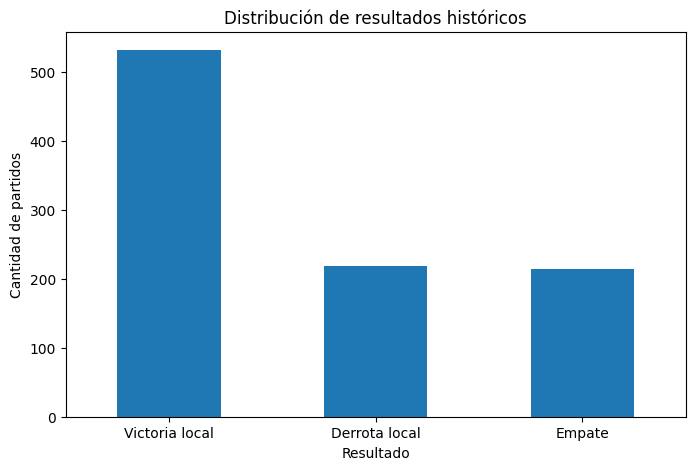

,frecuencia
target,
Victoria local,532
Derrota local,218
Empate,214


In [9]:
target_counts = matches_model["target"].map(CLASS_MAP).value_counts()

plt.figure(figsize=(8, 5))
target_counts.plot(kind="bar")
plt.title("Distribución de resultados históricos")
plt.xlabel("Resultado")
plt.ylabel("Cantidad de partidos")
plt.xticks(rotation=0)
plt.show()

display(target_counts.rename("frecuencia").to_frame())

### Interpretación

La distribución muestra que la categoría más frecuente es **Victoria local** con 532 partidos.  
En cambio, **Derrota local** y **Empate** tienen frecuencias similares, con 218 y 214 casos respectivamente.

Esto indica que existe un **desbalance moderado** en la variable objetivo, ya que el modelo tendrá más ejemplos de victorias locales que de las otras clases.

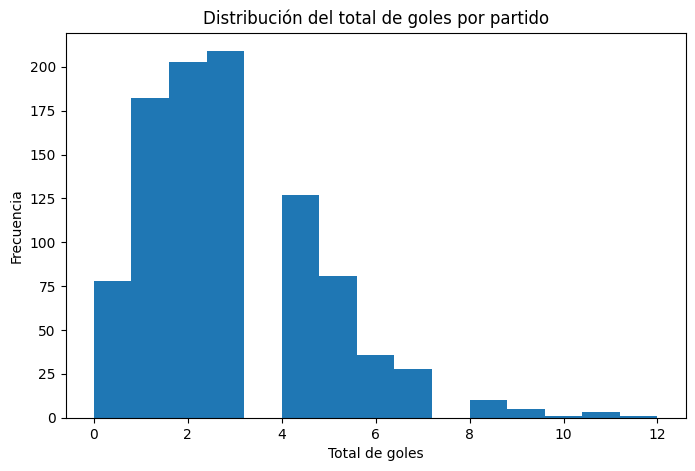

,total_goals
count,964.000000
mean,2.821577
std,1.927371
min,0.000000
25%,1.000000
50%,3.000000
75%,4.000000
max,12.000000


In [10]:
matches_model["total_goals"] = matches_model["home_goals"] + matches_model["away_goals"]

plt.figure(figsize=(8, 5))
plt.hist(matches_model["total_goals"].dropna(), bins=15)
plt.title("Distribución del total de goles por partido")
plt.xlabel("Total de goles")
plt.ylabel("Frecuencia")
plt.show()

display(matches_model["total_goals"].describe().to_frame())

### Interpretación

La distribución muestra que la mayoría de partidos tuvo entre **1 y 4 goles** en total.  
El promedio fue de aproximadamente **2.82 goles por partido**, mientras que la mediana fue **3 goles**.

También se observa que existen pocos partidos con muchos goles, llegando hasta un máximo de **12 goles**.  
Esto indica una distribución con ligera concentración en resultados normales y algunos casos extremos.

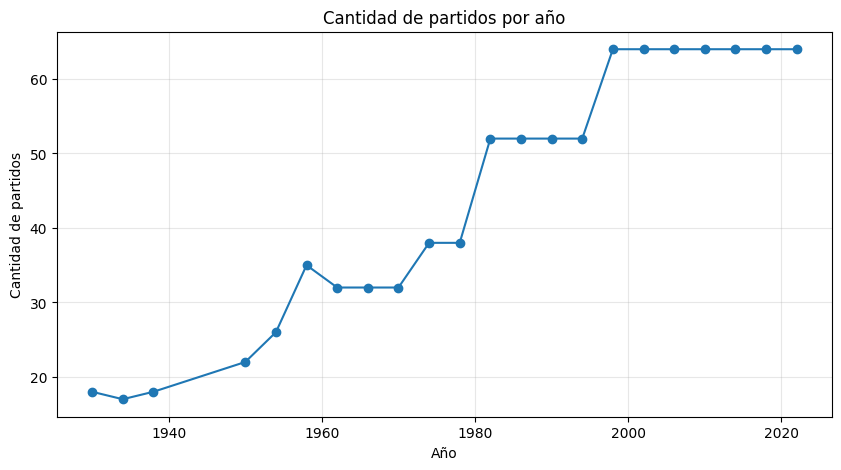

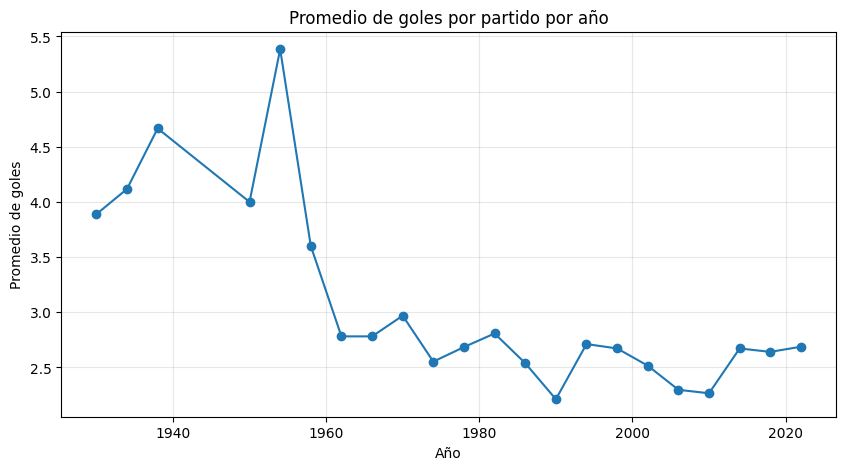

In [11]:
matches_by_year = matches_model.groupby("match_year").size()
goals_by_year = matches_model.groupby("match_year")["total_goals"].mean()

plt.figure(figsize=(10, 5))
matches_by_year.plot(kind="line", marker="o")
plt.title("Cantidad de partidos por año")
plt.xlabel("Año")
plt.ylabel("Cantidad de partidos")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 5))
goals_by_year.plot(kind="line", marker="o")
plt.title("Promedio de goles por partido por año")
plt.xlabel("Año")
plt.ylabel("Promedio de goles")
plt.grid(True, alpha=0.3)
plt.show()

### Interpretación

La primera gráfica muestra que la cantidad de partidos por Mundial ha aumentado con el tiempo.  
Esto se debe a que el torneo fue incorporando más selecciones y, por lo tanto, más encuentros por edición.

La segunda gráfica muestra que el promedio de goles por partido fue más alto en los primeros Mundiales, especialmente antes de 1960.  
Luego, el promedio disminuye y se mantiene más estable en las ediciones recientes, alrededor de 2 a 3 goles por partido.

En conclusión, los Mundiales actuales tienen más partidos, pero un promedio de goles más controlado. Esto puede estar relacionado con una mayor organización táctica, mejor preparación defensiva y mayor equilibrio entre selecciones.

# 11. Ranking FIFA como contexto

El ranking FIFA 2022 no se usa para entrenar partidos históricos, porque sería incorrecto aplicar un ranking actual a partidos antiguos.  
El ranking FIFA 2026 se usa como contexto en la tabla final de predicciones.

Top 10 Ranking FIFA 2022


,team_std,fifa_rank,fifa_points
0,brazil,1,1841.30
1,belgium,2,1816.71
2,argentina,3,1773.88
3,france,4,1759.78
4,england,5,1728.47
5,italy,6,1726.14
6,spain,7,1715.22
7,netherlands,8,1694.51
8,portugal,9,1676.56
9,denmark,10,1666.57


Top 10 Ranking FIFA 2026


,team_std,fifa_rank,fifa_points
0,argentina,1,1876.118331
1,spain,2,1873.013187
2,france,3,1869.428449
3,england,4,1827.048678
4,portugal,5,1766.177547
5,brazil,6,1765.856297
6,morocco,7,1755.100232
7,netherlands,8,1751.097835
8,belgium,9,1742.235945
9,germany,10,1735.771984


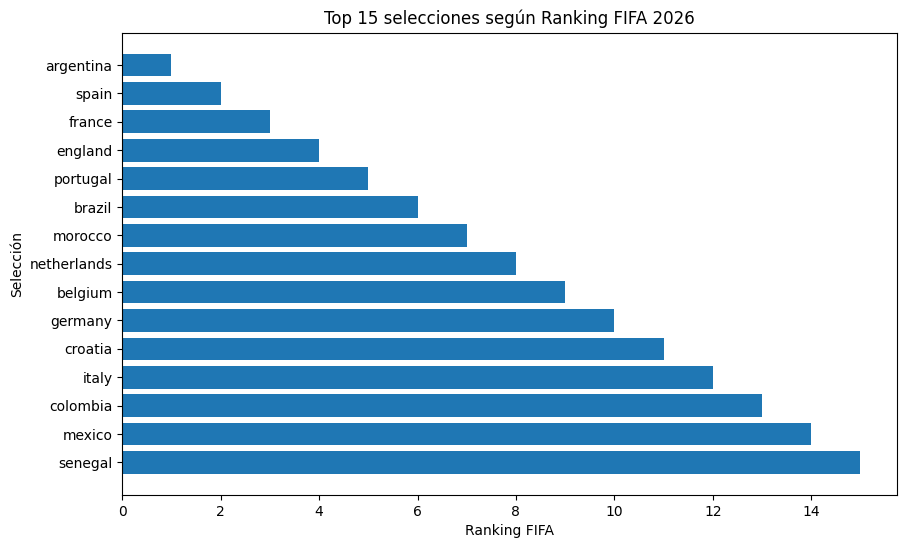

In [12]:
def prepare_fifa_table(fifa_df, team_col, rank_col, points_col=None):
    out = fifa_df.copy()
    out["team_std"] = out[team_col].apply(standardize_team_name)
    out["fifa_rank"] = pd.to_numeric(out[rank_col], errors="coerce")

    if points_col is not None and points_col in out.columns:
        out["fifa_points"] = pd.to_numeric(out[points_col], errors="coerce")
    else:
        out["fifa_points"] = np.nan

    out = out.dropna(subset=["team_std", "fifa_rank"])
    out = out.sort_values("fifa_rank").drop_duplicates("team_std", keep="first")
    return out[["team_std", "fifa_rank", "fifa_points"]]

fifa2022_table = prepare_fifa_table(fifa_2022, fifa2022_team_col, fifa2022_rank_col, fifa2022_points_col)
fifa2026_table = prepare_fifa_table(fifa_2026, fifa2026_team_col, fifa2026_rank_col, fifa2026_points_col)

print("Top 10 Ranking FIFA 2022")
display(fifa2022_table.head(10))

print("Top 10 Ranking FIFA 2026")
display(fifa2026_table.head(10))

top_2026 = fifa2026_table.head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_2026["team_std"], top_2026["fifa_rank"])
plt.title("Top 15 selecciones según Ranking FIFA 2026")
plt.xlabel("Ranking FIFA")
plt.ylabel("Selección")
plt.gca().invert_yaxis()
plt.show()

### Interpretación

El gráfico muestra el **Top 15 de selecciones según el Ranking FIFA 2026**.  
En este ranking, **un número menor representa una mejor posición**.

Se observa que **Argentina** ocupa el primer lugar, seguida por **España, Francia, Inglaterra y Portugal**, lo que indica que son las selecciones mejor posicionadas.

También aparecen selecciones fuertes como **Brasil, Países Bajos, Bélgica, Alemania e Italia**, que se mantienen dentro de los primeros puestos.

En conclusión, este ranking permite identificar qué equipos llegan con mayor nivel competitivo al Mundial 2026 y puede usarse como variable importante para los modelos predictivos.

## 12. Ingeniería de variables antes del partido

En esta etapa se construyen variables que resumen el rendimiento de cada selección **antes de jugar cada partido**.  
Esto es importante porque evita la **fuga de información**, es decir, no se usan datos del partido que se quiere predecir.

---

### Variables acumuladas por selección

Para cada equipo se calculan las siguientes métricas históricas:

#### 1. Porcentaje de victorias previas

$$
WinRate_t = \frac{\text{Victorias previas}}{\text{Partidos previos}}
$$

Indica qué proporción de partidos ganó una selección antes del encuentro.

---

#### 2. Promedio de puntos por partido

$$
PPM_t = \frac{\text{Puntos previos}}{\text{Partidos previos}}
$$

Mide cuántos puntos obtiene en promedio una selección por partido.

---

#### 3. Promedio de goles a favor

$$
GFavg_t = \frac{\text{Goles a favor previos}}{\text{Partidos previos}}
$$

Representa el promedio de goles anotados por la selección.

---

#### 4. Promedio de goles en contra

$$
GAavg_t = \frac{\text{Goles en contra previos}}{\text{Partidos previos}}
$$

Representa el promedio de goles recibidos por la selección.

---

#### 5. Diferencia promedio de goles

$$
GDavg_t = GFavg_t - GAavg_t
$$

Mide la diferencia entre los goles anotados y los goles recibidos.

---

### Forma reciente del equipo

Además de las estadísticas acumuladas, se calculan estas mismas métricas usando solo los **últimos 5 partidos previos**.

Esto permite medir si una selección llega con buen o mal rendimiento reciente antes del partido.

---

### Conclusión

Estas variables ayudan al modelo a comparar el nivel histórico y actual de cada selección usando únicamente información disponible antes del encuentro.

In [13]:
def empty_stats():
    return {
        "matches": 0,
        "wins": 0,
        "draws": 0,
        "losses": 0,
        "gf": 0,
        "ga": 0,
        "points": 0,
        "recent_points": [],
        "recent_gf": [],
        "recent_ga": []
    }

def calculate_rates(stats):
    m = stats["matches"]

    if m == 0:
        return {
            "matches_before": 0,
            "win_rate_before": np.nan,
            "draw_rate_before": np.nan,
            "loss_rate_before": np.nan,
            "gf_avg_before": np.nan,
            "ga_avg_before": np.nan,
            "gd_avg_before": np.nan,
            "ppm_before": np.nan,
            "recent_ppm_5": np.nan,
            "recent_gf_avg_5": np.nan,
            "recent_ga_avg_5": np.nan
        }

    recent_points = stats["recent_points"][-5:]
    recent_gf = stats["recent_gf"][-5:]
    recent_ga = stats["recent_ga"][-5:]

    return {
        "matches_before": m,
        "win_rate_before": stats["wins"] / m,
        "draw_rate_before": stats["draws"] / m,
        "loss_rate_before": stats["losses"] / m,
        "gf_avg_before": stats["gf"] / m,
        "ga_avg_before": stats["ga"] / m,
        "gd_avg_before": (stats["gf"] - stats["ga"]) / m,
        "ppm_before": stats["points"] / m,
        "recent_ppm_5": np.mean(recent_points) if len(recent_points) > 0 else np.nan,
        "recent_gf_avg_5": np.mean(recent_gf) if len(recent_gf) > 0 else np.nan,
        "recent_ga_avg_5": np.mean(recent_ga) if len(recent_ga) > 0 else np.nan
    }

def build_historical_features(df):
    df = df.sort_values(["match_date_clean", "match_year"]).reset_index(drop=True).copy()
    stats_by_team = {}
    rows = []

    for _, row in df.iterrows():
        home = row["home_team_std"]
        away = row["away_team_std"]
        hg = int(row["home_goals"])
        ag = int(row["away_goals"])

        if home not in stats_by_team:
            stats_by_team[home] = empty_stats()
        if away not in stats_by_team:
            stats_by_team[away] = empty_stats()

        home_rates = calculate_rates(stats_by_team[home])
        away_rates = calculate_rates(stats_by_team[away])

        feature_row = row.to_dict()

        for key, value in home_rates.items():
            feature_row[f"home_{key}"] = value
        for key, value in away_rates.items():
            feature_row[f"away_{key}"] = value

        feature_row["diff_win_rate"] = feature_row["home_win_rate_before"] - feature_row["away_win_rate_before"]
        feature_row["diff_draw_rate"] = feature_row["home_draw_rate_before"] - feature_row["away_draw_rate_before"]
        feature_row["diff_loss_rate"] = feature_row["home_loss_rate_before"] - feature_row["away_loss_rate_before"]
        feature_row["diff_gf_avg"] = feature_row["home_gf_avg_before"] - feature_row["away_gf_avg_before"]
        feature_row["diff_ga_avg"] = feature_row["home_ga_avg_before"] - feature_row["away_ga_avg_before"]
        feature_row["diff_gd_avg"] = feature_row["home_gd_avg_before"] - feature_row["away_gd_avg_before"]
        feature_row["diff_ppm"] = feature_row["home_ppm_before"] - feature_row["away_ppm_before"]
        feature_row["diff_recent_ppm_5"] = feature_row["home_recent_ppm_5"] - feature_row["away_recent_ppm_5"]
        feature_row["diff_recent_gf_avg_5"] = feature_row["home_recent_gf_avg_5"] - feature_row["away_recent_gf_avg_5"]
        feature_row["diff_recent_ga_avg_5"] = feature_row["home_recent_ga_avg_5"] - feature_row["away_recent_ga_avg_5"]
        feature_row["diff_experience"] = feature_row["home_matches_before"] - feature_row["away_matches_before"]

        rows.append(feature_row)

        if hg > ag:
            home_points, away_points = 3, 0
            stats_by_team[home]["wins"] += 1
            stats_by_team[away]["losses"] += 1
        elif hg < ag:
            home_points, away_points = 0, 3
            stats_by_team[away]["wins"] += 1
            stats_by_team[home]["losses"] += 1
        else:
            home_points, away_points = 1, 1
            stats_by_team[home]["draws"] += 1
            stats_by_team[away]["draws"] += 1

        for team, gf, ga, pts in [(home, hg, ag, home_points), (away, ag, hg, away_points)]:
            stats_by_team[team]["matches"] += 1
            stats_by_team[team]["gf"] += gf
            stats_by_team[team]["ga"] += ga
            stats_by_team[team]["points"] += pts
            stats_by_team[team]["recent_points"].append(pts)
            stats_by_team[team]["recent_gf"].append(gf)
            stats_by_team[team]["recent_ga"].append(ga)

    return pd.DataFrame(rows), stats_by_team

features_df, final_team_stats = build_historical_features(matches_model)

print("Dataset con variables predictoras:", features_df.shape)
display(features_df.head(3))

Dataset con variables predictoras: (964, 88)


,home_team,away_team,home_score,home_xg,home_penalty,away_score,away_xg,away_penalty,home_manager,home_captain,away_manager,away_captain,attendance,venue,officials,round,date,score,referee,notes,host,year,home_goal,away_goal,home_goal_long,away_goal_long,home_own_goal,away_own_goal,home_penalty_goal,away_penalty_goal,home_penalty_miss_long,away_penalty_miss_long,home_penalty_shootout_goal_long,away_penalty_shootout_goal_long,home_penalty_shootout_miss_long,away_penalty_shootout_miss_long,home_red_card,away_red_card,home_yellow_red_card,away_yellow_red_card,home_yellow_card_long,away_yellow_card_long,home_substitute_in_long,away_substitute_in_long,home_team_std,away_team_std,home_goals,away_goals,target,match_date_clean,match_year,home_is_host,away_is_host,host_advantage_diff,total_goals,home_matches_before,home_win_rate_before,home_draw_rate_before,home_loss_rate_before,home_gf_avg_before,home_ga_avg_before,home_gd_avg_before,home_ppm_before,home_recent_ppm_5,home_recent_gf_avg_5,home_recent_ga_avg_5,away_matches_before,away_win_rate_before,away_draw_rate_before,away_loss_rate_before,away_gf_avg_before,away_ga_avg_before,away_gd_avg_before,away_ppm_before,away_recent_ppm_5,away_recent_gf_avg_5,away_recent_ga_avg_5,diff_win_rate,diff_draw_rate,diff_loss_rate,diff_gf_avg,diff_ga_avg,diff_gd_avg,diff_ppm,diff_recent_ppm_5,diff_recent_gf_avg_5,diff_recent_ga_avg_5,diff_experience
0,United States,Belgium,3,NaN,NaN,0,NaN,NaN,Bob Millar,Tom Florie,Hector Goetinck,Pierre Braine,18346,"Parque Central, Montevideo",Jose Macias (Referee) · Francisco Mateucci (AR...,Group stage,1930-07-13,3–0,Jose Macias,NaN,Uruguay,1930,Bart McGhee · 23|Tom Florie · 45|Bert Patenaud...,NaN,"['23&rsquor;|1:0|Bart McGhee', '45&rsquor;|2:0...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,united states,belgium,3,0,2,1930-07-13,1930,0,0,0,3,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,France,Mexico,4,NaN,NaN,1,NaN,NaN,Raoul Caudron,Alexandre Villaplane,Juan Luque,Rafael Garza Gutiérrez,4444,"Pocitos, Montevideo",Domingo Lombardi (Referee) · Henry Cristophe (...,Group stage,1930-07-13,4–1,Domingo Lombardi,NaN,Uruguay,1930,Lucien Laurent · 19|Marcel Langiller · 40|Andr...,Juan Carreño · 70,"['19&rsquor;|1:0|Lucien Laurent', '40&rsquor;|...",['70&rsquor;|3:1|Juan Carreño'],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,france,mexico,4,1,2,1930-07-13,1930,0,0,0,5,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
2,Yugoslavia,Brazil,2,NaN,NaN,1,NaN,NaN,Bosko Simonovic,Milutin Ivković,Pindaro De Carvalho,Preguinho,24059,"Parque Central, Montevideo",Anibal Tejada (Referee) · Ricardo Vallarino (A...,Group stage,1930-07-14,2–1,Anibal Tejada,NaN,Uruguay,1930,Aleksandar Tirnanić · 21|Ivan Bek · 30,Preguinho · 62,"['21&rsquor;|1:0|Aleksandar Tirnanić', '30&rsq...",['62&rsquor;|2:1|Preguinho'],NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,yugoslavia,brazil,2,1,2,1930-07-14,1930,0,0,0,3,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


# 13. Variables predictoras finales

Estas variables se usan en Logit, Ridge, Lasso, Poisson y Random Forest.

No se incluyen como predictores:

- `home_goals`
- `away_goals`
- `total_goals`
- `target`

In [14]:
model_features = [
    "home_matches_before",
    "away_matches_before",
    "home_win_rate_before",
    "away_win_rate_before",
    "home_draw_rate_before",
    "away_draw_rate_before",
    "home_loss_rate_before",
    "away_loss_rate_before",
    "home_gf_avg_before",
    "away_gf_avg_before",
    "home_ga_avg_before",
    "away_ga_avg_before",
    "home_gd_avg_before",
    "away_gd_avg_before",
    "home_ppm_before",
    "away_ppm_before",
    "home_recent_ppm_5",
    "away_recent_ppm_5",
    "home_recent_gf_avg_5",
    "away_recent_gf_avg_5",
    "home_recent_ga_avg_5",
    "away_recent_ga_avg_5",
    "diff_win_rate",
    "diff_draw_rate",
    "diff_loss_rate",
    "diff_gf_avg",
    "diff_ga_avg",
    "diff_gd_avg",
    "diff_ppm",
    "diff_recent_ppm_5",
    "diff_recent_gf_avg_5",
    "diff_recent_ga_avg_5",
    "diff_experience",
    "home_is_host",
    "away_is_host",
    "host_advantage_diff"
]

for col in model_features:
    if col not in features_df.columns:
        features_df[col] = np.nan

leakage_cols = {"home_goals", "away_goals", "total_goals", "target"}
leakage_found = [c for c in model_features if c in leakage_cols]
assert len(leakage_found) == 0, f"Variables con fuga de información: {leakage_found}"

X_all = features_df[model_features].copy()
y_all = features_df["target"].astype(int).copy()
y_home_goals_all = features_df["home_goals"].astype(int).copy()
y_away_goals_all = features_df["away_goals"].astype(int).copy()

print("Número de variables predictoras:", len(model_features))
display(pd.DataFrame({"variable": model_features}))

Número de variables predictoras: 36


,variable
0,home_matches_before
1,away_matches_before
2,home_win_rate_before
3,away_win_rate_before
4,home_draw_rate_before
5,away_draw_rate_before
6,home_loss_rate_before
7,away_loss_rate_before
8,home_gf_avg_before
9,away_gf_avg_before


## 14. Validación temporal

Para evaluar el modelo de forma realista, se entrena con Mundiales anteriores y se prueba en el Mundial más reciente.

Si existe el año 2022 en la base:

$$
Train = \{ año < 2022 \}
$$

$$
Test = \{ año = 2022 \}
$$

Así, el modelo aprende con partidos pasados y se evalúa con datos que no vio durante el entrenamiento.  
Esto permite medir mejor su capacidad predictiva.

In [15]:
available_years = sorted(features_df["match_year"].dropna().astype(int).unique())

if 2022 in available_years:
    test_year = 2022
else:
    test_year = max(available_years)

train_mask = features_df["match_year"] < test_year
test_mask = features_df["match_year"] == test_year

if train_mask.sum() < 30 or test_mask.sum() < 10:
    from sklearn.model_selection import train_test_split
    stratify_arg = y_all if y_all.value_counts().min() >= 2 else None

    X_train, X_test, y_train, y_test, train_idx, test_idx = train_test_split(
        X_all, y_all, np.arange(len(y_all)),
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=stratify_arg
    )

    y_home_train = y_home_goals_all.iloc[train_idx]
    y_home_test = y_home_goals_all.iloc[test_idx]
    y_away_train = y_away_goals_all.iloc[train_idx]
    y_away_test = y_away_goals_all.iloc[test_idx]

    validation_strategy = "Split estratificado 80/20 por respaldo"
else:
    X_train = X_all.loc[train_mask].copy()
    X_test = X_all.loc[test_mask].copy()
    y_train = y_all.loc[train_mask].copy()
    y_test = y_all.loc[test_mask].copy()

    y_home_train = y_home_goals_all.loc[train_mask].copy()
    y_home_test = y_home_goals_all.loc[test_mask].copy()
    y_away_train = y_away_goals_all.loc[train_mask].copy()
    y_away_test = y_away_goals_all.loc[test_mask].copy()

    train_idx = X_train.index.values
    test_idx = X_test.index.values

    validation_strategy = f"Validación temporal: entrenamiento hasta {test_year - 1}, prueba en {test_year}"

print(validation_strategy)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

display(y_train.map(CLASS_MAP).value_counts(normalize=True).rename("train").to_frame())
display(y_test.map(CLASS_MAP).value_counts(normalize=True).rename("test").to_frame())

Validación temporal: entrenamiento hasta 2021, prueba en 2022
X_train: (900, 36)
X_test: (64, 36)


,train
target,
Victoria local,0.558889
Empate,0.221111
Derrota local,0.220000


,test
target,
Victoria local,0.453125
Derrota local,0.312500
Empate,0.234375


### Interpretación

La validación temporal separó los datos en dos partes:  
el modelo se entrena con partidos hasta **2021** y se evalúa con partidos del **Mundial 2022**.

En el conjunto de entrenamiento hay **900 partidos**, mientras que en prueba hay **64 partidos**.

La clase más frecuente en ambos conjuntos es **Victoria local**:

- En entrenamiento: **55.89%**
- En prueba: **45.31%**

También se observa que en el Mundial 2022 aumentó la proporción de **Derrota local** hasta **31.25%**, mientras que los empates representan **23.44%**.

En conclusión, existe un desbalance moderado entre clases, pero la división temporal es adecuada porque simula una situación real: el modelo aprende con datos históricos y luego intenta predecir un Mundial más reciente.

# 15. Modelo 1: Regresión Logística Ridge

Este modelo usa Logit multiclase con penalización L2.

In [16]:
logit_ridge = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        penalty="l2",
        C=1.0,
        solver="lbfgs",
        max_iter=5000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

logit_ridge.fit(X_train, y_train)

pred_ridge = logit_ridge.predict(X_test)
proba_ridge_raw = logit_ridge.predict_proba(X_test)

print("Regresión Logística Ridge entrenada.")

Regresión Logística Ridge entrenada.


# 16. Modelo 2: Regresión Logística Lasso

Este modelo usa Logit multiclase con penalización L1.

In [17]:
logit_lasso = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        penalty="l1",
        C=1.0,
        solver="saga",
        max_iter=10000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

logit_lasso.fit(X_train, y_train)

pred_lasso = logit_lasso.predict(X_test)
proba_lasso_raw = logit_lasso.predict_proba(X_test)

print("Regresión Logística Lasso entrenada.")

Regresión Logística Lasso entrenada.


# 17. Modelo 3: Random Forest

Random Forest usa múltiples árboles de decisión.  
En este trabajo se usan 600 árboles.

In [18]:
random_forest = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestClassifier(
        n_estimators=600,
        max_depth=None,
        min_samples_leaf=2,
        class_weight="balanced_subsample",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

random_forest.fit(X_train, y_train)

pred_rf = random_forest.predict(X_test)
proba_rf_raw = random_forest.predict_proba(X_test)

print("Random Forest entrenado.")

Random Forest entrenado.


# 18. Modelo 4: Poisson para goles esperados

Se ajustan dos modelos:

- Poisson para goles del equipo local.
- Poisson para goles del equipo visitante.

Luego se convierten los goles esperados en probabilidades de resultado.

In [19]:
poisson_home = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", PoissonRegressor(
        alpha=1.0,
        max_iter=1000
    ))
])

poisson_away = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", PoissonRegressor(
        alpha=1.0,
        max_iter=1000
    ))
])

poisson_home.fit(X_train, y_home_train)
poisson_away.fit(X_train, y_away_train)

lambda_home_test = poisson_home.predict(X_test)
lambda_away_test = poisson_away.predict(X_test)

lambda_home_test = np.clip(lambda_home_test, 1e-6, 10)
lambda_away_test = np.clip(lambda_away_test, 1e-6, 10)

print("Modelos Poisson entrenados.")
display(pd.DataFrame({
    "lambda_home": lambda_home_test[:10],
    "lambda_away": lambda_away_test[:10]
}))

Modelos Poisson entrenados.


,lambda_home,lambda_away
0,2.066784,0.918686
1,1.554562,0.792625
2,1.031626,1.379275
3,1.290145,0.978674
4,1.970018,0.727173
5,1.853617,0.929778
6,1.214287,1.111466
7,2.038531,0.754122
8,1.222341,1.271254
9,1.957340,0.702882


### Interpretación

La tabla muestra los valores estimados por el **modelo Poisson** para cada partido.

- `lambda_home` representa la cantidad esperada de goles del equipo local.
- `lambda_away` representa la cantidad esperada de goles del equipo visitante.

Por ejemplo, en la primera fila:

$$
\lambda_{home}=2.07
$$

$$
\lambda_{away}=0.92
$$

Esto significa que el modelo espera aproximadamente **2 goles para el equipo local** y **1 gol para el equipo visitante**.

Cuando `lambda_home` es mayor que `lambda_away`, el modelo estima ventaja para el equipo local.  
Cuando `lambda_away` es mayor, estima mayor probabilidad de que el visitante anote más goles.

En conclusión, estos valores permiten proyectar los goles esperados de ambos equipos y sirven como base para calcular probabilidades de victoria, empate o derrota.

In [20]:
def poisson_pmf_values(lam, max_goals=12):
    lam = max(float(lam), 1e-8)
    probs = np.zeros(max_goals + 1)
    probs[0] = np.exp(-lam)
    for g in range(1, max_goals + 1):
        probs[g] = probs[g - 1] * lam / g
    return probs

def result_probabilities_from_lambdas(lambda_home, lambda_away, max_goals=12):
    all_probs = []

    for lh, la in zip(lambda_home, lambda_away):
        ph = poisson_pmf_values(lh, max_goals=max_goals)
        pa = poisson_pmf_values(la, max_goals=max_goals)

        joint = np.outer(ph, pa)
        total = joint.sum()
        if total > 0:
            joint = joint / total

        p_home_win = np.tril(joint, k=-1).sum()
        p_draw = np.trace(joint)
        p_away_win = np.triu(joint, k=1).sum()

        all_probs.append([p_away_win, p_draw, p_home_win])

    return np.array(all_probs)

proba_poisson = result_probabilities_from_lambdas(lambda_home_test, lambda_away_test, max_goals=12)
pred_poisson = np.argmax(proba_poisson, axis=1)

print("Probabilidades de resultado Poisson calculadas.")
display(pd.DataFrame(proba_poisson, columns=["P_derrota_local", "P_empate", "P_victoria_local"]).head())

Probabilidades de resultado Poisson calculadas.


,P_derrota_local,P_empate,P_victoria_local
0,0.158176,0.202797,0.639027
1,0.190651,0.255155,0.554194
2,0.448361,0.270694,0.280945
3,0.282200,0.281522,0.436278
4,0.128880,0.204543,0.666577


### Interpretación

La tabla muestra las **probabilidades de resultado calculadas con el modelo Poisson** para cada partido.

Cada columna representa una posible clase:

- `p_derrota_local`: probabilidad de que pierda el equipo local.
- `p_empate`: probabilidad de empate.
- `p_victoria_local`: probabilidad de que gane el equipo local.

Por ejemplo, en la primera fila:

$$
P(\text{derrota local}) = 0.158
$$

$$
P(\text{empate}) = 0.203
$$

$$
P(\text{victoria local}) = 0.639
$$

Esto significa que, para ese partido, el modelo estima mayor probabilidad de **victoria local**.

En general, el resultado con mayor probabilidad será la predicción principal del modelo.  
Estas probabilidades permiten comparar si un partido tiene más tendencia a victoria local, empate o derrota local.

# 19. Métricas de evaluación

Se calculan:

$$
Accuracy =
\frac{Predicciones\ correctas}{Total}
$$

$$
Precision =
\frac{TP}{TP+FP}
$$

$$
Recall =
\frac{TP}{TP+FN}
$$

$$
F1 =
2\cdot
\frac{Precision\cdot Recall}{Precision+Recall}
$$

Además se calcula ROC-AUC multiclase con estrategia One-vs-Rest.

In [21]:
def align_proba_to_classes(model, proba, target_classes=CLASSES):
    model_classes = list(model.named_steps["model"].classes_)
    aligned = np.zeros((proba.shape[0], len(target_classes)))

    for j, cls in enumerate(target_classes):
        if cls in model_classes:
            aligned[:, j] = proba[:, model_classes.index(cls)]

    return aligned

proba_ridge = align_proba_to_classes(logit_ridge, proba_ridge_raw)
proba_lasso = align_proba_to_classes(logit_lasso, proba_lasso_raw)
proba_rf = align_proba_to_classes(random_forest, proba_rf_raw)

def multiclass_brier_score(y_true, proba, classes=CLASSES):
    y_true = np.asarray(y_true)
    one_hot = np.zeros((len(y_true), len(classes)))

    for j, cls in enumerate(classes):
        one_hot[:, j] = (y_true == cls).astype(int)

    return np.mean(np.sum((proba - one_hot) ** 2, axis=1))

def safe_roc_auc(y_true, proba):
    try:
        return roc_auc_score(
            y_true,
            proba,
            labels=CLASSES,
            multi_class="ovr",
            average="weighted"
        )
    except Exception:
        return np.nan

def safe_logloss(y_true, proba):
    try:
        return log_loss(y_true, proba, labels=CLASSES)
    except Exception:
        return np.nan

def evaluate_model(y_true, y_pred, proba, model_name):
    return {
        "Modelo": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "Recall": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "F1-score": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "ROC-AUC OVR": safe_roc_auc(y_true, proba),
        "LogLoss": safe_logloss(y_true, proba),
        "Brier": multiclass_brier_score(y_true, proba)
    }

results = pd.DataFrame([
    evaluate_model(y_test, pred_ridge, proba_ridge, "Logit Ridge"),
    evaluate_model(y_test, pred_lasso, proba_lasso, "Logit Lasso"),
    evaluate_model(y_test, pred_rf, proba_rf, "Random Forest"),
    evaluate_model(y_test, pred_poisson, proba_poisson, "Poisson goles")
])

results_sorted = results.sort_values("F1-score", ascending=False)
display(results_sorted.round(4))

,Modelo,Accuracy,Balanced Accuracy,Precision,Recall,F1-score,ROC-AUC OVR,LogLoss,Brier
2,Random Forest,0.5156,0.4628,0.4932,0.5156,0.4990,0.6961,1.0052,0.5923
3,Poisson goles,0.5000,0.4195,0.3790,0.5000,0.4302,0.6613,1.0346,0.6142
1,Logit Lasso,0.3750,0.3967,0.4785,0.3750,0.3597,0.6103,1.2177,0.7119
0,Logit Ridge,0.3750,0.3967,0.4785,0.3750,0.3597,0.6139,1.2197,0.7116


## Interpretación

El mejor modelo se elige principalmente por **F1-score**, porque combina precisión y recall.  
También se revisa **Balanced Accuracy** por si las clases están desbalanceadas.  
El **ROC-AUC OVR** evalúa qué tan bien separa cada clase frente a las demás.

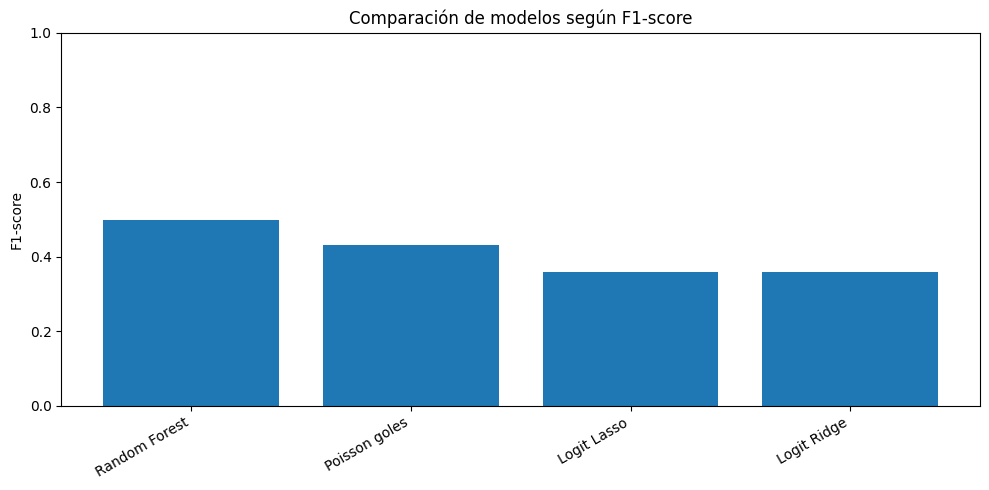

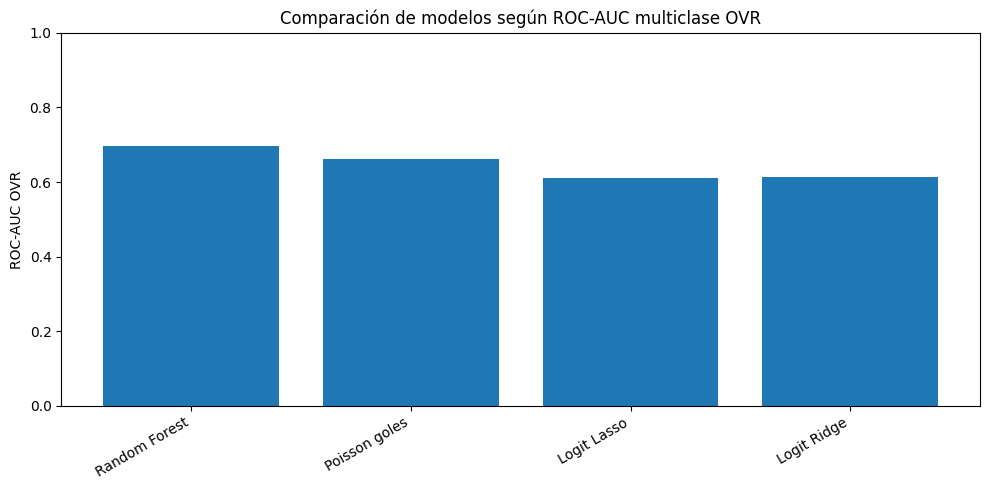

In [22]:
plt.figure(figsize=(10, 5))
plt.bar(results_sorted["Modelo"], results_sorted["F1-score"])
plt.title("Comparación de modelos según F1-score")
plt.ylabel("F1-score")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(results_sorted["Modelo"], results_sorted["ROC-AUC OVR"])
plt.title("Comparación de modelos según ROC-AUC multiclase OVR")
plt.ylabel("ROC-AUC OVR")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### Interpretación

Los gráficos comparan el rendimiento de los modelos usando dos métricas: **F1-score** y **ROC-AUC multiclase OVR**.

En ambos casos, el modelo con mejor desempeño es **Random Forest**, ya que obtiene el mayor F1-score y el mayor ROC-AUC.  
Esto indica que clasifica mejor los resultados y distingue con mayor precisión entre **victoria local, empate y derrota local**.

El modelo **Poisson de goles** ocupa el segundo lugar, mostrando un rendimiento aceptable porque utiliza directamente la estimación de goles esperados.

Los modelos **Logit Lasso** y **Logit Ridge** presentan resultados menores, lo que indica que tienen más dificultad para separar correctamente las tres clases.

En conclusión, **Random Forest es el modelo más adecuado para la predicción**, aunque los valores no son cercanos a 1, por lo que el desempeño general aún es moderado y puede mejorar con más variables o mejor ajuste de hiperparámetros.

# 20. Reportes de clasificación

In [23]:
print("Logit Ridge")
print(classification_report(y_test, pred_ridge, labels=CLASSES, target_names=CLASS_NAMES, zero_division=0))

print("Logit Lasso")
print(classification_report(y_test, pred_lasso, labels=CLASSES, target_names=CLASS_NAMES, zero_division=0))

print("Random Forest")
print(classification_report(y_test, pred_rf, labels=CLASSES, target_names=CLASS_NAMES, zero_division=0))

print("Poisson goles")
print(classification_report(y_test, pred_poisson, labels=CLASSES, target_names=CLASS_NAMES, zero_division=0))

Logit Ridge
                precision    recall  f1-score   support

 Derrota local       0.39      0.65      0.49        20
        Empate       0.23      0.33      0.27        15
Victoria local       0.67      0.21      0.32        29

      accuracy                           0.38        64
     macro avg       0.43      0.40      0.36        64
  weighted avg       0.48      0.38      0.36        64

Logit Lasso
                precision    recall  f1-score   support

 Derrota local       0.39      0.65      0.49        20
        Empate       0.23      0.33      0.27        15
Victoria local       0.67      0.21      0.32        29

      accuracy                           0.38        64
     macro avg       0.43      0.40      0.36        64
  weighted avg       0.48      0.38      0.36        64

Random Forest
                precision    recall  f1-score   support

 Derrota local       0.46      0.60      0.52        20
        Empate       0.22      0.13      0.17        15
Vic

### Interpretación

El reporte muestra que **Random Forest** obtuvo el mejor rendimiento general, con una exactitud de **0.52** y un F1-score ponderado de **0.50**.

Los modelos **Logit Ridge** y **Logit Lasso** tuvieron resultados similares, pero con menor precisión general.

El modelo **Poisson de goles** logró una exactitud de **0.50**, aunque presentó dificultad para predecir los **empates**.

En conclusión, **Random Forest es el modelo más adecuado**, porque muestra el mejor equilibrio para clasificar victoria local, empate y derrota local.

# 21. Matrices de confusión

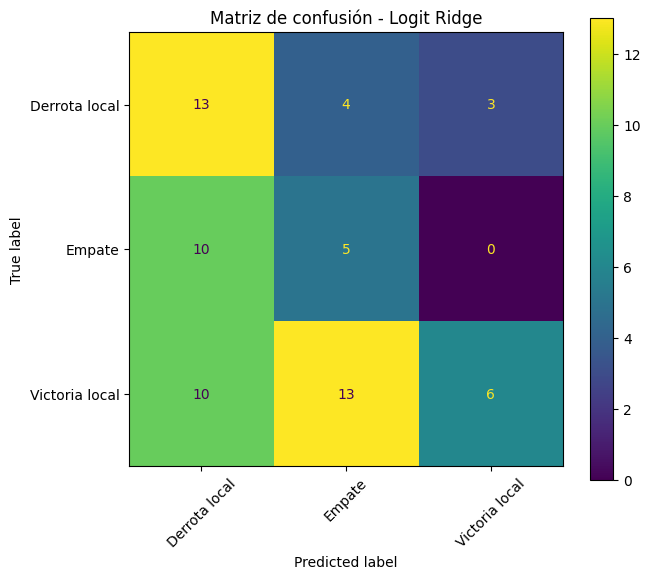

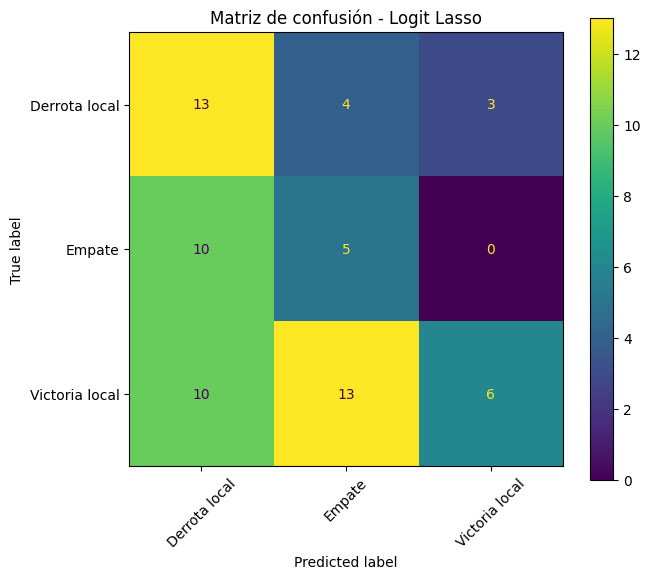

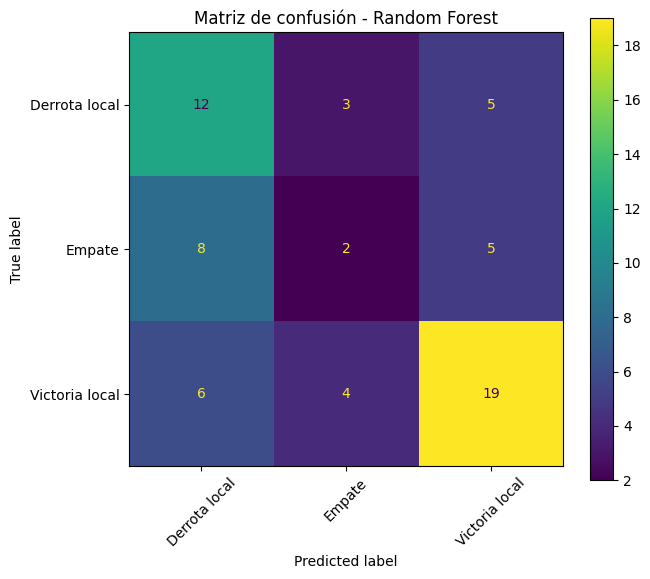

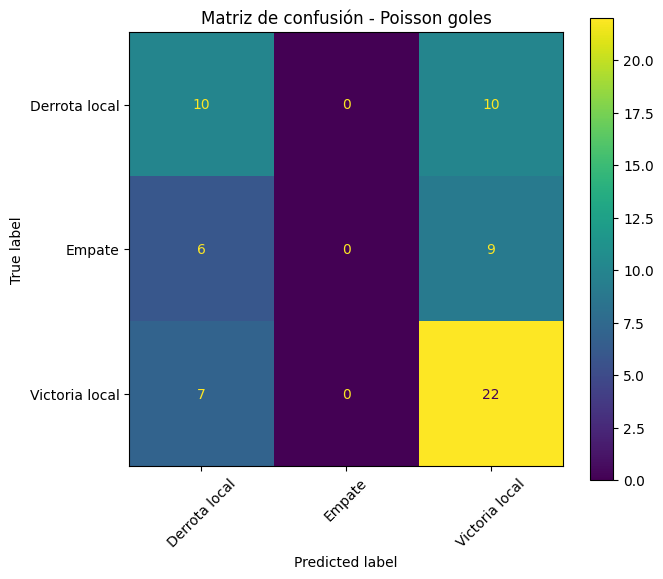

In [24]:
predictions_dict = {
    "Logit Ridge": pred_ridge,
    "Logit Lasso": pred_lasso,
    "Random Forest": pred_rf,
    "Poisson goles": pred_poisson
}

for model_name, pred in predictions_dict.items():
    fig, ax = plt.subplots(figsize=(7, 6))
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        pred,
        labels=CLASSES,
        display_labels=CLASS_NAMES,
        ax=ax,
        xticks_rotation=45
    )
    plt.title(f"Matriz de confusión - {model_name}")
    plt.show()

# 22. Curva ROC multiclase

Como la respuesta tiene tres clases, se aplica estrategia **One-vs-Rest**:

- Derrota local vs las demás.
- Empate vs las demás.
- Victoria local vs las demás.

In [25]:
proba_dict = {
    "Logit Ridge": proba_ridge,
    "Logit Lasso": proba_lasso,
    "Random Forest": proba_rf,
    "Poisson goles": proba_poisson
}

roc_summary = []

for model_name, proba in proba_dict.items():
    auc_macro = np.nan
    auc_weighted = np.nan
    try:
        auc_macro = roc_auc_score(y_test, proba, labels=CLASSES, multi_class="ovr", average="macro")
        auc_weighted = roc_auc_score(y_test, proba, labels=CLASSES, multi_class="ovr", average="weighted")
    except Exception:
        pass

    roc_summary.append({
        "Modelo": model_name,
        "ROC-AUC macro": auc_macro,
        "ROC-AUC weighted": auc_weighted
    })

display(pd.DataFrame(roc_summary).round(4))

,Modelo,ROC-AUC macro,ROC-AUC weighted
0,Logit Ridge,0.5877,0.6139
1,Logit Lasso,0.5821,0.6103
2,Random Forest,0.6783,0.6961
3,Poisson goles,0.6556,0.6613


### Interpretación

La tabla compara los modelos usando **ROC-AUC macro** y **ROC-AUC ponderado**.

El modelo con mejor desempeño es **Random Forest**, con:

- **ROC-AUC macro:** 0.6783
- **ROC-AUC weighted:** 0.6961

Esto indica que Random Forest distingue mejor entre las clases: **derrota local, empate y victoria local**.

El segundo mejor modelo es **Poisson goles**, con un ROC-AUC weighted de **0.6613**.

En conclusión, **Random Forest presenta la mejor capacidad de clasificación**, aunque los valores muestran un rendimiento moderado y todavía mejorable.

Mejor modelo según F1-score: Random Forest


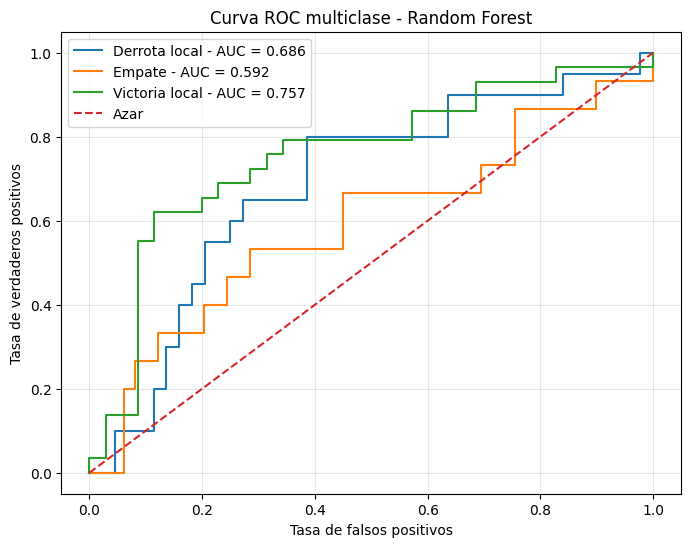

In [26]:
best_model_name = results_sorted.iloc[0]["Modelo"]

if best_model_name == "Logit Ridge":
    best_proba = proba_ridge
    best_pred = pred_ridge
    best_model_object = logit_ridge
elif best_model_name == "Logit Lasso":
    best_proba = proba_lasso
    best_pred = pred_lasso
    best_model_object = logit_lasso
elif best_model_name == "Random Forest":
    best_proba = proba_rf
    best_pred = pred_rf
    best_model_object = random_forest
else:
    best_proba = proba_poisson
    best_pred = pred_poisson
    best_model_object = None

print("Mejor modelo según F1-score:", best_model_name)

y_test_bin = label_binarize(y_test, classes=CLASSES)

plt.figure(figsize=(8, 6))

for i, cls in enumerate(CLASSES):
    if len(np.unique(y_test_bin[:, i])) < 2:
        continue

    fpr, tpr, _ = roc_curve(y_test_bin[:, i], best_proba[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{CLASS_NAMES[i]} - AUC = {roc_auc:.3f}")

plt.plot([0, 1], [0, 1], linestyle="--", label="Azar")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos")
plt.title(f"Curva ROC multiclase - {best_model_name}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Interpretación

La validación temporal separó los datos en dos partes:  
el modelo se entrena con partidos hasta **2021** y se evalúa con partidos del **Mundial 2022**.

En el conjunto de entrenamiento hay **900 partidos**, mientras que en prueba hay **64 partidos**.

La clase más frecuente en ambos conjuntos es **Victoria local**:

- En entrenamiento: **55.89%**
- En prueba: **45.31%**

También se observa que en el Mundial 2022 aumentó la proporción de **Derrota local** hasta **31.25%**, mientras que los empates representan **23.44%**.

En conclusión, existe un desbalance moderado entre clases, pero la división temporal es adecuada porque simula una situación real: el modelo aprende con datos históricos y luego intenta predecir un Mundial más reciente.

# 23. Interpretación de coeficientes e importancia de variables

In [27]:
# Coeficientes de Logit Ridge
ridge_coef = logit_ridge.named_steps["model"].coef_

ridge_coef_df = pd.DataFrame(
    ridge_coef.T,
    index=model_features,
    columns=[f"coef_clase_{c}_{CLASS_MAP[c]}" for c in logit_ridge.named_steps["model"].classes_]
)

display(ridge_coef_df.round(4).head(20))

# Coeficientes de Logit Lasso
lasso_coef = logit_lasso.named_steps["model"].coef_

lasso_coef_df = pd.DataFrame(
    lasso_coef.T,
    index=model_features,
    columns=[f"coef_clase_{c}_{CLASS_MAP[c]}" for c in logit_lasso.named_steps["model"].classes_]
)

display(lasso_coef_df.round(4).head(20))

# Cantidad de coeficientes llevados a cero por Lasso
zero_count = (np.abs(lasso_coef_df.values) < 1e-8).sum()
total_count = lasso_coef_df.size

print(f"Coeficientes cero en Lasso: {zero_count} de {total_count}")

,coef_clase_0_Derrota local,coef_clase_1_Empate,coef_clase_2_Victoria local
home_matches_before,0.0452,0.0060,-0.0512
away_matches_before,0.2938,0.0096,-0.3034
home_win_rate_before,-0.1757,0.1067,0.0691
away_win_rate_before,0.1072,0.1115,-0.2187
home_draw_rate_before,0.0668,-0.1461,0.0793
away_draw_rate_before,-0.1927,0.3544,-0.1617
home_loss_rate_before,-0.0420,0.2236,-0.1815
away_loss_rate_before,-0.0251,-0.0091,0.0342
home_gf_avg_before,-0.2928,0.1733,0.1195
away_gf_avg_before,-0.1036,-0.1954,0.2990


,coef_clase_0_Derrota local,coef_clase_1_Empate,coef_clase_2_Victoria local
home_matches_before,0.0000,0.0000,0.0000
away_matches_before,0.2990,0.0000,-0.3544
home_win_rate_before,0.0000,0.0000,0.0000
away_win_rate_before,0.0000,0.0000,0.0000
home_draw_rate_before,0.0000,-0.0964,0.0000
away_draw_rate_before,-0.0543,0.1061,0.0000
home_loss_rate_before,0.0000,0.0183,0.0000
away_loss_rate_before,0.0716,-0.0343,0.0000
home_gf_avg_before,-0.3702,0.0000,0.1588
away_gf_avg_before,0.0000,-0.0864,0.2307


Coeficientes cero en Lasso: 64 de 108


,variable,importancia
32,diff_experience,0.05939
1,away_matches_before,0.05786
8,home_gf_avg_before,0.04945
25,diff_gf_avg,0.04015
27,diff_gd_avg,0.03930
12,home_gd_avg_before,0.03641
22,diff_win_rate,0.03349
9,away_gf_avg_before,0.03211
28,diff_ppm,0.03151
23,diff_draw_rate,0.03051


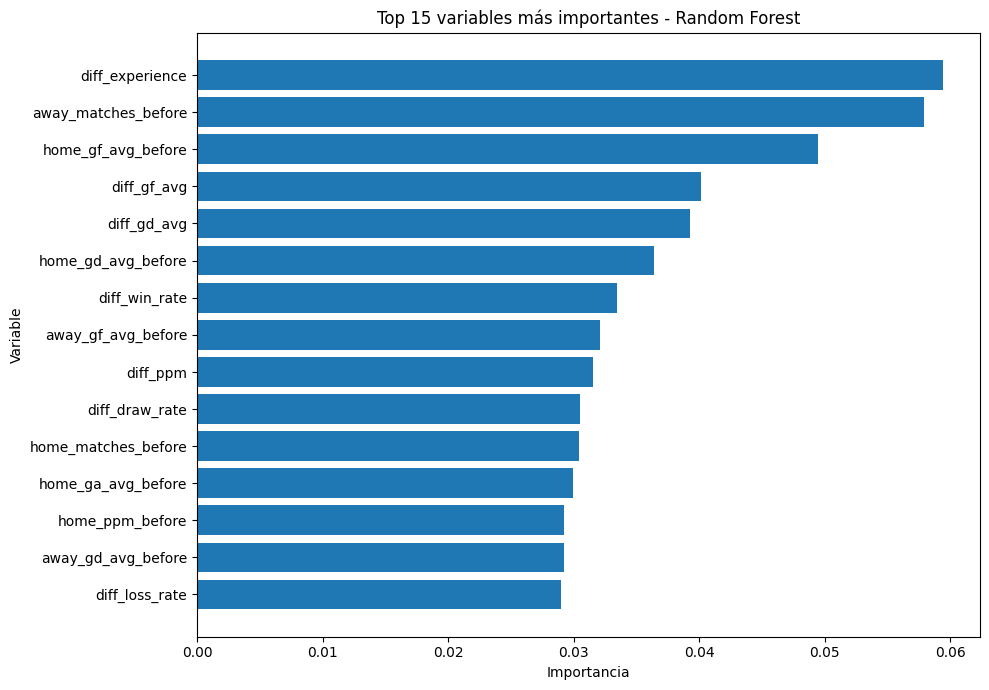

In [28]:
rf_importance = pd.DataFrame({
    "variable": model_features,
    "importancia": random_forest.named_steps["model"].feature_importances_
}).sort_values("importancia", ascending=False)

display(rf_importance.round(5))

top_importance = rf_importance.head(15).sort_values("importancia")

plt.figure(figsize=(10, 7))
plt.barh(top_importance["variable"], top_importance["importancia"])
plt.title("Top 15 variables más importantes - Random Forest")
plt.xlabel("Importancia")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

### Interpretación

El gráfico muestra las **15 variables más importantes** para el modelo **Random Forest**.

La variable con mayor influencia es `diff_experience`, lo que indica que la diferencia de experiencia entre selecciones ayuda bastante a predecir el resultado del partido.

También destacan variables como:

- `away_matches_before`: partidos previos del equipo visitante.
- `home_gf_avg_before`: promedio de goles a favor del equipo local.
- `diff_gf_avg`: diferencia de goles a favor promedio.
- `diff_gd_avg`: diferencia de gol promedio.

En conclusión, el modelo Random Forest da mayor importancia a variables relacionadas con **experiencia, rendimiento ofensivo, diferencia de goles y desempeño histórico previo**.  
Esto significa que el resultado no depende solo del ranking FIFA, sino también del rendimiento acumulado de cada selección antes del partido.

# 24. Análisis de errores

Se revisan los partidos mal clasificados por el mejor modelo.

In [29]:
test_details = features_df.loc[test_idx, [
    "match_year", "home_team_std", "away_team_std", "target", "home_goals", "away_goals"
]].copy()

test_details["resultado_real"] = test_details["target"].map(CLASS_MAP)
test_details["prediccion"] = pd.Series(best_pred, index=test_details.index).map(CLASS_MAP)
test_details["prob_derrota_local"] = best_proba[:, 0]
test_details["prob_empate"] = best_proba[:, 1]
test_details["prob_victoria_local"] = best_proba[:, 2]
test_details["acierto"] = test_details["target"].values == best_pred
test_details["confianza_prediccion"] = test_details[["prob_derrota_local", "prob_empate", "prob_victoria_local"]].max(axis=1)

errores = test_details[test_details["acierto"] == False].copy()

print("Cantidad de errores:", errores.shape[0])
display(errores.sort_values("confianza_prediccion", ascending=False).head(15))

Cantidad de errores: 31


,match_year,home_team_std,away_team_std,target,home_goals,away_goals,resultado_real,prediccion,prob_derrota_local,prob_empate,prob_victoria_local,acierto,confianza_prediccion
943,2022,japan,spain,2,2,1,Victoria local,Derrota local,0.846669,0.105922,0.047409,False,0.846669
954,2022,morocco,spain,1,0,0,Empate,Derrota local,0.838740,0.095284,0.065976,False,0.838740
909,2022,germany,japan,0,1,2,Derrota local,Victoria local,0.069032,0.156061,0.774907,False,0.774907
956,2022,croatia,brazil,1,1,1,Empate,Derrota local,0.736248,0.115949,0.147803,False,0.736248
937,2022,tunisia,france,2,1,0,Victoria local,Derrota local,0.707181,0.136191,0.156628,False,0.707181
918,2022,netherlands,ecuador,1,1,1,Empate,Victoria local,0.125586,0.180699,0.693715,False,0.693715
904,2022,argentina,saudi arabia,0,1,2,Derrota local,Victoria local,0.116838,0.197736,0.685425,False,0.685425
946,2022,cameroon,brazil,2,1,0,Victoria local,Derrota local,0.636939,0.112833,0.250228,False,0.636939
921,2022,poland,saudi arabia,2,2,0,Victoria local,Empate,0.097031,0.566923,0.336046,False,0.566923
906,2022,mexico,poland,1,0,0,Empate,Derrota local,0.556417,0.220423,0.223160,False,0.556417


### Interpretación

La tabla muestra los **31 errores de predicción** del modelo en el Mundial 2022.

Se observa que varios errores ocurrieron en partidos difíciles o inesperados, como **Japón vs España**, **Alemania vs Japón** y **Bélgica vs Marruecos**.

También se evidencia que el modelo tuvo mayor dificultad para predecir **empates** y resultados sorpresa.

En conclusión, el modelo tiene un rendimiento aceptable, pero aún falla en partidos donde el resultado real se aleja del comportamiento histórico esperado.

# 25. Predicción del Mundial 2026

Para el calendario 2026 se usan las estadísticas históricas acumuladas hasta 2022.  
El ranking FIFA 2026 se agrega como contexto descriptivo en la tabla final.

In [30]:
print("Columnas de schedule_2026:")
print(list(schedule.columns))
display(schedule.head())

Columnas de schedule_2026:
['round', 'day', 'date', 'time', 'score', 'referee', 'notes', 'year', 'home_team', 'away_team']


,round,day,date,time,score,referee,notes,year,home_team,away_team
0,Group stage,Thu,2026-06-11,13:00 (22:00),NaN,NaN,NaN,2026,Mexico,South Africa
1,Group stage,Thu,2026-06-11,20:00 (05:00),NaN,NaN,NaN,2026,Korea Republic,Czechia
2,Group stage,Fri,2026-06-12,15:00 (22:00),NaN,NaN,NaN,2026,Canada,Bosnia-Herzegovina
3,Group stage,Fri,2026-06-12,18:00 (04:00),NaN,NaN,NaN,2026,United States,Paraguay
4,Group stage,Sat,2026-06-13,12:00 (22:00),NaN,NaN,NaN,2026,Qatar,Switzerland


El archivo schedule_2026.csv contiene el calendario base de los partidos del Mundial 2026.
Sin embargo, las columnas score, referee y notes aparecen vacías porque el archivo funciona como calendario y no como archivo de resultados actualizados.

Por ello, estas columnas no se usarán como variables predictoras.
A partir de este calendario, el modelo generará predicciones de resultado, marcador estimado, tabla de posiciones y selecciones clasificadas a la siguiente fase.

In [31]:
schedule_home_col = find_col(
    schedule,
    ["home_team", "home_team_name", "home", "team1", "equipo_local", "local"],
    required=False,
    label="equipo local en schedule"
)

schedule_away_col = find_col(
    schedule,
    ["away_team", "away_team_name", "away", "team2", "equipo_visitante", "visitante"],
    required=False,
    label="equipo visitante en schedule"
)

if schedule_home_col is None or schedule_away_col is None:
    raise KeyError(
        "No se detectaron columnas de equipo local y visitante en schedule_2026. "
        "Revisa las columnas impresas arriba."
    )

print("Equipo local detectado:", schedule_home_col)
print("Equipo visitante detectado:", schedule_away_col)

Equipo local detectado: home_team
Equipo visitante detectado: away_team


In [32]:
def is_placeholder_team(name):
    if pd.isna(name):
        return True

    s = remove_accents(str(name)).lower().strip()
    patterns = [
        "tbd", "to be determined", "winner", "runner", "group",
        "playoff", "play-off", "qualified", "third", "place",
        "1st", "2nd", "3rd", "unknown"
    ]
    return any(p in s for p in patterns)

def final_rates_for_team(team):
    stats = final_team_stats.get(team, empty_stats())
    return calculate_rates(stats)

def build_future_features(schedule_df):
    out_rows = []
    tmp = schedule_df.copy()
    tmp["home_team_std"] = tmp[schedule_home_col].apply(standardize_team_name)
    tmp["away_team_std"] = tmp[schedule_away_col].apply(standardize_team_name)
    tmp["home_placeholder"] = tmp[schedule_home_col].apply(is_placeholder_team)
    tmp["away_placeholder"] = tmp[schedule_away_col].apply(is_placeholder_team)
    tmp["prediccion_valida"] = ~(tmp["home_placeholder"] | tmp["away_placeholder"])

    for _, row in tmp.iterrows():
        h = row["home_team_std"]
        a = row["away_team_std"]

        h_rates = final_rates_for_team(h)
        a_rates = final_rates_for_team(a)

        feature_row = row.to_dict()

        for key, value in h_rates.items():
            feature_row[f"home_{key}"] = value
        for key, value in a_rates.items():
            feature_row[f"away_{key}"] = value

        feature_row["diff_win_rate"] = feature_row["home_win_rate_before"] - feature_row["away_win_rate_before"]
        feature_row["diff_draw_rate"] = feature_row["home_draw_rate_before"] - feature_row["away_draw_rate_before"]
        feature_row["diff_loss_rate"] = feature_row["home_loss_rate_before"] - feature_row["away_loss_rate_before"]
        feature_row["diff_gf_avg"] = feature_row["home_gf_avg_before"] - feature_row["away_gf_avg_before"]
        feature_row["diff_ga_avg"] = feature_row["home_ga_avg_before"] - feature_row["away_ga_avg_before"]
        feature_row["diff_gd_avg"] = feature_row["home_gd_avg_before"] - feature_row["away_gd_avg_before"]
        feature_row["diff_ppm"] = feature_row["home_ppm_before"] - feature_row["away_ppm_before"]
        feature_row["diff_recent_ppm_5"] = feature_row["home_recent_ppm_5"] - feature_row["away_recent_ppm_5"]
        feature_row["diff_recent_gf_avg_5"] = feature_row["home_recent_gf_avg_5"] - feature_row["away_recent_gf_avg_5"]
        feature_row["diff_recent_ga_avg_5"] = feature_row["home_recent_ga_avg_5"] - feature_row["away_recent_ga_avg_5"]
        feature_row["diff_experience"] = feature_row["home_matches_before"] - feature_row["away_matches_before"]

        feature_row["home_is_host"] = is_host_team(2026, h) if 2026 in host_map else 0
        feature_row["away_is_host"] = is_host_team(2026, a) if 2026 in host_map else 0
        feature_row["host_advantage_diff"] = feature_row["home_is_host"] - feature_row["away_is_host"]

        out_rows.append(feature_row)

    out = pd.DataFrame(out_rows)

    for col in model_features:
        if col not in out.columns:
            out[col] = np.nan

    return out

schedule_features = build_future_features(schedule)

print("Partidos en calendario:", schedule_features.shape[0])
print("Partidos con equipos definidos:", int(schedule_features["prediccion_valida"].sum()))
display(schedule_features[[schedule_home_col, schedule_away_col, "prediccion_valida"]].head(20))

Partidos en calendario: 72
Partidos con equipos definidos: 72


,home_team,away_team,prediccion_valida
0,Mexico,South Africa,True
1,Korea Republic,Czechia,True
2,Canada,Bosnia-Herzegovina,True
3,United States,Paraguay,True
4,Qatar,Switzerland,True
5,Brazil,Morocco,True
6,Haiti,Scotland,True
7,Australia,Türkiye,True
8,Germany,Curaçao,True
9,Netherlands,Japan,True


### Interpretación

El calendario del Mundial 2026 contiene **72 partidos** y todos tienen equipos definidos.

La columna `prediccion_valida` aparece como **True** en los partidos mostrados, lo que indica que ambos equipos tienen información suficiente para aplicar el modelo predictivo.

En conclusión, el dataset está listo para generar predicciones de los partidos programados del Mundial 2026.

In [33]:
predictions_2026 = schedule_features.copy()

predictions_2026["prediccion_resultado"] = "No estimable: equipo no definido"
predictions_2026["prob_derrota_local"] = np.nan
predictions_2026["prob_empate"] = np.nan
predictions_2026["prob_victoria_local"] = np.nan

valid_mask_2026 = predictions_2026["prediccion_valida"] == True

if valid_mask_2026.sum() > 0:
    X_2026_valid = predictions_2026.loc[valid_mask_2026, model_features].copy()

    if best_model_name == "Poisson goles":
        lambda_home_2026 = poisson_home.predict(X_2026_valid)
        lambda_away_2026 = poisson_away.predict(X_2026_valid)
        lambda_home_2026 = np.clip(lambda_home_2026, 1e-6, 10)
        lambda_away_2026 = np.clip(lambda_away_2026, 1e-6, 10)
        proba_2026_valid = result_probabilities_from_lambdas(lambda_home_2026, lambda_away_2026, max_goals=12)
        pred_2026_valid = np.argmax(proba_2026_valid, axis=1)
    else:
        pred_2026_valid = best_model_object.predict(X_2026_valid)
        proba_2026_raw = best_model_object.predict_proba(X_2026_valid)
        proba_2026_valid = align_proba_to_classes(best_model_object, proba_2026_raw)

    predictions_2026.loc[valid_mask_2026, "prediccion_resultado"] = pd.Series(pred_2026_valid).map(CLASS_MAP).values
    predictions_2026.loc[valid_mask_2026, "prob_derrota_local"] = proba_2026_valid[:, 0]
    predictions_2026.loc[valid_mask_2026, "prob_empate"] = proba_2026_valid[:, 1]
    predictions_2026.loc[valid_mask_2026, "prob_victoria_local"] = proba_2026_valid[:, 2]
else:
    print("No hay partidos con equipos definidos para predecir.")

In [34]:
rank_home = fifa2026_table.rename(columns={
    "team_std": "home_team_std",
    "fifa_rank": "home_fifa_rank_2026",
    "fifa_points": "home_fifa_points_2026"
})

rank_away = fifa2026_table.rename(columns={
    "team_std": "away_team_std",
    "fifa_rank": "away_fifa_rank_2026",
    "fifa_points": "away_fifa_points_2026"
})

predictions_2026 = predictions_2026.merge(rank_home, on="home_team_std", how="left")
predictions_2026 = predictions_2026.merge(rank_away, on="away_team_std", how="left")

def better_ranked(row):
    h = row.get("home_fifa_rank_2026", np.nan)
    a = row.get("away_fifa_rank_2026", np.nan)

    if pd.isna(h) or pd.isna(a):
        return "Ranking no disponible"
    if h < a:
        return row[schedule_home_col]
    if a < h:
        return row[schedule_away_col]
    return "Ranking igual"

predictions_2026["equipo_mejor_rank_fifa_2026"] = predictions_2026.apply(better_ranked, axis=1)

output_cols = [
    schedule_home_col,
    schedule_away_col,
    "prediccion_valida",
    "prediccion_resultado",
    "prob_derrota_local",
    "prob_empate",
    "prob_victoria_local",
    "home_fifa_rank_2026",
    "away_fifa_rank_2026",
    "equipo_mejor_rank_fifa_2026"
]

output_cols = [c for c in output_cols if c in predictions_2026.columns]

display(predictions_2026[output_cols].head(40))
predictions_2026[output_cols].to_csv("predicciones_mundial_2026_modelos_clase.csv", index=False)

print("Archivo exportado: predicciones_mundial_2026_modelos_clase.csv")

,home_team,away_team,prediccion_valida,prediccion_resultado,prob_derrota_local,prob_empate,prob_victoria_local,home_fifa_rank_2026,away_fifa_rank_2026,equipo_mejor_rank_fifa_2026
0,Mexico,South Africa,True,Victoria local,0.366486,0.242166,0.391348,14.0,60.0,Mexico
1,Korea Republic,Czechia,True,Derrota local,0.560566,0.217131,0.222303,25.0,39.0,Korea Republic
2,Canada,Bosnia-Herzegovina,True,Derrota local,0.383933,0.280922,0.335145,30.0,64.0,Canada
3,United States,Paraguay,True,Victoria local,0.326732,0.273014,0.400254,17.0,40.0,United States
4,Qatar,Switzerland,True,Derrota local,0.781959,0.151785,0.066256,57.0,19.0,Switzerland
5,Brazil,Morocco,True,Victoria local,0.153916,0.170530,0.675554,6.0,7.0,Brazil
6,Haiti,Scotland,True,Derrota local,0.577827,0.295231,0.126941,83.0,42.0,Scotland
7,Australia,Türkiye,True,Derrota local,0.434594,0.298263,0.267143,27.0,22.0,Türkiye
8,Germany,Curaçao,True,Victoria local,0.218294,0.141419,0.640286,10.0,82.0,Germany
9,Netherlands,Japan,True,Victoria local,0.064820,0.327882,0.607298,8.0,18.0,Netherlands


Archivo exportado: predicciones_mundial_2026_modelos_clase.csv


### Interpretación general

La tabla presenta las predicciones del modelo para los partidos del Mundial 2026.

Todos los partidos tienen `prediccion_valida = True`, lo que indica que el modelo pudo calcular el resultado esperado.

Se muestran las probabilidades de:

- Derrota local.
- Empate.
- Victoria local.

En general, el modelo favorece a los equipos con mejor ranking FIFA y mayor rendimiento histórico.  
También hay partidos con probabilidades cercanas, lo que indica mayor incertidumbre.

En conclusión, la tabla resume el resultado predicho y la confianza del modelo para cada partido.

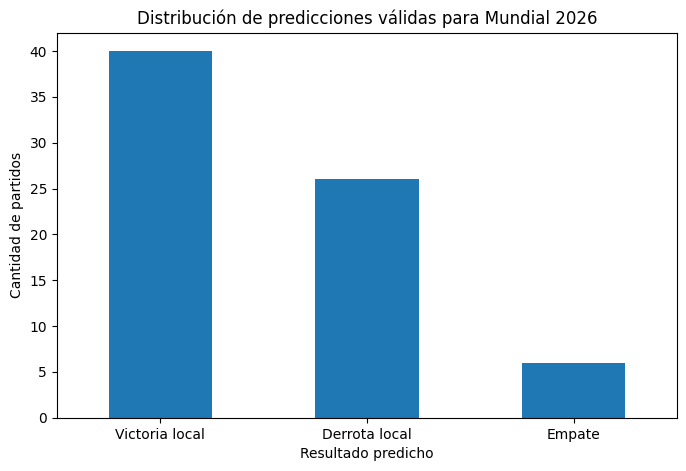

,frecuencia
prediccion_resultado,
Victoria local,40
Derrota local,26
Empate,6


In [35]:
valid_predictions = predictions_2026[predictions_2026["prediccion_valida"] == True]

if valid_predictions.shape[0] > 0:
    pred_counts = valid_predictions["prediccion_resultado"].value_counts()

    plt.figure(figsize=(8, 5))
    pred_counts.plot(kind="bar")
    plt.title("Distribución de predicciones válidas para Mundial 2026")
    plt.xlabel("Resultado predicho")
    plt.ylabel("Cantidad de partidos")
    plt.xticks(rotation=0)
    plt.show()

    display(pred_counts.rename("frecuencia").to_frame())
else:
    print("No hay predicciones válidas para graficar.")

# 26. Corrección final: modelo base o baseline

Para que la comparación sea académicamente más sólida, se agrega un **modelo base**. Este modelo sirve como punto mínimo de comparación: si un modelo avanzado no supera al baseline, entonces no aporta suficiente valor predictivo.

En este trabajo se usan dos referencias simples:

1. **Baseline clase frecuente:** siempre predice la clase más común del entrenamiento.
2. **Baseline estratificado:** predice respetando la proporción histórica de clases.

La idea es responder a una pregunta clave de evaluación:

> ¿Los modelos Logit, Poisson o Random Forest predicen mejor que una regla simple?


,Modelo,Accuracy,Balanced Accuracy,Precision,Recall,F1-score,ROC-AUC OVR,LogLoss,Brier
2,Random Forest,0.5156,0.4628,0.4932,0.5156,0.4990,0.6961,1.0052,0.5923
3,Poisson goles,0.5000,0.4195,0.3790,0.5000,0.4302,0.6613,1.0346,0.6142
5,Baseline aleatorio estratificado,0.4062,0.3628,0.3649,0.4062,0.3785,0.5324,21.4009,1.1875
0,Logit Ridge,0.3750,0.3967,0.4785,0.3750,0.3597,0.6139,1.2197,0.7116
1,Logit Lasso,0.3750,0.3967,0.4785,0.3750,0.3597,0.6103,1.2177,0.7119
4,Baseline clase frecuente,0.4531,0.3333,0.2053,0.4531,0.2826,0.5000,19.7114,1.0938


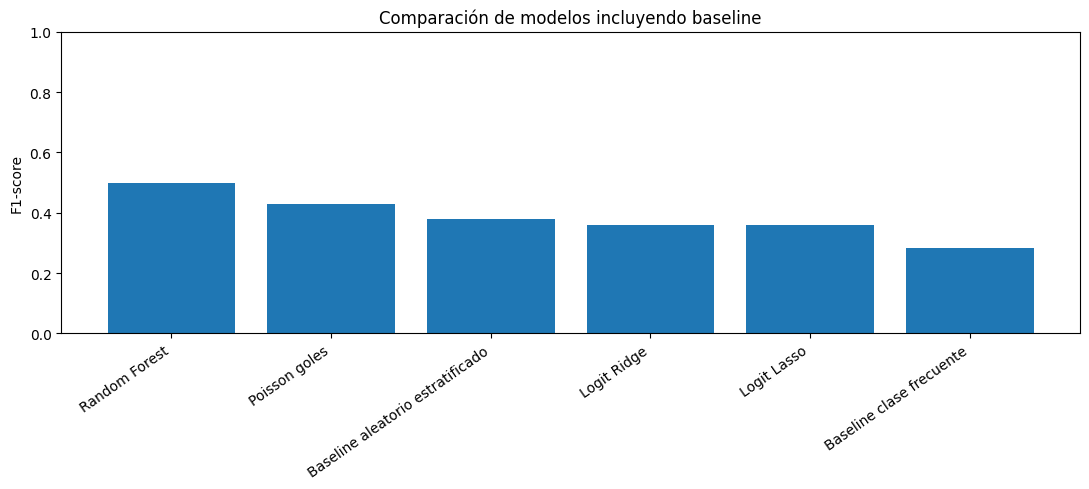

In [36]:
from sklearn.dummy import DummyClassifier


def get_estimator_classes(estimator):
    """Obtiene las clases aprendidas por un estimador simple o por un Pipeline."""
    if hasattr(estimator, "classes_"):
        return list(estimator.classes_)
    if hasattr(estimator, "named_steps") and "model" in estimator.named_steps:
        model = estimator.named_steps["model"]
        if hasattr(model, "classes_"):
            return list(model.classes_)
    return list(CLASSES)


def align_proba_generic(estimator, proba, target_classes=CLASSES):
    """Alinea columnas de predict_proba al orden: derrota local, empate, victoria local."""
    estimator_classes = get_estimator_classes(estimator)
    aligned = np.zeros((proba.shape[0], len(target_classes)))

    for j, cls in enumerate(target_classes):
        if cls in estimator_classes:
            aligned[:, j] = proba[:, estimator_classes.index(cls)]

    return aligned

baseline_frequent = DummyClassifier(strategy="most_frequent")
baseline_frequent.fit(X_train, y_train)
pred_baseline_frequent = baseline_frequent.predict(X_test)
proba_baseline_frequent = align_proba_generic(
    baseline_frequent,
    baseline_frequent.predict_proba(X_test)
)

baseline_stratified = DummyClassifier(strategy="stratified", random_state=RANDOM_STATE)
baseline_stratified.fit(X_train, y_train)
pred_baseline_stratified = baseline_stratified.predict(X_test)
proba_baseline_stratified = align_proba_generic(
    baseline_stratified,
    baseline_stratified.predict_proba(X_test)
)

baseline_results = pd.DataFrame([
    evaluate_model(
        y_test,
        pred_baseline_frequent,
        proba_baseline_frequent,
        "Baseline clase frecuente"
    ),
    evaluate_model(
        y_test,
        pred_baseline_stratified,
        proba_baseline_stratified,
        "Baseline aleatorio estratificado"
    )
])

results_con_baseline = pd.concat([results, baseline_results], ignore_index=True)
results_con_baseline = results_con_baseline.sort_values("F1-score", ascending=False)

display(results_con_baseline.round(4))

plt.figure(figsize=(11, 5))
plt.bar(results_con_baseline["Modelo"], results_con_baseline["F1-score"])
plt.title("Comparación de modelos incluyendo baseline")
plt.ylabel("F1-score")
plt.ylim(0, 1)
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()


## Interpretación del baseline

Esta sección permite defender mejor el trabajo. El baseline representa una regla simple, mientras que Logit, Poisson y Random Forest usan información histórica e ingeniería de variables.

La interpretación que puedes decir es:

> El baseline se usa como punto mínimo de comparación. Si Random Forest, Logit o Poisson superan al baseline en F1-score y ROC-AUC, entonces el modelo no solo está prediciendo por frecuencia, sino que está aprendiendo patrones de los datos históricos.

Para una exposición, no basta con decir que un modelo obtuvo cierto porcentaje. También se debe explicar si ese porcentaje es mejor que una regla básica.


# 27. Corrección final: ajuste de hiperparámetros

Para mejorar el trabajo, se agrega una búsqueda de hiperparámetros para Random Forest. Esto evita usar parámetros arbitrarios y permite justificar que se intentó optimizar el modelo.

Se ajustan principalmente:

- `n_estimators`: número de árboles.
- `max_depth`: profundidad máxima de los árboles.
- `min_samples_leaf`: mínimo de observaciones por hoja.
- `class_weight`: corrección por desbalance de clases.

La métrica usada para seleccionar el mejor modelo es **F1-score ponderado**, porque el problema tiene tres clases y los empates suelen ser más difíciles de predecir.


Mejores hiperparámetros de Random Forest:
{'model__class_weight': 'balanced_subsample', 'model__max_depth': None, 'model__min_samples_leaf': 2, 'model__n_estimators': 300}
Mejor F1-score promedio en validación cruzada: 0.4835


,Modelo,Accuracy,Balanced Accuracy,Precision,Recall,F1-score,ROC-AUC OVR,LogLoss,Brier
6,Random Forest ajustado,0.5312,0.4851,0.5172,0.5312,0.5198,0.6867,1.0163,0.5985
0,Random Forest,0.5156,0.4628,0.4932,0.5156,0.4990,0.6961,1.0052,0.5923
1,Poisson goles,0.5000,0.4195,0.3790,0.5000,0.4302,0.6613,1.0346,0.6142
2,Baseline aleatorio estratificado,0.4062,0.3628,0.3649,0.4062,0.3785,0.5324,21.4009,1.1875
3,Logit Ridge,0.3750,0.3967,0.4785,0.3750,0.3597,0.6139,1.2197,0.7116
4,Logit Lasso,0.3750,0.3967,0.4785,0.3750,0.3597,0.6103,1.2177,0.7119
5,Baseline clase frecuente,0.4531,0.3333,0.2053,0.4531,0.2826,0.5000,19.7114,1.0938


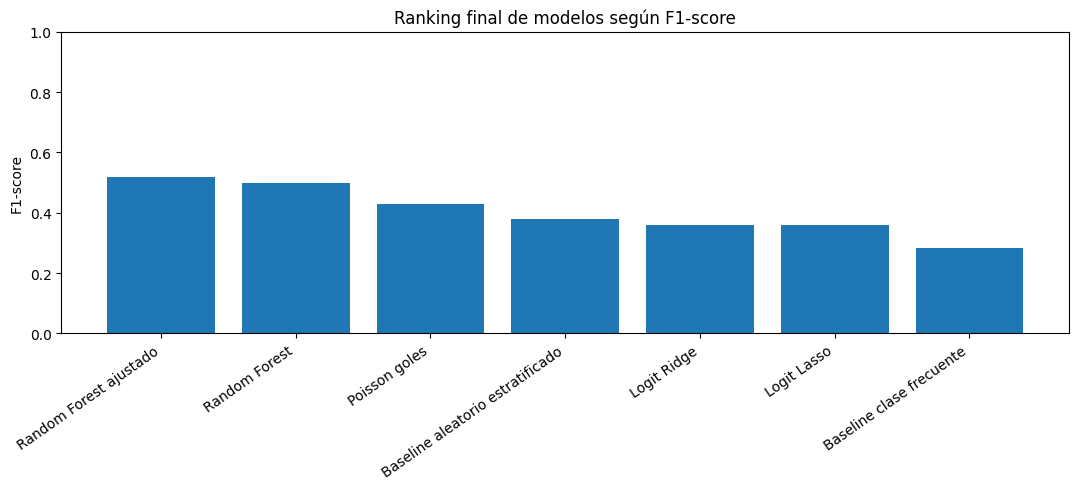

In [37]:
from sklearn.model_selection import GridSearchCV

param_grid_rf = {
    "model__n_estimators": [300, 600],
    "model__max_depth": [None, 8, 12],
    "model__min_samples_leaf": [1, 2],
    "model__class_weight": ["balanced", "balanced_subsample"]
}

min_class_train = int(y_train.value_counts().min())
cv_folds = min(3, min_class_train)

if cv_folds >= 2:
    grid_rf = GridSearchCV(
        estimator=random_forest,
        param_grid=param_grid_rf,
        scoring="f1_weighted",
        cv=cv_folds,
        n_jobs=-1,
        refit=True
    )

    grid_rf.fit(X_train, y_train)
    rf_tuned = grid_rf.best_estimator_

    print("Mejores hiperparámetros de Random Forest:")
    print(grid_rf.best_params_)
    print(f"Mejor F1-score promedio en validación cruzada: {grid_rf.best_score_:.4f}")
else:
    print("No hay suficientes observaciones por clase para aplicar validación cruzada. Se conserva el Random Forest original.")
    grid_rf = None
    rf_tuned = random_forest

pred_rf_tuned = rf_tuned.predict(X_test)
proba_rf_tuned = align_proba_generic(rf_tuned, rf_tuned.predict_proba(X_test))

rf_tuned_result = pd.DataFrame([
    evaluate_model(y_test, pred_rf_tuned, proba_rf_tuned, "Random Forest ajustado")
])

results_final = pd.concat(
    [results_con_baseline, rf_tuned_result],
    ignore_index=True
).sort_values("F1-score", ascending=False)

display(results_final.round(4))

plt.figure(figsize=(11, 5))
plt.bar(results_final["Modelo"], results_final["F1-score"])
plt.title("Ranking final de modelos según F1-score")
plt.ylabel("F1-score")
plt.ylim(0, 1)
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()


## Interpretación del ajuste

Esta parte mejora la defensa metodológica del trabajo, porque ya no se presenta Random Forest con una configuración fija sin justificación. Ahora se prueba un conjunto de combinaciones y se conserva la mejor.

Puedes explicarlo así:

> Apliqué ajuste de hiperparámetros mediante GridSearchCV. El objetivo fue mejorar el F1-score ponderado, porque el problema es multiclase y existe dificultad especial para reconocer empates. Con esto, el modelo final no se elige solo por intuición, sino por comparación cuantitativa.


# 28. Corrección final: selección del modelo definitivo

Después de incluir modelos originales, modelos base y Random Forest ajustado, se construye una tabla final. El modelo ganador se selecciona usando **F1-score ponderado**, porque esta métrica resume precisión y recall considerando el peso de cada clase.

También se conserva ROC-AUC como métrica complementaria, porque mide la capacidad discriminativa del modelo entre clases.


In [38]:
model_registry = {
    "Logit Ridge": logit_ridge,
    "Logit Lasso": logit_lasso,
    "Random Forest": random_forest,
    "Random Forest ajustado": rf_tuned,
    "Baseline clase frecuente": baseline_frequent,
    "Baseline aleatorio estratificado": baseline_stratified
}

prediction_registry = {
    "Logit Ridge": pred_ridge,
    "Logit Lasso": pred_lasso,
    "Random Forest": pred_rf,
    "Random Forest ajustado": pred_rf_tuned,
    "Poisson goles": pred_poisson,
    "Baseline clase frecuente": pred_baseline_frequent,
    "Baseline aleatorio estratificado": pred_baseline_stratified
}

probability_registry = {
    "Logit Ridge": proba_ridge,
    "Logit Lasso": proba_lasso,
    "Random Forest": proba_rf,
    "Random Forest ajustado": proba_rf_tuned,
    "Poisson goles": proba_poisson,
    "Baseline clase frecuente": proba_baseline_frequent,
    "Baseline aleatorio estratificado": proba_baseline_stratified
}

modelo_final_nombre = results_final.iloc[0]["Modelo"]
best_final_pred = prediction_registry[modelo_final_nombre]
best_final_proba = probability_registry[modelo_final_nombre]
best_final_model_object = model_registry.get(modelo_final_nombre, None)

print("Modelo definitivo seleccionado:", modelo_final_nombre)
display(results_final.head(7).round(4))

resultados_modelos_final = results_final.copy()
resultados_modelos_final.to_csv("resultados_modelos_final.csv", index=False)
print("Archivo exportado: resultados_modelos_final.csv")


Modelo definitivo seleccionado: Random Forest ajustado


,Modelo,Accuracy,Balanced Accuracy,Precision,Recall,F1-score,ROC-AUC OVR,LogLoss,Brier
6,Random Forest ajustado,0.5312,0.4851,0.5172,0.5312,0.5198,0.6867,1.0163,0.5985
0,Random Forest,0.5156,0.4628,0.4932,0.5156,0.4990,0.6961,1.0052,0.5923
1,Poisson goles,0.5000,0.4195,0.3790,0.5000,0.4302,0.6613,1.0346,0.6142
2,Baseline aleatorio estratificado,0.4062,0.3628,0.3649,0.4062,0.3785,0.5324,21.4009,1.1875
3,Logit Ridge,0.3750,0.3967,0.4785,0.3750,0.3597,0.6139,1.2197,0.7116
4,Logit Lasso,0.3750,0.3967,0.4785,0.3750,0.3597,0.6103,1.2177,0.7119
5,Baseline clase frecuente,0.4531,0.3333,0.2053,0.4531,0.2826,0.5000,19.7114,1.0938


Archivo exportado: resultados_modelos_final.csv


## Interpretación del modelo definitivo

El modelo definitivo no se elige por gusto, sino por evidencia comparativa. La lectura correcta es:

> El mejor modelo es el que obtiene el mayor F1-score ponderado en el conjunto de prueba. Esta métrica es adecuada porque el problema tiene tres clases: derrota local, empate y victoria local. Además, se revisa ROC-AUC para observar la capacidad discriminativa del modelo.

Si el modelo ganador es Random Forest o Random Forest ajustado, puedes decir:

> Random Forest fue superior porque puede capturar relaciones no lineales entre variables históricas, diferencia de rendimiento, experiencia y forma reciente. En cambio, Logit y Poisson son más interpretables, pero tienen una estructura más rígida.


# 29. Corrección final: validación temporal retrospectiva

La validación principal entrena con datos históricos y prueba en el Mundial más reciente. Para fortalecer el trabajo, se agrega una **validación temporal retrospectiva**.

La lógica es:

- Entrenar con Mundiales anteriores.
- Probar en un Mundial posterior.
- Repetir el proceso para varios años.

Esto permite saber si el modelo es estable o si solo funcionó en un único torneo.


,Mundial_prueba,Modelo,N_train,N_test,Accuracy,Balanced Accuracy,F1-score
0,2010,Baseline,708,64,0.3594,0.3333,0.1900
1,2010,Logit Ridge,708,64,0.4062,0.4148,0.4209
2,2010,Random Forest,708,64,0.5625,0.5522,0.5602
3,2014,Baseline,772,64,0.4375,0.3333,0.2663
4,2014,Logit Ridge,772,64,0.3906,0.3999,0.3912
5,2014,Random Forest,772,64,0.4688,0.4097,0.4595
6,2018,Baseline,836,64,0.4062,0.3333,0.2347
7,2018,Logit Ridge,836,64,0.4219,0.4051,0.4202
8,2018,Random Forest,836,64,0.4062,0.3508,0.4029
9,2022,Baseline,900,64,0.4531,0.3333,0.2826


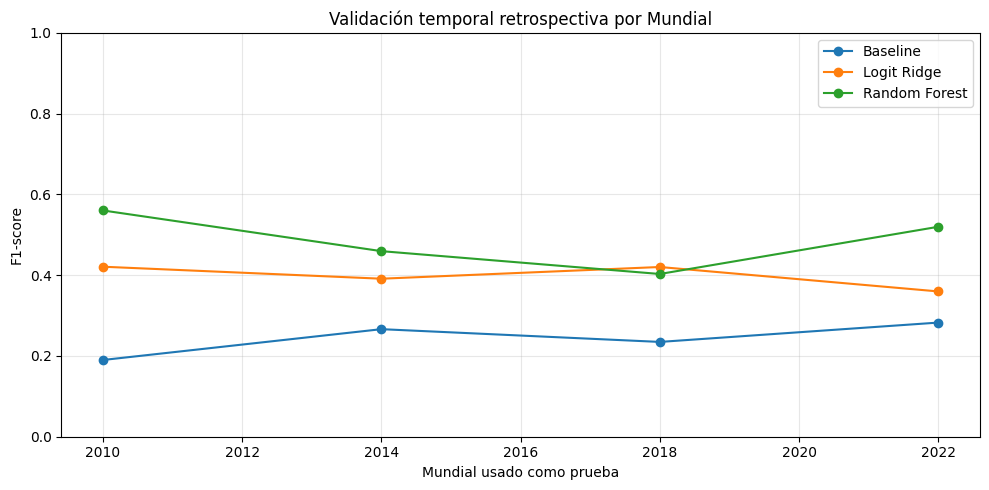

In [39]:
from sklearn.base import clone

backtest_years = [2010, 2014, 2018, 2022]
backtest_rows = []

for year in backtest_years:
    if year not in set(features_df["match_year"].dropna().astype(int)):
        continue

    train_mask_bt = features_df["match_year"] < year
    test_mask_bt = features_df["match_year"] == year

    if train_mask_bt.sum() < 30 or test_mask_bt.sum() < 8:
        continue

    X_train_bt = X_all.loc[train_mask_bt].copy()
    X_test_bt = X_all.loc[test_mask_bt].copy()
    y_train_bt = y_all.loc[train_mask_bt].copy()
    y_test_bt = y_all.loc[test_mask_bt].copy()

    if y_train_bt.nunique() < 2 or y_test_bt.nunique() < 2:
        continue

    modelos_bt = {
        "Baseline": DummyClassifier(strategy="most_frequent"),
        "Logit Ridge": clone(logit_ridge),
        "Random Forest": Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestClassifier(
                n_estimators=300,
                max_depth=None,
                min_samples_leaf=2,
                class_weight="balanced_subsample",
                random_state=RANDOM_STATE,
                n_jobs=-1
            ))
        ])
    }

    for name_bt, model_bt in modelos_bt.items():
        model_bt.fit(X_train_bt, y_train_bt)
        pred_bt = model_bt.predict(X_test_bt)

        backtest_rows.append({
            "Mundial_prueba": year,
            "Modelo": name_bt,
            "N_train": X_train_bt.shape[0],
            "N_test": X_test_bt.shape[0],
            "Accuracy": accuracy_score(y_test_bt, pred_bt),
            "Balanced Accuracy": balanced_accuracy_score(y_test_bt, pred_bt),
            "F1-score": f1_score(y_test_bt, pred_bt, average="weighted", zero_division=0)
        })

backtest_results = pd.DataFrame(backtest_rows)

if backtest_results.empty:
    print("No fue posible construir la validación temporal retrospectiva con los datos disponibles.")
else:
    display(backtest_results.round(4))

    plt.figure(figsize=(10, 5))
    for model_name, group in backtest_results.groupby("Modelo"):
        group = group.sort_values("Mundial_prueba")
        plt.plot(group["Mundial_prueba"], group["F1-score"], marker="o", label=model_name)

    plt.title("Validación temporal retrospectiva por Mundial")
    plt.xlabel("Mundial usado como prueba")
    plt.ylabel("F1-score")
    plt.ylim(0, 1)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


### Interpretación de la validación retrospectiva

La validación retrospectiva permite evaluar el modelo en distintos Mundiales respetando el orden del tiempo.

El modelo se entrena con torneos anteriores y se prueba en una edición posterior, simulando una predicción real.

Si **Random Forest** supera al modelo base en varios años, significa que aprende patrones útiles y no solo predice la clase más frecuente.

En conclusión, esta validación ayuda a comprobar si el modelo mantiene un desempeño estable en diferentes contextos históricos.

# 30. Corrección final: análisis específico de la clase empate

Una parte importante del trabajo es reconocer las limitaciones del modelo. En fútbol, el empate suele ser la clase más difícil de predecir porque depende de factores tácticos y contextuales.

Por eso se analiza el desempeño por clase del modelo definitivo.


,precision,recall,f1-score,support
Derrota local,0.4800,0.6000,0.5333,20.0000
Empate,0.3000,0.2000,0.2400,15.0000
Victoria local,0.6552,0.6552,0.6552,29.0000
accuracy,0.5312,0.5312,0.5312,0.5312
macro avg,0.4784,0.4851,0.4762,64.0000
weighted avg,0.5172,0.5312,0.5198,64.0000


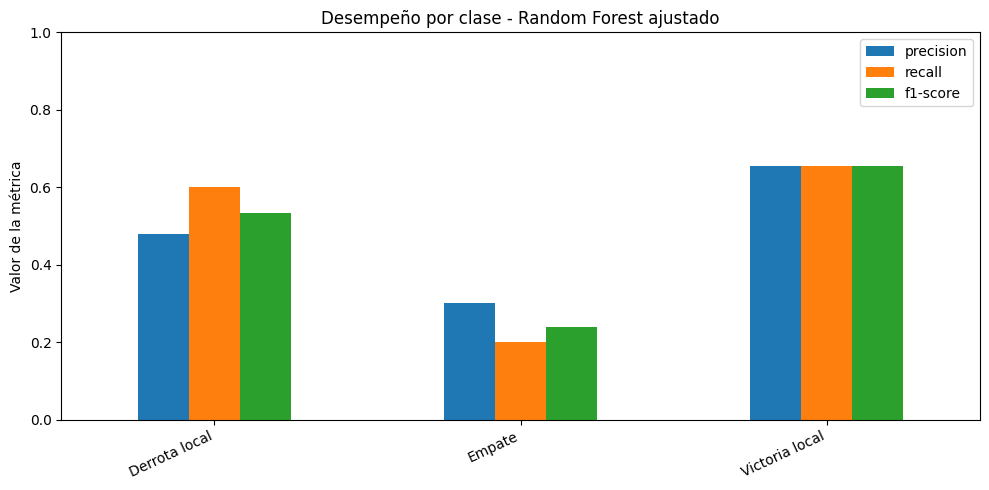

F1-score de la clase empate: 0.2400


In [40]:
best_final_report = classification_report(
    y_test,
    best_final_pred,
    labels=CLASSES,
    target_names=CLASS_NAMES,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(best_final_report).T
metric_cols = [c for c in ["precision", "recall", "f1-score", "support"] if c in report_df.columns]
display(report_df[metric_cols].round(4))

class_report_plot = report_df.loc[CLASS_NAMES, ["precision", "recall", "f1-score"]].copy()
class_report_plot.plot(kind="bar", figsize=(10, 5))
plt.title(f"Desempeño por clase - {modelo_final_nombre}")
plt.ylabel("Valor de la métrica")
plt.ylim(0, 1)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

if "Empate" in report_df.index:
    empate_f1 = report_df.loc["Empate", "f1-score"]
    print(f"F1-score de la clase empate: {empate_f1:.4f}")


## Interpretación del empate

La clase empate debe explicarse con cuidado. Si su F1-score es bajo, no significa que todo el proyecto esté mal. Significa que el empate es un resultado naturalmente más difícil de reconocer.

Puedes decir:

> La clase empate fue la más difícil de predecir. Esto ocurre porque los empates suelen depender de factores tácticos, ritmo del partido, decisiones del entrenador, lesiones, contexto de grupo y nivel de riesgo asumido por cada selección. Muchas de esas variables no están completamente representadas en la base de datos. Por eso, el modelo reconoce mejor victorias o derrotas que empates.

Esta interpretación es importante porque demuestra criterio académico y no solo presentación de métricas.


# 31. Corrección final: visualizaciones avanzadas 3D

Para hacer el trabajo más visual e innovador, se agregan gráficas interactivas con Plotly.

Aclaración importante:

- Una gráfica **3D** muestra tres ejes: X, Y y Z.
- Una visualización **4D** no significa que exista un cuarto eje espacial visible. En análisis de datos, se representa una cuarta dimensión mediante **color**, **tamaño** o **intensidad** del punto.

En este trabajo se usan:

1. Gráfico 3D de variables deportivas.
2. Gráfico 4D usando color y tamaño como dimensiones adicionales.
3. Superficie 3D de probabilidad estimada.
4. Gráfico 3D de probabilidades del Mundial 2026 cuando existan partidos con equipos definidos.


In [41]:
try:
    import plotly.express as px
    import plotly.graph_objects as go
    PLOTLY_AVAILABLE = True
    print("Plotly disponible. Se generarán gráficos interactivos.")
except Exception as error:
    PLOTLY_AVAILABLE = False
    print("Plotly no está disponible en este entorno.")
    print("En Google Colab puedes instalarlo con: !pip install plotly")
    print(error)


Plotly disponible. Se generarán gráficos interactivos.


In [42]:
if PLOTLY_AVAILABLE:
    cols_3d = [
        "diff_ppm",
        "diff_gd_avg",
        "diff_recent_ppm_5",
        "target",
        "home_team_std",
        "away_team_std"
    ]
    cols_3d = [c for c in cols_3d if c in features_df.columns]
    data_3d = features_df[cols_3d].copy().dropna()

    if not data_3d.empty and {"diff_ppm", "diff_gd_avg", "diff_recent_ppm_5", "target"}.issubset(data_3d.columns):
        data_3d["resultado"] = data_3d["target"].map(CLASS_MAP)
        data_3d["partido"] = data_3d.get("home_team_std", "Local").astype(str) + " vs " + data_3d.get("away_team_std", "Visitante").astype(str)

        fig = px.scatter_3d(
            data_3d,
            x="diff_ppm",
            y="diff_gd_avg",
            z="diff_recent_ppm_5",
            color="resultado",
            hover_name="partido",
            title="Visualización 3D: rendimiento histórico, diferencia de gol y forma reciente",
            labels={
                "diff_ppm": "Diferencia de puntos por partido",
                "diff_gd_avg": "Diferencia promedio de gol",
                "diff_recent_ppm_5": "Diferencia de forma reciente"
            }
        )
        fig.show()
    else:
        print("No hay suficientes columnas o datos para construir el gráfico 3D.")


## Interpretación del gráfico 3D

Este gráfico permite observar si los partidos se agrupan según diferencias de rendimiento. La lectura es la siguiente:

- El eje X muestra la diferencia de puntos promedio entre equipos.
- El eje Y muestra la diferencia de gol promedio.
- El eje Z muestra la diferencia de forma reciente.
- El color representa el resultado real del partido.

Si los colores se separan parcialmente, significa que las variables tienen capacidad para diferenciar resultados. Si se mezclan demasiado, significa que el fútbol tiene alta incertidumbre y que hacen falta variables contextuales adicionales.


In [43]:
if PLOTLY_AVAILABLE:
    cols_4d = [
        "diff_ppm",
        "diff_gd_avg",
        "diff_recent_ppm_5",
        "diff_experience",
        "target",
        "home_team_std",
        "away_team_std"
    ]
    cols_4d = [c for c in cols_4d if c in features_df.columns]
    data_4d = features_df[cols_4d].copy().dropna()

    if not data_4d.empty and {"diff_ppm", "diff_gd_avg", "diff_recent_ppm_5", "target"}.issubset(data_4d.columns):
        data_4d["resultado"] = data_4d["target"].map(CLASS_MAP)
        data_4d["experiencia_abs"] = data_4d.get("diff_experience", 0).abs() + 0.1
        data_4d["partido"] = data_4d.get("home_team_std", "Local").astype(str) + " vs " + data_4d.get("away_team_std", "Visitante").astype(str)

        fig = px.scatter_3d(
            data_4d,
            x="diff_ppm",
            y="diff_gd_avg",
            z="diff_recent_ppm_5",
            color="resultado",
            size="experiencia_abs",
            hover_name="partido",
            title="Visualización 4D: tres ejes más color y tamaño",
            labels={
                "diff_ppm": "Diferencia de puntos por partido",
                "diff_gd_avg": "Diferencia promedio de gol",
                "diff_recent_ppm_5": "Diferencia de forma reciente",
                "experiencia_abs": "Diferencia absoluta de experiencia"
            }
        )
        fig.show()
    else:
        print("No hay suficientes columnas o datos para construir el gráfico 4D.")


## Interpretación del gráfico 4D

En esta visualización, los tres ejes muestran variables numéricas y las dimensiones adicionales son:

- **Color:** resultado del partido.
- **Tamaño:** diferencia de experiencia entre equipos.

Puedes explicarlo así:

> La visualización 4D permite analizar simultáneamente rendimiento histórico, diferencia de gol, forma reciente y experiencia. Si los puntos de victoria local se concentran en zonas donde las diferencias son positivas, eso indica que el modelo está usando información coherente con el rendimiento deportivo.


In [44]:
def robust_range(series, n=40):
    series = pd.Series(series).replace([np.inf, -np.inf], np.nan).dropna()
    if series.empty:
        return np.linspace(-1, 1, n)
    q_low, q_high = series.quantile([0.05, 0.95])
    if pd.isna(q_low) or pd.isna(q_high) or q_low == q_high:
        center = float(series.median()) if not pd.isna(series.median()) else 0.0
        return np.linspace(center - 1, center + 1, n)
    return np.linspace(float(q_low), float(q_high), n)

if PLOTLY_AVAILABLE:
    x_var = "diff_ppm"
    y_var = "diff_gd_avg"

    if x_var in model_features and y_var in model_features and best_final_model_object is not None:
        x_grid = robust_range(X_train[x_var], n=35)
        y_grid = robust_range(X_train[y_var], n=35)
        xx, yy = np.meshgrid(x_grid, y_grid)

        base_row = X_train.median(numeric_only=True).reindex(model_features).fillna(0)
        grid_rows = []
        for x_value, y_value in zip(xx.ravel(), yy.ravel()):
            row = base_row.copy()
            row[x_var] = x_value
            row[y_var] = y_value
            grid_rows.append(row)

        grid_df = pd.DataFrame(grid_rows)[model_features]

        try:
            grid_proba = align_proba_generic(
                best_final_model_object,
                best_final_model_object.predict_proba(grid_df)
            )
            z_prob = grid_proba[:, 2].reshape(xx.shape)

            fig = go.Figure(data=[go.Surface(x=xx, y=yy, z=z_prob)])
            fig.update_layout(
                title=f"Superficie 3D de probabilidad de victoria local - {modelo_final_nombre}",
                scene=dict(
                    xaxis_title="Diferencia de puntos por partido",
                    yaxis_title="Diferencia promedio de gol",
                    zaxis_title="Probabilidad de victoria local"
                )
            )
            fig.show()
        except Exception as error:
            print("No fue posible construir la superficie 3D de probabilidad.")
            print(error)
    else:
        print("La superficie 3D requiere un modelo final clasificatorio con predict_proba.")


## Interpretación de la superficie 3D

La superficie 3D muestra cómo cambia la probabilidad estimada de victoria local cuando varían dos factores importantes:

- Diferencia de puntos por partido.
- Diferencia promedio de gol.

La altura de la superficie representa la probabilidad de victoria local.

Puedes decir:

> Cuando la superficie sube, el modelo asigna mayor probabilidad de victoria local. Esto permite interpretar visualmente cómo las diferencias de rendimiento influyen en la predicción. No solo se observa una tabla de números, sino una relación visual entre variables y probabilidad.


In [45]:
if PLOTLY_AVAILABLE:
    predictions_2026_final = predictions_2026.copy()
    predictions_2026_final["prediccion_resultado_final"] = predictions_2026_final["prediccion_resultado"]
    predictions_2026_final["prob_derrota_local_final"] = predictions_2026_final["prob_derrota_local"]
    predictions_2026_final["prob_empate_final"] = predictions_2026_final["prob_empate"]
    predictions_2026_final["prob_victoria_local_final"] = predictions_2026_final["prob_victoria_local"]

    valid_mask_2026_final = predictions_2026_final["prediccion_valida"] == True

    if valid_mask_2026_final.sum() > 0:
        X_2026_final = predictions_2026_final.loc[valid_mask_2026_final, model_features].copy()

        if modelo_final_nombre == "Poisson goles":
            lambda_home_2026_final = np.clip(poisson_home.predict(X_2026_final), 1e-6, 10)
            lambda_away_2026_final = np.clip(poisson_away.predict(X_2026_final), 1e-6, 10)
            proba_2026_final = result_probabilities_from_lambdas(
                lambda_home_2026_final,
                lambda_away_2026_final,
                max_goals=12
            )
            pred_2026_final = np.argmax(proba_2026_final, axis=1)
        elif best_final_model_object is not None:
            pred_2026_final = best_final_model_object.predict(X_2026_final)
            proba_2026_final = align_proba_generic(
                best_final_model_object,
                best_final_model_object.predict_proba(X_2026_final)
            )
        else:
            pred_2026_final = pred_2026_valid
            proba_2026_final = proba_2026_valid

        predictions_2026_final.loc[valid_mask_2026_final, "prediccion_resultado_final"] = pd.Series(pred_2026_final).map(CLASS_MAP).values
        predictions_2026_final.loc[valid_mask_2026_final, "prob_derrota_local_final"] = proba_2026_final[:, 0]
        predictions_2026_final.loc[valid_mask_2026_final, "prob_empate_final"] = proba_2026_final[:, 1]
        predictions_2026_final.loc[valid_mask_2026_final, "prob_victoria_local_final"] = proba_2026_final[:, 2]

        prob_vis_2026 = predictions_2026_final.loc[valid_mask_2026_final].copy()
        prob_vis_2026["confianza_final"] = prob_vis_2026[[
            "prob_derrota_local_final",
            "prob_empate_final",
            "prob_victoria_local_final"
        ]].max(axis=1)

        if schedule_home_col in prob_vis_2026.columns and schedule_away_col in prob_vis_2026.columns:
            prob_vis_2026["partido"] = prob_vis_2026[schedule_home_col].astype(str) + " vs " + prob_vis_2026[schedule_away_col].astype(str)
        else:
            prob_vis_2026["partido"] = "Partido Mundial 2026"

        fig = px.scatter_3d(
            prob_vis_2026,
            x="prob_derrota_local_final",
            y="prob_empate_final",
            z="prob_victoria_local_final",
            color="prediccion_resultado_final",
            size="confianza_final",
            hover_name="partido",
            title="Mapa 3D de probabilidades para partidos estimables del Mundial 2026",
            labels={
                "prob_derrota_local_final": "P(derrota local)",
                "prob_empate_final": "P(empate)",
                "prob_victoria_local_final": "P(victoria local)",
                "confianza_final": "Confianza"
            }
        )
        fig.show()

        output_cols_final = [
            schedule_home_col,
            schedule_away_col,
            "prediccion_valida",
            "prediccion_resultado_final",
            "prob_derrota_local_final",
            "prob_empate_final",
            "prob_victoria_local_final",
            "confianza_final"
        ]
        output_cols_final = [c for c in output_cols_final if c in predictions_2026_final.columns]
        predictions_2026_final[output_cols_final].to_csv("predicciones_mundial_2026_FINAL.csv", index=False)
        display(predictions_2026_final[output_cols_final].head(40))
        print("Archivo exportado: predicciones_mundial_2026_FINAL.csv")
    else:
        print("No hay partidos 2026 con equipos definidos. El gráfico se activará cuando el calendario tenga selecciones definidas.")


,home_team,away_team,prediccion_valida,prediccion_resultado_final,prob_derrota_local_final,prob_empate_final,prob_victoria_local_final
0,Mexico,South Africa,True,Victoria local,0.355254,0.245750,0.398996
1,Korea Republic,Czechia,True,Derrota local,0.552516,0.229625,0.217859
2,Canada,Bosnia-Herzegovina,True,Derrota local,0.377195,0.271329,0.351476
3,United States,Paraguay,True,Victoria local,0.321716,0.280546,0.397739
4,Qatar,Switzerland,True,Derrota local,0.786030,0.148472,0.065498
5,Brazil,Morocco,True,Victoria local,0.147467,0.170992,0.681541
6,Haiti,Scotland,True,Derrota local,0.579633,0.282586,0.137780
7,Australia,Türkiye,True,Derrota local,0.427132,0.306708,0.266160
8,Germany,Curaçao,True,Victoria local,0.227879,0.154148,0.617973
9,Netherlands,Japan,True,Victoria local,0.062379,0.316432,0.621189


Archivo exportado: predicciones_mundial_2026_FINAL.csv


## Interpretación del mapa 3D de probabilidades 2026

Este gráfico representa cada partido como un punto dentro de un espacio de probabilidades:

- Eje X: probabilidad de derrota local.
- Eje Y: probabilidad de empate.
- Eje Z: probabilidad de victoria local.
- Color: resultado predicho.
- Tamaño: confianza del modelo.

Puedes explicarlo así:

> Este gráfico permite observar no solo qué resultado predice el modelo, sino también qué tan seguro está. Un punto grande indica mayor confianza. Si un punto está cerca del centro, significa que el partido es más incierto porque las probabilidades están más repartidas.


# 32. Actualización con resultados reales y predicciones pendientes

En esta sección se mejora la predicción del Mundial 2026 usando dos fuentes:

1. Resultados reales de partidos ya jugados.
2. Predicciones del modelo para partidos pendientes.

De esta manera, el trabajo no reemplaza información real disponible, sino que usa Machine Learning donde todavía no existe resultado oficial.

## 1:cargar tu archivo de resultados reales

In [50]:
# ============================================================
# 32.1 CARGA Y LIMPIEZA DE RESULTADOS REALES 2026
# ============================================================

import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score

# Intentar cargar el archivo con cualquiera de estos nombres
rutas_posibles = [
    "resultados_reales_2026.csv",
    "resultados_reales_2026(1).csv"
]

resultados_reales_2026 = None

for ruta in rutas_posibles:
    try:
        resultados_reales_2026 = pd.read_csv(ruta)
        print(f"Archivo cargado correctamente: {ruta}")
        break
    except FileNotFoundError:
        pass

if resultados_reales_2026 is None:
    raise FileNotFoundError(
        "No se encontró el archivo resultados_reales_2026.csv. "
        "Súbelo a Colab antes de ejecutar esta celda."
    )

print("Columnas originales:")
print(resultados_reales_2026.columns.tolist())

# Renombrar columnas si tu archivo tiene goles_local y goles_visitante
resultados_reales_2026 = resultados_reales_2026.rename(columns={
    "goles_local": "goles_local_real",
    "goles_visitante": "goles_visitante_real"
})

# Verificar columnas necesarias
columnas_necesarias = [
    "equipo_local",
    "equipo_visitante",
    "goles_local_real",
    "goles_visitante_real"
]

faltantes = [c for c in columnas_necesarias if c not in resultados_reales_2026.columns]

if len(faltantes) > 0:
    raise ValueError(f"Faltan estas columnas en resultados_reales_2026: {faltantes}")

# Convertir goles a número
resultados_reales_2026["goles_local_real"] = pd.to_numeric(
    resultados_reales_2026["goles_local_real"],
    errors="coerce"
)

resultados_reales_2026["goles_visitante_real"] = pd.to_numeric(
    resultados_reales_2026["goles_visitante_real"],
    errors="coerce"
)

# Eliminar filas sin goles reales
resultados_reales_2026 = resultados_reales_2026.dropna(
    subset=["goles_local_real", "goles_visitante_real"]
).copy()

resultados_reales_2026["goles_local_real"] = resultados_reales_2026["goles_local_real"].astype(int)
resultados_reales_2026["goles_visitante_real"] = resultados_reales_2026["goles_visitante_real"].astype(int)

def resultado_desde_goles(gl, gv):
    if gl > gv:
        return "Victoria local"
    elif gl < gv:
        return "Derrota local"
    else:
        return "Empate"

resultados_reales_2026["resultado_real"] = resultados_reales_2026.apply(
    lambda fila: resultado_desde_goles(
        fila["goles_local_real"],
        fila["goles_visitante_real"]
    ),
    axis=1
)

print("Resultados reales cargados y limpiados:")
display(resultados_reales_2026.head(20))

print("Cantidad de partidos reales cargados:", resultados_reales_2026.shape[0])

Archivo cargado correctamente: resultados_reales_2026.csv
Columnas originales:
['fecha', 'fase', 'grupo', 'equipo_local', 'equipo_visitante', 'goles_local', 'goles_visitante', 'resultado_real_3clases', 'ganador_real', 'total_goles', 'estado', 'fecha_consulta', 'fuente_principal', 'fuente_verificacion']
Resultados reales cargados y limpiados:


,fecha,fase,grupo,equipo_local,equipo_visitante,goles_local_real,goles_visitante_real,resultado_real_3clases,ganador_real,total_goles,estado,fecha_consulta,fuente_principal,fuente_verificacion,resultado_real
0,2026-06-11,grupos,A,Mexico,South Africa,2,0,local_gana,Mexico,2,finalizado,2026-06-26,https://www.fourfourtwo.com/competition/all-of...,https://www.fifa.com/en/tournaments/mens/world...,Victoria local
1,2026-06-12,grupos,A,South Korea,Czechia,2,1,local_gana,South Korea,3,finalizado,2026-06-26,https://www.fourfourtwo.com/competition/all-of...,https://www.fifa.com/en/tournaments/mens/world...,Victoria local
2,2026-06-12,grupos,B,Canada,Bosnia and Herzegovina,1,1,empate,Empate,2,finalizado,2026-06-26,https://www.fourfourtwo.com/competition/all-of...,https://www.fifa.com/en/tournaments/mens/world...,Empate
3,2026-06-13,grupos,D,United States,Paraguay,4,1,local_gana,United States,5,finalizado,2026-06-26,https://www.fourfourtwo.com/competition/all-of...,https://www.fifa.com/en/tournaments/mens/world...,Victoria local
4,2026-06-13,grupos,B,Qatar,Switzerland,1,1,empate,Empate,2,finalizado,2026-06-26,https://www.fourfourtwo.com/competition/all-of...,https://www.fifa.com/en/tournaments/mens/world...,Empate
5,2026-06-13,grupos,C,Brazil,Morocco,1,1,empate,Empate,2,finalizado,2026-06-26,https://www.fourfourtwo.com/competition/all-of...,https://www.fifa.com/en/tournaments/mens/world...,Empate
6,2026-06-14,grupos,C,Haiti,Scotland,0,1,visitante_gana,Scotland,1,finalizado,2026-06-26,https://www.fourfourtwo.com/competition/all-of...,https://www.fifa.com/en/tournaments/mens/world...,Derrota local
7,2026-06-14,grupos,D,Australia,Turkey,2,0,local_gana,Australia,2,finalizado,2026-06-26,https://www.fourfourtwo.com/competition/all-of...,https://www.fifa.com/en/tournaments/mens/world...,Victoria local
8,2026-06-14,grupos,E,Germany,Curacao,7,1,local_gana,Germany,8,finalizado,2026-06-26,https://www.fourfourtwo.com/competition/all-of...,https://www.fifa.com/en/tournaments/mens/world...,Victoria local
9,2026-06-14,grupos,F,Netherlands,Japan,2,2,empate,Empate,4,finalizado,2026-06-26,https://www.fourfourtwo.com/competition/all-of...,https://www.fifa.com/en/tournaments/mens/world...,Empate


Cantidad de partidos reales cargados: 60


## 3:preparar la tabla de predicciones del modelo

In [51]:
# ============================================================
# 32.2 PREPARACIÓN DE LA TABLA DE PREDICCIONES 2026
# ============================================================

# Tomar la tabla final si existe; si no, usar predictions_2026
if "predictions_2026_final" in globals():
    pred_final = predictions_2026_final.copy()
elif "predictions_2026" in globals():
    pred_final = predictions_2026.copy()
else:
    raise NameError(
        "No existe predictions_2026. Ejecuta primero la sección 25 del notebook."
    )

# Revisar que existan las columnas de equipos
if "schedule_home_col" not in globals() or "schedule_away_col" not in globals():
    raise NameError(
        "No existen schedule_home_col o schedule_away_col. "
        "Ejecuta primero la sección 25."
    )

# Asegurar columnas finales
if "prediccion_resultado_final" not in pred_final.columns:
    pred_final["prediccion_resultado_final"] = pred_final["prediccion_resultado"]

if "prob_derrota_local_final" not in pred_final.columns:
    pred_final["prob_derrota_local_final"] = pred_final["prob_derrota_local"]

if "prob_empate_final" not in pred_final.columns:
    pred_final["prob_empate_final"] = pred_final["prob_empate"]

if "prob_victoria_local_final" not in pred_final.columns:
    pred_final["prob_victoria_local_final"] = pred_final["prob_victoria_local"]

# Crear columna partido
pred_final["partido"] = (
    pred_final[schedule_home_col].astype(str)
    + " vs "
    + pred_final[schedule_away_col].astype(str)
)

# Confianza del modelo
pred_final["confianza_modelo"] = pred_final[
    [
        "prob_derrota_local_final",
        "prob_empate_final",
        "prob_victoria_local_final"
    ]
].max(axis=1)

print("Tabla de predicciones preparada:")
display(
    pred_final[
        [
            schedule_home_col,
            schedule_away_col,
            "partido",
            "prediccion_valida",
            "prediccion_resultado_final",
            "prob_derrota_local_final",
            "prob_empate_final",
            "prob_victoria_local_final",
            "confianza_modelo"
        ]
    ].head(20)
)

Tabla de predicciones preparada:


,home_team,away_team,partido,prediccion_valida,prediccion_resultado_final,prob_derrota_local_final,prob_empate_final,prob_victoria_local_final,confianza_modelo
0,Mexico,South Africa,Mexico vs South Africa,True,Victoria local,0.355254,0.245750,0.398996,0.398996
1,Korea Republic,Czechia,Korea Republic vs Czechia,True,Derrota local,0.552516,0.229625,0.217859,0.552516
2,Canada,Bosnia-Herzegovina,Canada vs Bosnia-Herzegovina,True,Derrota local,0.377195,0.271329,0.351476,0.377195
3,United States,Paraguay,United States vs Paraguay,True,Victoria local,0.321716,0.280546,0.397739,0.397739
4,Qatar,Switzerland,Qatar vs Switzerland,True,Derrota local,0.786030,0.148472,0.065498,0.786030
5,Brazil,Morocco,Brazil vs Morocco,True,Victoria local,0.147467,0.170992,0.681541,0.681541
6,Haiti,Scotland,Haiti vs Scotland,True,Derrota local,0.579633,0.282586,0.137780,0.579633
7,Australia,Türkiye,Australia vs Türkiye,True,Derrota local,0.427132,0.306708,0.266160,0.427132
8,Germany,Curaçao,Germany vs Curaçao,True,Victoria local,0.227879,0.154148,0.617973,0.617973
9,Netherlands,Japan,Netherlands vs Japan,True,Victoria local,0.062379,0.316432,0.621189,0.621189


# 4: asignar grupos correctamente

In [52]:
# ============================================================
# 32.3 ASIGNACIÓN DE GRUPOS DEL MUNDIAL 2026
# ============================================================

def canon_equipo(nombre):
    """
    Normaliza nombres para que coincidan entre schedule_2026 y resultados reales.
    """
    nombre = str(nombre).strip()

    reemplazos = {
        "South Korea": "Korea Republic",
        "Korea Republic": "Korea Republic",

        "Bosnia and Herzegovina": "Bosnia-Herzegovina",
        "Bosnia-Herzegovina": "Bosnia-Herzegovina",

        "Turkey": "Türkiye",
        "Türkiye": "Türkiye",

        "Curacao": "Curaçao",
        "Curaçao": "Curaçao",

        "Ivory Coast": "Côte d'Ivoire",
        "Côte d'Ivoire": "Côte d'Ivoire",

        "Iran": "IR Iran",
        "IR Iran": "IR Iran",

        "DR Congo": "Congo DR",
        "Congo DR": "Congo DR"
    }

    return reemplazos.get(nombre, nombre)

grupos_mundial_2026 = {
    "A": ["Mexico", "South Africa", "Korea Republic", "Czechia"],
    "B": ["Canada", "Bosnia-Herzegovina", "Qatar", "Switzerland"],
    "C": ["Brazil", "Morocco", "Haiti", "Scotland"],
    "D": ["United States", "Paraguay", "Australia", "Türkiye"],
    "E": ["Germany", "Curaçao", "Côte d'Ivoire", "Ecuador"],
    "F": ["Netherlands", "Japan", "Sweden", "Tunisia"],
    "G": ["Belgium", "Egypt", "IR Iran", "New Zealand"],
    "H": ["Spain", "Cape Verde", "Saudi Arabia", "Uruguay"],
    "I": ["France", "Senegal", "Iraq", "Norway"],
    "J": ["Argentina", "Algeria", "Austria", "Jordan"],
    "K": ["Portugal", "Congo DR", "Uzbekistan", "Colombia"],
    "L": ["England", "Croatia", "Ghana", "Panama"]
}

grupo_por_equipo = {}

for grupo, equipos in grupos_mundial_2026.items():
    for equipo in equipos:
        grupo_por_equipo[canon_equipo(equipo)] = grupo

def obtener_grupo_equipo(nombre):
    return grupo_por_equipo.get(canon_equipo(nombre), np.nan)

pred_final["grupo_local"] = pred_final[schedule_home_col].apply(obtener_grupo_equipo)
pred_final["grupo_visitante"] = pred_final[schedule_away_col].apply(obtener_grupo_equipo)

pred_final["grupo"] = pred_final["grupo_local"]

# Verificar problemas
problemas_grupo = pred_final[
    pred_final["grupo_local"] != pred_final["grupo_visitante"]
][
    [schedule_home_col, schedule_away_col, "grupo_local", "grupo_visitante"]
]

if problemas_grupo.empty:
    print("Todos los partidos tienen grupo correctamente asignado.")
else:
    print("Revisar estos partidos porque no coinciden los grupos:")
    display(problemas_grupo)

display(
    pred_final[
        [
            "grupo",
            schedule_home_col,
            schedule_away_col,
            "partido",
            "prediccion_resultado_final"
        ]
    ].head(30)
)

Todos los partidos tienen grupo correctamente asignado.


,grupo,home_team,away_team,partido,prediccion_resultado_final
0,A,Mexico,South Africa,Mexico vs South Africa,Victoria local
1,A,Korea Republic,Czechia,Korea Republic vs Czechia,Derrota local
2,B,Canada,Bosnia-Herzegovina,Canada vs Bosnia-Herzegovina,Derrota local
3,D,United States,Paraguay,United States vs Paraguay,Victoria local
4,B,Qatar,Switzerland,Qatar vs Switzerland,Derrota local
5,C,Brazil,Morocco,Brazil vs Morocco,Victoria local
6,C,Haiti,Scotland,Haiti vs Scotland,Derrota local
7,D,Australia,Türkiye,Australia vs Türkiye,Derrota local
8,E,Germany,Curaçao,Germany vs Curaçao,Victoria local
9,F,Netherlands,Japan,Netherlands vs Japan,Victoria local



# 5: estimar marcador con Poisson


In [54]:
# ============================================================
# 32.4 ESTIMACIÓN DEL MARCADOR CON MODELO POISSON
# ============================================================

def poisson_probs_manual(lam, max_goals=8):
    """
    Probabilidades de goles 0, 1, 2, ..., max_goals usando Poisson.
    """
    lam = max(float(lam), 1e-8)
    probs = np.zeros(max_goals + 1)
    probs[0] = np.exp(-lam)

    for g in range(1, max_goals + 1):
        probs[g] = probs[g - 1] * lam / g

    return probs

def marcador_mas_probable_condicionado(lambda_local, lambda_visitante, resultado_predicho, max_goals=8):
    """
    Busca el marcador más probable compatible con el resultado predicho.
    """

    probs_local = poisson_probs_manual(lambda_local, max_goals=max_goals)
    probs_visitante = poisson_probs_manual(lambda_visitante, max_goals=max_goals)

    matriz_prob = np.outer(probs_local, probs_visitante)

    goles_local_grid = np.arange(max_goals + 1)[:, None]
    goles_visitante_grid = np.arange(max_goals + 1)[None, :]

    texto = str(resultado_predicho).lower()

    if "victoria local" in texto:
        mascara = goles_local_grid > goles_visitante_grid
    elif "empate" in texto:
        mascara = goles_local_grid == goles_visitante_grid
    elif "derrota local" in texto or "victoria visitante" in texto:
        mascara = goles_local_grid < goles_visitante_grid
    else:
        mascara = np.ones_like(matriz_prob, dtype=bool)

    matriz_filtrada = np.where(mascara, matriz_prob, -1)
    indice = np.unravel_index(np.argmax(matriz_filtrada), matriz_filtrada.shape)

    goles_local = int(indice[0])
    goles_visitante = int(indice[1])
    prob_marcador = float(matriz_prob[indice])

    return goles_local, goles_visitante, prob_marcador

# Verificar que existan los modelos Poisson
if "poisson_home" not in globals() or "poisson_away" not in globals():
    raise NameError("Faltan poisson_home o poisson_away. Ejecuta primero la sección 18.")

if "model_features" not in globals():
    raise NameError("Falta model_features. Ejecuta primero la sección 13.")

# Crear columnas
pred_final["goles_local_esperados"] = np.nan
pred_final["goles_visitante_esperados"] = np.nan
pred_final["goles_local_estimados"] = pd.Series([pd.NA] * len(pred_final), dtype="Int64")
pred_final["goles_visitante_estimados"] = pd.Series([pd.NA] * len(pred_final), dtype="Int64")
pred_final["probabilidad_marcador_estimado"] = np.nan

mascara_valida = pred_final["prediccion_valida"] == True

X_2026_poisson = pred_final.loc[mascara_valida, model_features].copy()

lambda_local = poisson_home.predict(X_2026_poisson)
lambda_visitante = poisson_away.predict(X_2026_poisson)

lambda_local = np.clip(lambda_local, 1e-6, 10)
lambda_visitante = np.clip(lambda_visitante, 1e-6, 10)

pred_final.loc[mascara_valida, "goles_local_esperados"] = lambda_local
pred_final.loc[mascara_valida, "goles_visitante_esperados"] = lambda_visitante

indices_validos = pred_final.loc[mascara_valida].index.tolist()

for idx, lh, la in zip(indices_validos, lambda_local, lambda_visitante):
    resultado_predicho = pred_final.loc[idx, "prediccion_resultado_final"]

    gl, gv, prob_score = marcador_mas_probable_condicionado(
        lh,
        la,
        resultado_predicho,
        max_goals=8
    )

    pred_final.loc[idx, "goles_local_estimados"] = gl
    pred_final.loc[idx, "goles_visitante_estimados"] = gv
    pred_final.loc[idx, "probabilidad_marcador_estimado"] = prob_score

def resultado_por_marcador(gl, gv):
    if pd.isna(gl) or pd.isna(gv):
        return "No estimable"
    if gl > gv:
        return "Victoria local"
    elif gl < gv:
        return "Derrota local"
    else:
        return "Empate"

pred_final["resultado_por_marcador"] = pred_final.apply(
    lambda fila: resultado_por_marcador(
        fila["goles_local_estimados"],
        fila["goles_visitante_estimados"]
    ),
    axis=1
)

pred_final["marcador_estimado"] = (
    pred_final[schedule_home_col].astype(str)
    + " "
    + pred_final["goles_local_estimados"].astype(str)
    + " - "
    + pred_final["goles_visitante_estimados"].astype(str)
    + " "
    + pred_final[schedule_away_col].astype(str)
)

tabla_marcadores_predichos = pred_final[
    [
        "grupo",
        "partido",
        schedule_home_col,
        schedule_away_col,
        "goles_local_esperados",
        "goles_visitante_esperados",
        "goles_local_estimados",
        "goles_visitante_estimados",
        "marcador_estimado",
        "resultado_por_marcador",
        "prediccion_resultado_final",
        "confianza_modelo"
    ]
].copy()

print("Marcadores estimados por el modelo:")
display(tabla_marcadores_predichos.head(30))

tabla_marcadores_predichos.to_csv(
    "predicciones_marcadores_mundial_2026.csv",
    index=False
)

print("Archivo exportado: predicciones_marcadores_mundial_2026.csv")

Marcadores estimados por el modelo:


,grupo,partido,home_team,away_team,goles_local_esperados,goles_visitante_esperados,goles_local_estimados,goles_visitante_estimados,marcador_estimado,resultado_por_marcador,prediccion_resultado_final,confianza_modelo
0,A,Mexico vs South Africa,Mexico,South Africa,1.399387,0.911319,1,0,Mexico 1 - 0 South Africa,Victoria local,Victoria local,0.398996
1,A,Korea Republic vs Czechia,Korea Republic,Czechia,1.532914,1.012984,0,1,Korea Republic 0 - 1 Czechia,Derrota local,Derrota local,0.552516
2,B,Canada vs Bosnia-Herzegovina,Canada,Bosnia-Herzegovina,1.437823,1.407134,1,2,Canada 1 - 2 Bosnia-Herzegovina,Derrota local,Derrota local,0.377195
3,D,United States vs Paraguay,United States,Paraguay,1.175065,1.103716,1,0,United States 1 - 0 Paraguay,Victoria local,Victoria local,0.397739
4,B,Qatar vs Switzerland,Qatar,Switzerland,1.087495,1.671424,0,1,Qatar 0 - 1 Switzerland,Derrota local,Derrota local,0.786030
5,C,Brazil vs Morocco,Brazil,Morocco,1.738012,0.689232,1,0,Brazil 1 - 0 Morocco,Victoria local,Victoria local,0.681541
6,C,Haiti vs Scotland,Haiti,Scotland,1.183652,1.580061,0,1,Haiti 0 - 1 Scotland,Derrota local,Derrota local,0.579633
7,D,Australia vs Türkiye,Australia,Türkiye,1.304996,1.262633,0,1,Australia 0 - 1 Türkiye,Derrota local,Derrota local,0.427132
8,E,Germany vs Curaçao,Germany,Curaçao,1.950201,0.677881,1,0,Germany 1 - 0 Curaçao,Victoria local,Victoria local,0.617973
9,F,Netherlands vs Japan,Netherlands,Japan,1.667903,0.884332,1,0,Netherlands 1 - 0 Japan,Victoria local,Victoria local,0.621189


Archivo exportado: predicciones_marcadores_mundial_2026.csv


# 6: combinar resultados reales + predicciones

In [55]:
# ============================================================
# 32.5 COMBINAR RESULTADOS REALES + PREDICCIONES
# ============================================================

# Crear claves normalizadas para unir tablas
pred_final["local_key"] = pred_final[schedule_home_col].apply(canon_equipo)
pred_final["visitante_key"] = pred_final[schedule_away_col].apply(canon_equipo)

resultados_reales_2026["local_key"] = resultados_reales_2026["equipo_local"].apply(canon_equipo)
resultados_reales_2026["visitante_key"] = resultados_reales_2026["equipo_visitante"].apply(canon_equipo)

# Unir resultados reales con las predicciones
pred_actualizado = pred_final.merge(
    resultados_reales_2026[
        [
            "local_key",
            "visitante_key",
            "goles_local_real",
            "goles_visitante_real",
            "resultado_real"
        ]
    ],
    on=["local_key", "visitante_key"],
    how="left"
)

# Si hay resultado real, se usa el real.
# Si no hay resultado real, se usa la predicción.
pred_actualizado["goles_local_final"] = pred_actualizado["goles_local_real"].fillna(
    pred_actualizado["goles_local_estimados"]
)

pred_actualizado["goles_visitante_final"] = pred_actualizado["goles_visitante_real"].fillna(
    pred_actualizado["goles_visitante_estimados"]
)

pred_actualizado["tipo_resultado_usado"] = np.where(
    pred_actualizado["goles_local_real"].notna(),
    "Resultado real",
    "Predicción del modelo"
)

pred_actualizado["resultado_final_usado"] = pred_actualizado.apply(
    lambda fila: resultado_por_marcador(
        fila["goles_local_final"],
        fila["goles_visitante_final"]
    ),
    axis=1
)

pred_actualizado["marcador_final_usado"] = (
    pred_actualizado[schedule_home_col].astype(str)
    + " "
    + pred_actualizado["goles_local_final"].astype("Int64").astype(str)
    + " - "
    + pred_actualizado["goles_visitante_final"].astype("Int64").astype(str)
    + " "
    + pred_actualizado[schedule_away_col].astype(str)
)

tabla_marcadores_actualizada = pred_actualizado[
    [
        "grupo",
        "partido",
        schedule_home_col,
        schedule_away_col,
        "marcador_estimado",
        "marcador_final_usado",
        "tipo_resultado_usado",
        "resultado_por_marcador",
        "resultado_final_usado",
        "confianza_modelo"
    ]
].copy()

print("Tabla final: resultados reales + predicciones restantes")
display(tabla_marcadores_actualizada.head(40))

tabla_marcadores_actualizada.to_csv(
    "marcadores_actualizados_reales_y_predichos_2026.csv",
    index=False
)

print("Archivo exportado: marcadores_actualizados_reales_y_predichos_2026.csv")

Tabla final: resultados reales + predicciones restantes


,grupo,partido,home_team,away_team,marcador_estimado,marcador_final_usado,tipo_resultado_usado,resultado_por_marcador,resultado_final_usado,confianza_modelo
0,A,Mexico vs South Africa,Mexico,South Africa,Mexico 1 - 0 South Africa,Mexico 2 - 0 South Africa,Resultado real,Victoria local,Victoria local,0.398996
1,A,Korea Republic vs Czechia,Korea Republic,Czechia,Korea Republic 0 - 1 Czechia,Korea Republic 2 - 1 Czechia,Resultado real,Derrota local,Victoria local,0.552516
2,B,Canada vs Bosnia-Herzegovina,Canada,Bosnia-Herzegovina,Canada 1 - 2 Bosnia-Herzegovina,Canada 1 - 1 Bosnia-Herzegovina,Resultado real,Derrota local,Empate,0.377195
3,D,United States vs Paraguay,United States,Paraguay,United States 1 - 0 Paraguay,United States 4 - 1 Paraguay,Resultado real,Victoria local,Victoria local,0.397739
4,B,Qatar vs Switzerland,Qatar,Switzerland,Qatar 0 - 1 Switzerland,Qatar 1 - 1 Switzerland,Resultado real,Derrota local,Empate,0.786030
5,C,Brazil vs Morocco,Brazil,Morocco,Brazil 1 - 0 Morocco,Brazil 1 - 1 Morocco,Resultado real,Victoria local,Empate,0.681541
6,C,Haiti vs Scotland,Haiti,Scotland,Haiti 0 - 1 Scotland,Haiti 0 - 1 Scotland,Resultado real,Derrota local,Derrota local,0.579633
7,D,Australia vs Türkiye,Australia,Türkiye,Australia 0 - 1 Türkiye,Australia 2 - 0 Türkiye,Resultado real,Derrota local,Victoria local,0.427132
8,E,Germany vs Curaçao,Germany,Curaçao,Germany 1 - 0 Curaçao,Germany 7 - 1 Curaçao,Resultado real,Victoria local,Victoria local,0.617973
9,F,Netherlands vs Japan,Netherlands,Japan,Netherlands 1 - 0 Japan,Netherlands 2 - 2 Japan,Resultado real,Victoria local,Empate,0.621189


Archivo exportado: marcadores_actualizados_reales_y_predichos_2026.csv


# 7: evaluar si el modelo está acertando

In [56]:
# ============================================================
# 32.6 EVALUACIÓN DEL MODELO CONTRA RESULTADOS REALES
# ============================================================

partidos_con_resultado_real = pred_actualizado[
    pred_actualizado["tipo_resultado_usado"] == "Resultado real"
].copy()

if partidos_con_resultado_real.empty:
    print("Todavía no hay partidos reales para evaluar.")
else:
    partidos_con_resultado_real["acierto_resultado"] = (
        partidos_con_resultado_real["resultado_por_marcador"]
        ==
        partidos_con_resultado_real["resultado_final_usado"]
    )

    partidos_con_resultado_real["acierto_marcador_exacto"] = (
        (partidos_con_resultado_real["goles_local_estimados"] == partidos_con_resultado_real["goles_local_real"])
        &
        (partidos_con_resultado_real["goles_visitante_estimados"] == partidos_con_resultado_real["goles_visitante_real"])
    )

    accuracy_resultado = partidos_con_resultado_real["acierto_resultado"].mean()
    accuracy_marcador_exacto = partidos_con_resultado_real["acierto_marcador_exacto"].mean()

    print("Evaluación contra resultados reales")
    print("=" * 60)
    print("Partidos reales evaluados:", partidos_con_resultado_real.shape[0])
    print("Accuracy del resultado:", round(accuracy_resultado, 4))
    print("Accuracy del marcador exacto:", round(accuracy_marcador_exacto, 4))

    display(
        partidos_con_resultado_real[
            [
                "grupo",
                "partido",
                "marcador_estimado",
                "marcador_final_usado",
                "resultado_por_marcador",
                "resultado_final_usado",
                "acierto_resultado",
                "acierto_marcador_exacto"
            ]
        ]
    )

Evaluación contra resultados reales
Partidos reales evaluados: 57
Accuracy del resultado: 0.5789
Accuracy del marcador exacto: 0.1053


,grupo,partido,marcador_estimado,marcador_final_usado,resultado_por_marcador,resultado_final_usado,acierto_resultado,acierto_marcador_exacto
0,A,Mexico vs South Africa,Mexico 1 - 0 South Africa,Mexico 2 - 0 South Africa,Victoria local,Victoria local,True,False
1,A,Korea Republic vs Czechia,Korea Republic 0 - 1 Czechia,Korea Republic 2 - 1 Czechia,Derrota local,Victoria local,False,False
2,B,Canada vs Bosnia-Herzegovina,Canada 1 - 2 Bosnia-Herzegovina,Canada 1 - 1 Bosnia-Herzegovina,Derrota local,Empate,False,False
3,D,United States vs Paraguay,United States 1 - 0 Paraguay,United States 4 - 1 Paraguay,Victoria local,Victoria local,True,False
4,B,Qatar vs Switzerland,Qatar 0 - 1 Switzerland,Qatar 1 - 1 Switzerland,Derrota local,Empate,False,False
5,C,Brazil vs Morocco,Brazil 1 - 0 Morocco,Brazil 1 - 1 Morocco,Victoria local,Empate,False,False
6,C,Haiti vs Scotland,Haiti 0 - 1 Scotland,Haiti 0 - 1 Scotland,Derrota local,Derrota local,True,True
7,D,Australia vs Türkiye,Australia 0 - 1 Türkiye,Australia 2 - 0 Türkiye,Derrota local,Victoria local,False,False
8,E,Germany vs Curaçao,Germany 1 - 0 Curaçao,Germany 7 - 1 Curaçao,Victoria local,Victoria local,True,False
9,F,Netherlands vs Japan,Netherlands 1 - 0 Japan,Netherlands 2 - 2 Japan,Victoria local,Empate,False,False


# 8: comparar todos los modelos con resultados reales

In [57]:
# ============================================================
# 32.7 COMPARACIÓN DE MODELOS CON RESULTADOS REALES 2026
# ============================================================

def predecir_2026_con_modelo(nombre_modelo, modelo, X_2026):
    """
    Genera predicciones para 2026 con modelos de clasificación.
    """
    pred = modelo.predict(X_2026)

    if hasattr(modelo, "predict_proba"):
        proba_raw = modelo.predict_proba(X_2026)

        if "align_proba_generic" in globals():
            proba = align_proba_generic(modelo, proba_raw)
        else:
            proba = align_proba_to_classes(modelo, proba_raw)
    else:
        proba = None

    pred_texto = pd.Series(pred).map(CLASS_MAP).values

    return pred_texto, proba

# Solo se evalúan partidos que tienen resultado real y predicción válida
eval_modelos = pred_actualizado[
    (pred_actualizado["tipo_resultado_usado"] == "Resultado real")
    &
    (pred_actualizado["prediccion_valida"] == True)
].copy()

if eval_modelos.empty:
    print("No hay partidos reales suficientes para comparar modelos.")
else:
    X_eval_2026 = eval_modelos[model_features].copy()

    resumen_modelos_2026 = []

    # Modelos de clasificación guardados en tu notebook
    if "model_registry" in globals():
        for nombre_modelo, modelo in model_registry.items():
            try:
                pred_texto, proba = predecir_2026_con_modelo(
                    nombre_modelo,
                    modelo,
                    X_eval_2026
                )

                y_real = eval_modelos["resultado_final_usado"].values

                resumen_modelos_2026.append({
                    "Modelo": nombre_modelo,
                    "Partidos evaluados": len(y_real),
                    "Accuracy en vivo": accuracy_score(y_real, pred_texto),
                    "Balanced Accuracy en vivo": balanced_accuracy_score(y_real, pred_texto),
                    "F1-score en vivo": f1_score(y_real, pred_texto, average="weighted", zero_division=0)
                })

            except Exception as e:
                print(f"No se pudo evaluar {nombre_modelo}: {e}")

    # Evaluar también Poisson goles
    try:
        lambda_home_eval = np.clip(poisson_home.predict(X_eval_2026), 1e-6, 10)
        lambda_away_eval = np.clip(poisson_away.predict(X_eval_2026), 1e-6, 10)

        proba_poisson_eval = result_probabilities_from_lambdas(
            lambda_home_eval,
            lambda_away_eval,
            max_goals=12
        )

        pred_poisson_eval = np.argmax(proba_poisson_eval, axis=1)
        pred_poisson_texto = pd.Series(pred_poisson_eval).map(CLASS_MAP).values

        y_real = eval_modelos["resultado_final_usado"].values

        resumen_modelos_2026.append({
            "Modelo": "Poisson goles",
            "Partidos evaluados": len(y_real),
            "Accuracy en vivo": accuracy_score(y_real, pred_poisson_texto),
            "Balanced Accuracy en vivo": balanced_accuracy_score(y_real, pred_poisson_texto),
            "F1-score en vivo": f1_score(y_real, pred_poisson_texto, average="weighted", zero_division=0)
        })

    except Exception as e:
        print("No se pudo evaluar Poisson goles:", e)

    resumen_modelos_2026 = pd.DataFrame(resumen_modelos_2026)

    if resumen_modelos_2026.empty:
        print("No se pudo construir la comparación de modelos.")
    else:
        resumen_modelos_2026 = resumen_modelos_2026.sort_values(
            by="F1-score en vivo",
            ascending=False
        )

        print("Comparación de modelos con partidos reales del Mundial 2026:")
        display(resumen_modelos_2026.round(4))

        resumen_modelos_2026.to_csv(
            "comparacion_modelos_resultados_reales_2026.csv",
            index=False
        )

        print("Archivo exportado: comparacion_modelos_resultados_reales_2026.csv")

Comparación de modelos con partidos reales del Mundial 2026:


,Modelo,Partidos evaluados,Accuracy en vivo,Balanced Accuracy en vivo,F1-score en vivo
3,Random Forest ajustado,57,0.5789,0.5261,0.5566
2,Random Forest,57,0.5614,0.5039,0.5282
6,Poisson goles,57,0.6140,0.4741,0.5095
1,Logit Lasso,57,0.4737,0.5155,0.4811
0,Logit Ridge,57,0.4211,0.4718,0.4255
4,Baseline clase frecuente,57,0.5439,0.3333,0.3832
5,Baseline aleatorio estratificado,57,0.3860,0.3067,0.3814


Archivo exportado: comparacion_modelos_resultados_reales_2026.csv


# 9: tabla de posiciones actualizada

In [58]:
# ============================================================
# 32.8 TABLA DE POSICIONES ACTUALIZADA
# RESULTADOS REALES + PREDICCIONES PENDIENTES
# ============================================================

# Ranking FIFA para desempate
ranking_map = {}

if "fifa2026_table" in globals():
    try:
        ranking_map = (
            fifa2026_table
            .dropna(subset=["team_std", "fifa_rank"])
            .drop_duplicates("team_std")
            .set_index("team_std")["fifa_rank"]
            .to_dict()
        )
    except Exception:
        ranking_map = {}

def obtener_ranking_fifa(nombre_equipo):
    if "standardize_team_name" in globals():
        nombre_std = standardize_team_name(nombre_equipo)
        return ranking_map.get(nombre_std, 999)
    return 999

def crear_tabla_posiciones_actualizada(df, col_local, col_visitante):
    estadisticas = {}

    def inicializar_equipo(grupo, equipo):
        clave = (grupo, equipo)

        if clave not in estadisticas:
            estadisticas[clave] = {
                "grupo": grupo,
                "equipo": equipo,
                "PJ": 0,
                "PG": 0,
                "PE": 0,
                "PP": 0,
                "GF": 0,
                "GC": 0,
                "DG": 0,
                "puntos": 0,
                "ranking_fifa_2026": obtener_ranking_fifa(equipo)
            }

    for _, fila in df.iterrows():
        grupo = fila["grupo"]
        local = fila[col_local]
        visitante = fila[col_visitante]

        gl = fila["goles_local_final"]
        gv = fila["goles_visitante_final"]

        if pd.isna(grupo) or pd.isna(gl) or pd.isna(gv):
            continue

        gl = int(gl)
        gv = int(gv)

        inicializar_equipo(grupo, local)
        inicializar_equipo(grupo, visitante)

        clave_local = (grupo, local)
        clave_visitante = (grupo, visitante)

        estadisticas[clave_local]["PJ"] += 1
        estadisticas[clave_visitante]["PJ"] += 1

        estadisticas[clave_local]["GF"] += gl
        estadisticas[clave_local]["GC"] += gv

        estadisticas[clave_visitante]["GF"] += gv
        estadisticas[clave_visitante]["GC"] += gl

        if gl > gv:
            estadisticas[clave_local]["PG"] += 1
            estadisticas[clave_visitante]["PP"] += 1
            estadisticas[clave_local]["puntos"] += 3

        elif gl < gv:
            estadisticas[clave_visitante]["PG"] += 1
            estadisticas[clave_local]["PP"] += 1
            estadisticas[clave_visitante]["puntos"] += 3

        else:
            estadisticas[clave_local]["PE"] += 1
            estadisticas[clave_visitante]["PE"] += 1
            estadisticas[clave_local]["puntos"] += 1
            estadisticas[clave_visitante]["puntos"] += 1

    tabla = pd.DataFrame(estadisticas.values())

    tabla["DG"] = tabla["GF"] - tabla["GC"]

    tabla = tabla.sort_values(
        by=["grupo", "puntos", "DG", "GF", "ranking_fifa_2026"],
        ascending=[True, False, False, False, True]
    )

    tabla["posicion_grupo"] = tabla.groupby("grupo").cumcount() + 1

    return tabla[
        [
            "grupo",
            "posicion_grupo",
            "equipo",
            "PJ",
            "PG",
            "PE",
            "PP",
            "GF",
            "GC",
            "DG",
            "puntos",
            "ranking_fifa_2026"
        ]
    ]

tabla_posiciones_actualizada = crear_tabla_posiciones_actualizada(
    pred_actualizado,
    schedule_home_col,
    schedule_away_col
)

print("Tabla de posiciones actualizada:")
display(tabla_posiciones_actualizada)

tabla_posiciones_actualizada.to_csv(
    "tabla_posiciones_actualizada_2026.csv",
    index=False
)

print("Archivo exportado: tabla_posiciones_actualizada_2026.csv")

Tabla de posiciones actualizada:


,grupo,posicion_grupo,equipo,PJ,PG,PE,PP,GF,GC,DG,puntos,ranking_fifa_2026
0,A,1,Mexico,3,3,0,0,6,0,6,9,14
1,A,2,South Africa,3,1,1,1,2,3,-1,4,60
2,A,3,Korea Republic,3,1,0,2,2,3,-1,3,25
3,A,4,Czechia,3,0,1,2,2,6,-4,1,39
9,B,1,Switzerland,3,2,1,0,7,3,4,7,19
4,B,2,Canada,3,1,1,1,8,3,5,4,30
5,B,3,Bosnia-Herzegovina,3,1,1,1,5,6,-1,4,64
8,B,4,Qatar,3,0,1,2,2,10,-8,1,57
10,C,1,Brazil,3,2,1,0,7,1,6,7,6
11,C,2,Morocco,3,2,1,0,6,3,3,7,7


Archivo exportado: tabla_posiciones_actualizada_2026.csv


# 10: clasificados a la siguiente fase

In [61]:
# ============================================================
# 32.9 CLASIFICADOS A OCTAVOS DE FINAL
# ============================================================
# Regla usada para este trabajo académico:
# Clasifican 16 selecciones:
# 1) Los 12 primeros de cada grupo.
# 2) Los 4 mejores segundos.

# Verificar que exista la tabla de posiciones
if "tabla_posiciones_actualizada" in globals():
    tabla_base_octavos = tabla_posiciones_actualizada.copy()
elif "tabla_posiciones" in globals():
    tabla_base_octavos = tabla_posiciones.copy()
else:
    raise NameError(
        "No existe tabla_posiciones_actualizada ni tabla_posiciones. "
        "Ejecuta primero la celda de tabla de posiciones."
    )

# Si no existe ranking FIFA, se crea una columna auxiliar para evitar errores
if "ranking_fifa_2026" not in tabla_base_octavos.columns:
    tabla_base_octavos["ranking_fifa_2026"] = 999

# ------------------------------------------------------------
# 1. Clasifican los primeros de cada grupo
# ------------------------------------------------------------

primeros_grupo = tabla_base_octavos[
    tabla_base_octavos["posicion_grupo"] == 1
].copy()

primeros_grupo["tipo_clasificacion"] = "1.º del grupo"

# ------------------------------------------------------------
# 2. Clasifican los 4 mejores segundos
# ------------------------------------------------------------

segundos_grupo = tabla_base_octavos[
    tabla_base_octavos["posicion_grupo"] == 2
].copy()

mejores_segundos = segundos_grupo.sort_values(
    by=["puntos", "DG", "GF", "ranking_fifa_2026"],
    ascending=[False, False, False, True]
).head(4)

mejores_segundos["tipo_clasificacion"] = "Mejor segundo"

# ------------------------------------------------------------
# 3. Unión final: 12 primeros + 4 mejores segundos = 16
# ------------------------------------------------------------

clasificados_octavos = pd.concat(
    [primeros_grupo, mejores_segundos],
    ignore_index=True
)

clasificados_octavos = clasificados_octavos.sort_values(
    by=["grupo", "tipo_clasificacion", "posicion_grupo"]
)

# ------------------------------------------------------------
# 4. Mostrar resultado final
# ------------------------------------------------------------

print("SELECCIONES CLASIFICADAS A OCTAVOS DE FINAL")
print("=" * 70)

display(
    clasificados_octavos[
        [
            "grupo",
            "posicion_grupo",
            "equipo",
            "PJ",
            "PG",
            "PE",
            "PP",
            "GF",
            "GC",
            "DG",
            "puntos",
            "tipo_clasificacion"
        ]
    ]
)

print("Cantidad total de selecciones clasificadas a octavos:", clasificados_octavos.shape[0])

# Exportar resultado
clasificados_octavos.to_csv(
    "clasificados_octavos_16_selecciones.csv",
    index=False
)

print("Archivo exportado: clasificados_octavos_16_selecciones.csv")

SELECCIONES CLASIFICADAS A OCTAVOS DE FINAL


,grupo,posicion_grupo,equipo,PJ,PG,PE,PP,GF,GC,DG,puntos,tipo_clasificacion
0,A,1,Mexico,3,3,0,0,6,0,6,9,1.º del grupo
1,B,1,Switzerland,3,2,1,0,7,3,4,7,1.º del grupo
2,C,1,Brazil,3,2,1,0,7,1,6,7,1.º del grupo
12,C,2,Morocco,3,2,1,0,6,3,3,7,Mejor segundo
3,D,1,United States,3,2,0,1,8,4,4,6,1.º del grupo
4,E,1,Germany,3,2,0,1,10,4,6,6,1.º del grupo
14,E,2,Côte d'Ivoire,3,2,0,1,4,2,2,6,Mejor segundo
5,F,1,Netherlands,3,2,1,0,10,4,6,7,1.º del grupo
6,G,1,IR Iran,3,1,2,0,3,2,1,5,1.º del grupo
7,H,1,Spain,3,2,1,0,5,0,5,7,1.º del grupo


Cantidad total de selecciones clasificadas a octavos: 16
Archivo exportado: clasificados_octavos_16_selecciones.csv


In [62]:
# ============================================================
# RESUMEN DE CLASIFICADOS A OCTAVOS POR GRUPO
# ============================================================

resumen_octavos_por_grupo = (
    clasificados_octavos
    .groupby("grupo")["equipo"]
    .apply(lambda x: ", ".join(x.astype(str)))
    .reset_index()
)

resumen_octavos_por_grupo.columns = [
    "Grupo",
    "Selecciones clasificadas a octavos"
]

display(resumen_octavos_por_grupo)

,Grupo,Selecciones clasificadas a octavos
0,A,Mexico
1,B,Switzerland
2,C,"Brazil, Morocco"
3,D,United States
4,E,"Germany, Côte d'Ivoire"
5,F,Netherlands
6,G,IR Iran
7,H,Spain
8,I,"France, Norway"
9,J,"Argentina, Austria"


In [63]:
# ============================================================
# SEPARACIÓN: PRIMEROS DE GRUPO Y MEJORES SEGUNDOS
# ============================================================

clasificados_primeros = clasificados_octavos[
    clasificados_octavos["tipo_clasificacion"] == "1.º del grupo"
].copy()

clasificados_mejores_segundos = clasificados_octavos[
    clasificados_octavos["tipo_clasificacion"] == "Mejor segundo"
].copy()

print("PRIMEROS DE CADA GRUPO")
display(
    clasificados_primeros[
        ["grupo", "equipo", "puntos", "DG", "GF", "tipo_clasificacion"]
    ]
)

print("CUATRO MEJORES SEGUNDOS")
display(
    clasificados_mejores_segundos[
        ["grupo", "equipo", "puntos", "DG", "GF", "tipo_clasificacion"]
    ]
)

PRIMEROS DE CADA GRUPO


,grupo,equipo,puntos,DG,GF,tipo_clasificacion
0,A,Mexico,9,6,6,1.º del grupo
1,B,Switzerland,7,4,7,1.º del grupo
2,C,Brazil,7,6,7,1.º del grupo
3,D,United States,6,4,8,1.º del grupo
4,E,Germany,6,6,10,1.º del grupo
5,F,Netherlands,7,6,10,1.º del grupo
6,G,IR Iran,5,1,3,1.º del grupo
7,H,Spain,7,5,5,1.º del grupo
8,I,France,9,6,7,1.º del grupo
9,J,Argentina,9,6,6,1.º del grupo


CUATRO MEJORES SEGUNDOS


,grupo,equipo,puntos,DG,GF,tipo_clasificacion
12,C,Morocco,7,3,6,Mejor segundo
14,E,Côte d'Ivoire,6,2,4,Mejor segundo
13,I,Norway,6,3,7,Mejor segundo
15,J,Austria,6,1,4,Mejor segundo


In [64]:
# ============================================================
# LISTA FINAL DE 16 SELECCIONES CLASIFICADAS A OCTAVOS
# ============================================================

lista_octavos = clasificados_octavos["equipo"].tolist()

print("LISTA FINAL DE SELECCIONES QUE PASAN A OCTAVOS")
print("=" * 70)

for i, equipo in enumerate(lista_octavos, start=1):
    print(f"{i}. {equipo}")

print("\nTotal:", len(lista_octavos), "selecciones")

LISTA FINAL DE SELECCIONES QUE PASAN A OCTAVOS
1. Mexico
2. Switzerland
3. Brazil
4. Morocco
5. United States
6. Germany
7. Côte d'Ivoire
8. Netherlands
9. IR Iran
10. Spain
11. France
12. Norway
13. Argentina
14. Austria
15. Colombia
16. England

Total: 16 selecciones


In [70]:
tabla_posiciones_actualizada

,grupo,posicion_grupo,equipo,PJ,PG,PE,PP,GF,GC,DG,puntos,ranking_fifa_2026
0,A,1,Mexico,3,3,0,0,6,0,6,9,14
1,A,2,South Africa,3,1,1,1,2,3,-1,4,60
2,A,3,Korea Republic,3,1,0,2,2,3,-1,3,25
3,A,4,Czechia,3,0,1,2,2,6,-4,1,39
9,B,1,Switzerland,3,2,1,0,7,3,4,7,19
4,B,2,Canada,3,1,1,1,8,3,5,4,30
5,B,3,Bosnia-Herzegovina,3,1,1,1,5,6,-1,4,64
8,B,4,Qatar,3,0,1,2,2,10,-8,1,57
10,C,1,Brazil,3,2,1,0,7,1,6,7,6
11,C,2,Morocco,3,2,1,0,6,3,3,7,7


In [74]:
# ============================================================
# 32.9 - 32.14 RESULTADOS FINALES DETERMINÍSTICOS
# DIECISEISAVOS, POISSON CALIBRADO Y CLASIFICADOS A OCTAVOS
# ============================================================

import pandas as pd
import numpy as np
from math import lgamma, log
from IPython.display import display

# ============================================================
# 0. VERIFICACIONES INICIALES
# ============================================================

if "tabla_posiciones_actualizada" not in globals():
    raise NameError(
        "No existe tabla_posiciones_actualizada. "
        "Primero ejecuta la celda donde construyes la tabla de posiciones actualizada."
    )

if "build_future_features" not in globals():
    raise NameError(
        "No existe build_future_features. "
        "Primero ejecuta la sección donde preparas las variables para partidos futuros."
    )

if "schedule_home_col" not in globals() or "schedule_away_col" not in globals():
    raise NameError(
        "No existen schedule_home_col o schedule_away_col. "
        "Primero ejecuta la sección donde detectas las columnas de equipos."
    )

if "poisson_home" not in globals() or "poisson_away" not in globals():
    raise NameError(
        "No existen poisson_home o poisson_away. "
        "Primero ejecuta la sección donde entrenas el modelo Poisson."
    )

if "model_features" not in globals():
    raise NameError(
        "No existe model_features. "
        "Primero ejecuta la sección donde defines las variables predictoras del modelo."
    )

print("Verificaciones correctas.")
print("Se usará Poisson calibrado determinístico. No se usará aleatoriedad.")


# ============================================================
# 1. CLASIFICADOS A DIECISEISAVOS DE FINAL
# ============================================================
# Regla:
# - Clasifican los 2 primeros de cada grupo.
# - Clasifican los 8 mejores terceros.
# Total: 24 + 8 = 32 selecciones.

tabla_base = tabla_posiciones_actualizada.copy()

columnas_necesarias = [
    "grupo", "posicion_grupo", "equipo", "PJ", "PG", "PE", "PP",
    "GF", "GC", "DG", "puntos"
]

faltantes_tabla = [c for c in columnas_necesarias if c not in tabla_base.columns]

if faltantes_tabla:
    raise ValueError(
        "Faltan columnas en tabla_posiciones_actualizada: "
        + str(faltantes_tabla)
    )

if "ranking_fifa_2026" not in tabla_base.columns:
    tabla_base["ranking_fifa_2026"] = 999

tabla_base["ranking_fifa_2026"] = pd.to_numeric(
    tabla_base["ranking_fifa_2026"],
    errors="coerce"
).fillna(999)

dos_primeros = tabla_base[
    tabla_base["posicion_grupo"] <= 2
].copy()

dos_primeros["tipo_clasificacion"] = "1.º o 2.º del grupo"

terceros = tabla_base[
    tabla_base["posicion_grupo"] == 3
].copy()

mejores_terceros = terceros.sort_values(
    by=["puntos", "DG", "GF", "ranking_fifa_2026"],
    ascending=[False, False, False, True]
).head(8).copy()

mejores_terceros["tipo_clasificacion"] = "Mejor tercero"

clasificados_dieciseisavos = pd.concat(
    [dos_primeros, mejores_terceros],
    ignore_index=True
)

clasificados_dieciseisavos = clasificados_dieciseisavos.sort_values(
    by=["posicion_grupo", "puntos", "DG", "GF", "ranking_fifa_2026"],
    ascending=[True, False, False, False, True]
).reset_index(drop=True)

clasificados_dieciseisavos["seed_diecisavos"] = range(
    1,
    len(clasificados_dieciseisavos) + 1
)

print("\n32.9 CLASIFICADOS A DIECISEISAVOS DE FINAL")
print("=" * 90)

display(
    clasificados_dieciseisavos[
        [
            "seed_diecisavos",
            "grupo",
            "posicion_grupo",
            "equipo",
            "PJ",
            "PG",
            "PE",
            "PP",
            "GF",
            "GC",
            "DG",
            "puntos",
            "ranking_fifa_2026",
            "tipo_clasificacion"
        ]
    ]
)

print("Total de clasificados a dieciseisavos:", clasificados_dieciseisavos.shape[0])

clasificados_dieciseisavos.to_csv(
    "clasificados_dieciseisavos_32_selecciones.csv",
    index=False
)


# ============================================================
# 2. PARTIDOS DE DIECISEISAVOS SEGÚN CUADRO FIFA
# ============================================================

clasificados_base = clasificados_dieciseisavos.copy()

def obtener_equipo_por_grupo_posicion(grupo, posicion):
    filtro = clasificados_base[
        (clasificados_base["grupo"].astype(str) == str(grupo))
        &
        (clasificados_base["posicion_grupo"] == posicion)
    ]

    if filtro.empty:
        raise ValueError(
            f"No se encontró equipo del grupo {grupo} en posición {posicion}. "
            "Revisa la tabla de posiciones."
        )

    return filtro.iloc[0]


terceros_clasificados = clasificados_base[
    clasificados_base["posicion_grupo"] == 3
].copy()

grupos_terceros = sorted(terceros_clasificados["grupo"].astype(str).tolist())

print("\nGrupos que clasificaron como mejores terceros:")
print(grupos_terceros)

slots_terceros_permitidos = {
    74: ["A", "B", "C", "D", "F"],
    77: ["C", "D", "F", "G", "H"],
    79: ["C", "E", "F", "H", "I"],
    80: ["E", "H", "I", "J", "K"],
    81: ["B", "E", "F", "I", "J"],
    82: ["A", "E", "H", "I", "J"],
    85: ["E", "F", "G", "I", "J"],
    87: ["D", "E", "I", "J", "L"],
}

mapa_terceros_conocido = {
    "BDEFGIKL": {
        74: "D",
        77: "F",
        79: "E",
        80: "K",
        81: "B",
        82: "I",
        85: "G",
        87: "L",
    }
}

clave_terceros = "".join(grupos_terceros)


def asignar_terceros_compatible(grupos_terceros, slots_permitidos):
    grupos_terceros = sorted(grupos_terceros)

    partidos = sorted(
        slots_permitidos.keys(),
        key=lambda p: len(set(slots_permitidos[p]).intersection(set(grupos_terceros)))
    )

    def backtrack(i, usados, asignacion):
        if i == len(partidos):
            return asignacion.copy()

        partido = partidos[i]

        candidatos = [
            g for g in grupos_terceros
            if g not in usados and g in slots_permitidos[partido]
        ]

        for g in candidatos:
            asignacion[partido] = g
            usados.add(g)

            resultado = backtrack(i + 1, usados, asignacion)

            if resultado is not None:
                return resultado

            usados.remove(g)
            del asignacion[partido]

        return None

    asignacion_final = backtrack(0, set(), {})

    if asignacion_final is None:
        raise ValueError(
            "No se pudo asignar los mejores terceros a los cruces permitidos. "
            "Revisa qué grupos clasificaron como terceros."
        )

    return asignacion_final


if clave_terceros in mapa_terceros_conocido:
    asignacion_terceros = mapa_terceros_conocido[clave_terceros]
    print("\nAsignación de terceros tomada de combinación conocida.")
else:
    asignacion_terceros = asignar_terceros_compatible(
        grupos_terceros,
        slots_terceros_permitidos
    )
    print("\nAsignación de terceros generada respetando casillas permitidas.")

print("Asignación de terceros:")
print(asignacion_terceros)


def crear_partido_oficial(numero_partido, slot_local, slot_visitante, fila_local, fila_visitante):
    return {
        "numero_partido": numero_partido,
        "fase": "Dieciseisavos de final",

        "slot_local": slot_local,
        "equipo_local": fila_local["equipo"],
        "grupo_local": fila_local["grupo"],
        "posicion_local": fila_local["posicion_grupo"],
        "puntos_local_grupos": fila_local["puntos"],
        "DG_local_grupos": fila_local["DG"],
        "GF_local_grupos": fila_local["GF"],
        "GC_local_grupos": fila_local["GC"],
        "ranking_local": fila_local["ranking_fifa_2026"],
        "seed_local": fila_local["seed_diecisavos"],

        "slot_visitante": slot_visitante,
        "equipo_visitante": fila_visitante["equipo"],
        "grupo_visitante": fila_visitante["grupo"],
        "posicion_visitante": fila_visitante["posicion_grupo"],
        "puntos_visitante_grupos": fila_visitante["puntos"],
        "DG_visitante_grupos": fila_visitante["DG"],
        "GF_visitante_grupos": fila_visitante["GF"],
        "GC_visitante_grupos": fila_visitante["GC"],
        "ranking_visitante": fila_visitante["ranking_fifa_2026"],
        "seed_visitante": fila_visitante["seed_diecisavos"],
    }


partidos_lista = []

partidos_lista.append(crear_partido_oficial(73, "2A", "2B", obtener_equipo_por_grupo_posicion("A", 2), obtener_equipo_por_grupo_posicion("B", 2)))

g74 = asignacion_terceros[74]
partidos_lista.append(crear_partido_oficial(74, "1E", f"3{g74}", obtener_equipo_por_grupo_posicion("E", 1), obtener_equipo_por_grupo_posicion(g74, 3)))

partidos_lista.append(crear_partido_oficial(75, "1F", "2C", obtener_equipo_por_grupo_posicion("F", 1), obtener_equipo_por_grupo_posicion("C", 2)))
partidos_lista.append(crear_partido_oficial(76, "1C", "2F", obtener_equipo_por_grupo_posicion("C", 1), obtener_equipo_por_grupo_posicion("F", 2)))

g77 = asignacion_terceros[77]
partidos_lista.append(crear_partido_oficial(77, "1I", f"3{g77}", obtener_equipo_por_grupo_posicion("I", 1), obtener_equipo_por_grupo_posicion(g77, 3)))

partidos_lista.append(crear_partido_oficial(78, "2E", "2I", obtener_equipo_por_grupo_posicion("E", 2), obtener_equipo_por_grupo_posicion("I", 2)))

g79 = asignacion_terceros[79]
partidos_lista.append(crear_partido_oficial(79, "1A", f"3{g79}", obtener_equipo_por_grupo_posicion("A", 1), obtener_equipo_por_grupo_posicion(g79, 3)))

g80 = asignacion_terceros[80]
partidos_lista.append(crear_partido_oficial(80, "1L", f"3{g80}", obtener_equipo_por_grupo_posicion("L", 1), obtener_equipo_por_grupo_posicion(g80, 3)))

g81 = asignacion_terceros[81]
partidos_lista.append(crear_partido_oficial(81, "1D", f"3{g81}", obtener_equipo_por_grupo_posicion("D", 1), obtener_equipo_por_grupo_posicion(g81, 3)))

g82 = asignacion_terceros[82]
partidos_lista.append(crear_partido_oficial(82, "1G", f"3{g82}", obtener_equipo_por_grupo_posicion("G", 1), obtener_equipo_por_grupo_posicion(g82, 3)))

partidos_lista.append(crear_partido_oficial(83, "2K", "2L", obtener_equipo_por_grupo_posicion("K", 2), obtener_equipo_por_grupo_posicion("L", 2)))
partidos_lista.append(crear_partido_oficial(84, "1H", "2J", obtener_equipo_por_grupo_posicion("H", 1), obtener_equipo_por_grupo_posicion("J", 2)))

g85 = asignacion_terceros[85]
partidos_lista.append(crear_partido_oficial(85, "1B", f"3{g85}", obtener_equipo_por_grupo_posicion("B", 1), obtener_equipo_por_grupo_posicion(g85, 3)))

partidos_lista.append(crear_partido_oficial(86, "1J", "2H", obtener_equipo_por_grupo_posicion("J", 1), obtener_equipo_por_grupo_posicion("H", 2)))

g87 = asignacion_terceros[87]
partidos_lista.append(crear_partido_oficial(87, "1K", f"3{g87}", obtener_equipo_por_grupo_posicion("K", 1), obtener_equipo_por_grupo_posicion(g87, 3)))

partidos_lista.append(crear_partido_oficial(88, "2D", "2G", obtener_equipo_por_grupo_posicion("D", 2), obtener_equipo_por_grupo_posicion("G", 2)))

partidos_dieciseisavos = pd.DataFrame(partidos_lista)

partidos_dieciseisavos = partidos_dieciseisavos.sort_values(
    by="numero_partido"
).reset_index(drop=True)

print("\n32.10 PARTIDOS DE DIECISEISAVOS DE FINAL")
print("=" * 90)

display(partidos_dieciseisavos)

partidos_dieciseisavos.to_csv(
    "partidos_dieciseisavos_cuadro_fifa.csv",
    index=False
)


# ============================================================
# 3. PREPARAR DIECISEISAVOS PARA EL MODELO
# ============================================================

dieciseisavos_modelo = pd.DataFrame()

dieciseisavos_modelo["round"] = "Dieciseisavos de final"
dieciseisavos_modelo["day"] = np.nan
dieciseisavos_modelo["date"] = np.nan
dieciseisavos_modelo["time"] = np.nan
dieciseisavos_modelo["score"] = np.nan
dieciseisavos_modelo["referee"] = np.nan
dieciseisavos_modelo["notes"] = np.nan
dieciseisavos_modelo["year"] = 2026

dieciseisavos_modelo[schedule_home_col] = partidos_dieciseisavos["equipo_local"]
dieciseisavos_modelo[schedule_away_col] = partidos_dieciseisavos["equipo_visitante"]

metadata_cols = [
    "numero_partido",
    "fase",
    "slot_local",
    "slot_visitante",
    "seed_local",
    "seed_visitante",
    "grupo_local",
    "grupo_visitante",
    "posicion_local",
    "posicion_visitante",
    "ranking_local",
    "ranking_visitante",
    "puntos_local_grupos",
    "puntos_visitante_grupos",
    "DG_local_grupos",
    "DG_visitante_grupos",
    "GF_local_grupos",
    "GF_visitante_grupos",
    "GC_local_grupos",
    "GC_visitante_grupos"
]

for col in metadata_cols:
    dieciseisavos_modelo[col] = partidos_dieciseisavos[col]

features_dieciseisavos = build_future_features(dieciseisavos_modelo)

for col in metadata_cols:
    if col not in features_dieciseisavos.columns:
        features_dieciseisavos[col] = dieciseisavos_modelo[col].values

if "prediccion_valida" not in features_dieciseisavos.columns:
    features_dieciseisavos["prediccion_valida"] = True

faltantes_modelo = [c for c in model_features if c not in features_dieciseisavos.columns]

if faltantes_modelo:
    raise ValueError(
        "Faltan variables en features_dieciseisavos para predecir: "
        + str(faltantes_modelo)
    )

print("\n32.11 VARIABLES DE DIECISEISAVOS PREPARADAS")
print("=" * 90)

display(
    features_dieciseisavos[
        [
            "numero_partido",
            "slot_local",
            "slot_visitante",
            schedule_home_col,
            schedule_away_col,
            "prediccion_valida"
        ]
    ]
)


# ============================================================
# 4. FUNCIONES DE POISSON Y CALIBRACIÓN
# ============================================================

def poisson_probs_manual(lam, max_goals=12):
    lam = max(float(lam), 1e-8)
    probs = np.zeros(max_goals + 1)
    probs[0] = np.exp(-lam)

    for g in range(1, max_goals + 1):
        probs[g] = probs[g - 1] * lam / g

    return probs


def result_probabilities_from_lambdas_deterministico(lambda_home, lambda_away, max_goals=12):
    resultados = []

    for lh, la in zip(lambda_home, lambda_away):
        p_home = poisson_probs_manual(lh, max_goals)
        p_away = poisson_probs_manual(la, max_goals)

        matriz = np.outer(p_home, p_away)

        goles_home = np.arange(max_goals + 1)[:, None]
        goles_away = np.arange(max_goals + 1)[None, :]

        p_derrota = matriz[goles_home < goles_away].sum()
        p_empate = matriz[goles_home == goles_away].sum()
        p_victoria = matriz[goles_home > goles_away].sum()

        total = p_derrota + p_empate + p_victoria

        if total > 0:
            p_derrota = p_derrota / total
            p_empate = p_empate / total
            p_victoria = p_victoria / total

        resultados.append([p_derrota, p_empate, p_victoria])

    return np.array(resultados)


def log_poisson(k, lam):
    lam = max(float(lam), 1e-8)
    return -lam + k * log(lam) - lgamma(k + 1)


# Estadísticas de fase de grupos
tabla_stats = tabla_posiciones_actualizada.copy()

if "ranking_fifa_2026" not in tabla_stats.columns:
    tabla_stats["ranking_fifa_2026"] = 999

tabla_stats["ranking_fifa_2026"] = pd.to_numeric(
    tabla_stats["ranking_fifa_2026"],
    errors="coerce"
).fillna(999)

tabla_stats["PJ_seguro"] = tabla_stats["PJ"].replace(0, np.nan)

tabla_stats["puntos_por_partido"] = tabla_stats["puntos"] / tabla_stats["PJ_seguro"]
tabla_stats["goles_favor_pp"] = tabla_stats["GF"] / tabla_stats["PJ_seguro"]
tabla_stats["goles_contra_pp"] = tabla_stats["GC"] / tabla_stats["PJ_seguro"]
tabla_stats["dg_pp"] = tabla_stats["DG"] / tabla_stats["PJ_seguro"]

tabla_stats = tabla_stats.fillna({
    "puntos_por_partido": 0,
    "goles_favor_pp": 0,
    "goles_contra_pp": 0,
    "dg_pp": 0
})

promedio_goles_favor = max(tabla_stats["goles_favor_pp"].mean(), 0.50)
promedio_goles_contra = max(tabla_stats["goles_contra_pp"].mean(), 0.50)

stats_por_equipo = tabla_stats.set_index("equipo").to_dict("index")


def obtener_stats_equipo(equipo):
    equipo = str(equipo).strip()

    if equipo in stats_por_equipo:
        return stats_por_equipo[equipo]

    for nombre, valores in stats_por_equipo.items():
        if str(nombre).lower().strip() == equipo.lower():
            return valores

    return {
        "puntos_por_partido": tabla_stats["puntos_por_partido"].mean(),
        "goles_favor_pp": promedio_goles_favor,
        "goles_contra_pp": promedio_goles_contra,
        "dg_pp": tabla_stats["dg_pp"].mean(),
        "posicion_grupo": 2,
        "ranking_fifa_2026": 999
    }


def calibrar_goles_esperados(fila):
    equipo_local = fila[schedule_home_col]
    equipo_visitante = fila[schedule_away_col]

    stats_local = obtener_stats_equipo(equipo_local)
    stats_visitante = obtener_stats_equipo(equipo_visitante)

    lambda_local_modelo = float(fila["goles_local_esperados"])
    lambda_visitante_modelo = float(fila["goles_visitante_esperados"])

    ataque_local = stats_local["goles_favor_pp"] / promedio_goles_favor
    defensa_visitante = stats_visitante["goles_contra_pp"] / promedio_goles_contra

    ataque_visitante = stats_visitante["goles_favor_pp"] / promedio_goles_favor
    defensa_local = stats_local["goles_contra_pp"] / promedio_goles_contra

    lambda_local_grupos = promedio_goles_favor * ataque_local * defensa_visitante
    lambda_visitante_grupos = promedio_goles_favor * ataque_visitante * defensa_local

    lambda_local = 0.55 * lambda_local_modelo + 0.45 * lambda_local_grupos
    lambda_visitante = 0.55 * lambda_visitante_modelo + 0.45 * lambda_visitante_grupos

    ppg_diff = stats_local["puntos_por_partido"] - stats_visitante["puntos_por_partido"]
    dg_diff = stats_local["dg_pp"] - stats_visitante["dg_pp"]

    ranking_local = float(stats_local.get("ranking_fifa_2026", 999))
    ranking_visitante = float(stats_visitante.get("ranking_fifa_2026", 999))

    ranking_diff = (ranking_visitante - ranking_local) / 100

    fuerza_relativa = (
        0.45 * ppg_diff +
        0.35 * dg_diff +
        0.20 * ranking_diff
    )

    fuerza_relativa = np.clip(fuerza_relativa, -1.80, 1.80)

    factor_local = np.exp(0.28 * fuerza_relativa)
    factor_visitante = np.exp(-0.28 * fuerza_relativa)

    lambda_local = lambda_local * factor_local
    lambda_visitante = lambda_visitante * factor_visitante

    # Ajuste suave para fase eliminatoria
    lambda_local = lambda_local * 0.98
    lambda_visitante = lambda_visitante * 0.98

    lambda_local = np.clip(lambda_local, 0.20, 5.20)
    lambda_visitante = np.clip(lambda_visitante, 0.20, 5.20)

    return lambda_local, lambda_visitante, fuerza_relativa


def seleccionar_marcador_deterministico(fila, max_goles=7):
    lambda_local, lambda_visitante, fuerza_relativa = calibrar_goles_esperados(fila)

    mejor_score = -np.inf
    mejor_gl = 0
    mejor_gv = 0
    mejor_prob_log = -np.inf

    total_esperado = lambda_local + lambda_visitante
    diferencia_esperada = lambda_local - lambda_visitante

    # Objetivos calibrados para evitar que todo se concentre en 1-0
    objetivo_total = total_esperado + 0.20 * min(abs(fuerza_relativa), 1.80)
    objetivo_diferencia = diferencia_esperada + 0.18 * fuerza_relativa

    for gl in range(0, max_goles + 1):
        for gv in range(0, max_goles + 1):

            if gl + gv > 9:
                continue

            log_prob = log_poisson(gl, lambda_local) + log_poisson(gv, lambda_visitante)

            penalizacion_total = 0.07 * ((gl + gv) - objetivo_total) ** 2
            penalizacion_diferencia = 0.10 * ((gl - gv) - objetivo_diferencia) ** 2

            score = log_prob - penalizacion_total - penalizacion_diferencia

            if score > mejor_score:
                mejor_score = score
                mejor_gl = gl
                mejor_gv = gv
                mejor_prob_log = log_prob

    return pd.Series([
        mejor_gl,
        mejor_gv,
        np.exp(mejor_prob_log),
        lambda_local,
        lambda_visitante,
        fuerza_relativa
    ])


# ============================================================
# 5. PREDICCIÓN DE GOLES, RESULTADO Y MARCADOR
# ============================================================

resultados_dieciseisavos = features_dieciseisavos.copy()

resultados_dieciseisavos["partido"] = (
    resultados_dieciseisavos[schedule_home_col].astype(str)
    + " vs "
    + resultados_dieciseisavos[schedule_away_col].astype(str)
)

mascara_valida = resultados_dieciseisavos["prediccion_valida"] == True

X_dieciseisavos = resultados_dieciseisavos.loc[
    mascara_valida,
    model_features
].copy()

lambda_local_base = np.clip(poisson_home.predict(X_dieciseisavos), 1e-6, 10)
lambda_visitante_base = np.clip(poisson_away.predict(X_dieciseisavos), 1e-6, 10)

resultados_dieciseisavos.loc[mascara_valida, "goles_local_esperados"] = lambda_local_base
resultados_dieciseisavos.loc[mascara_valida, "goles_visitante_esperados"] = lambda_visitante_base

resultados_dieciseisavos[[
    "goles_local_estimados",
    "goles_visitante_estimados",
    "probabilidad_marcador_estimado",
    "goles_local_esperados_calibrados",
    "goles_visitante_esperados_calibrados",
    "fuerza_relativa"
]] = resultados_dieciseisavos.apply(
    seleccionar_marcador_deterministico,
    axis=1
)

resultados_dieciseisavos["goles_local_estimados"] = resultados_dieciseisavos[
    "goles_local_estimados"
].astype("Int64")

resultados_dieciseisavos["goles_visitante_estimados"] = resultados_dieciseisavos[
    "goles_visitante_estimados"
].astype("Int64")

proba_resultado = result_probabilities_from_lambdas_deterministico(
    resultados_dieciseisavos.loc[mascara_valida, "goles_local_esperados_calibrados"].values,
    resultados_dieciseisavos.loc[mascara_valida, "goles_visitante_esperados_calibrados"].values,
    max_goals=12
)

pred_clase = np.argmax(proba_resultado, axis=1)

mapa_resultado = {
    0: "Derrota local",
    1: "Empate",
    2: "Victoria local"
}

pred_texto = pd.Series(pred_clase).map(mapa_resultado).values

resultados_dieciseisavos.loc[mascara_valida, "prediccion_resultado"] = pred_texto
resultados_dieciseisavos.loc[mascara_valida, "prob_derrota_local"] = proba_resultado[:, 0]
resultados_dieciseisavos.loc[mascara_valida, "prob_empate"] = proba_resultado[:, 1]
resultados_dieciseisavos.loc[mascara_valida, "prob_victoria_local"] = proba_resultado[:, 2]
resultados_dieciseisavos.loc[mascara_valida, "confianza_modelo"] = proba_resultado.max(axis=1)


# ============================================================
# 6. DEFINIR CLASIFICADO A OCTAVOS
# ============================================================

def definir_clasificado_octavos(fila):
    gl = fila["goles_local_estimados"]
    gv = fila["goles_visitante_estimados"]

    local = fila[schedule_home_col]
    visitante = fila[schedule_away_col]

    if pd.isna(gl) or pd.isna(gv):
        return pd.Series(["No estimable", "No estimable"])

    if gl > gv:
        return pd.Series([local, "Gana en tiempo reglamentario"])

    elif gl < gv:
        return pd.Series([visitante, "Gana en tiempo reglamentario"])

    else:
        prob_local = float(fila.get("prob_victoria_local", 0))
        prob_visitante = float(fila.get("prob_derrota_local", 0))

        if prob_local >= prob_visitante:
            return pd.Series([local, "Empate; clasifica por penales según mayor probabilidad del modelo"])
        else:
            return pd.Series([visitante, "Empate; clasifica por penales según mayor probabilidad del modelo"])


resultados_dieciseisavos[[
    "clasificado_octavos",
    "criterio_clasificacion"
]] = resultados_dieciseisavos.apply(
    definir_clasificado_octavos,
    axis=1
)

resultados_dieciseisavos["marcador_estimado"] = (
    resultados_dieciseisavos[schedule_home_col].astype(str)
    + " "
    + resultados_dieciseisavos["goles_local_estimados"].astype(str)
    + " - "
    + resultados_dieciseisavos["goles_visitante_estimados"].astype(str)
    + " "
    + resultados_dieciseisavos[schedule_away_col].astype(str)
)


# ============================================================
# 7. TABLA FINAL DE DIECISEISAVOS
# ============================================================

columnas_finales = [
    "numero_partido",
    "round",
    "slot_local",
    "slot_visitante",
    schedule_home_col,
    schedule_away_col,
    "partido",
    "goles_local_esperados",
    "goles_visitante_esperados",
    "goles_local_esperados_calibrados",
    "goles_visitante_esperados_calibrados",
    "fuerza_relativa",
    "marcador_estimado",
    "probabilidad_marcador_estimado",
    "prediccion_resultado",
    "prob_derrota_local",
    "prob_empate",
    "prob_victoria_local",
    "confianza_modelo",
    "clasificado_octavos",
    "criterio_clasificacion"
]

columnas_finales = [
    c for c in columnas_finales
    if c in resultados_dieciseisavos.columns
]

tabla_dieciseisavos_final = resultados_dieciseisavos[columnas_finales].copy()

tabla_dieciseisavos_final = tabla_dieciseisavos_final.sort_values(
    "numero_partido"
)

print("\n32.12 DATA FINAL DE DIECISEISAVOS CON POISSON CALIBRADO")
print("=" * 90)

display(tabla_dieciseisavos_final)

tabla_dieciseisavos_final.to_csv(
    "respuesta_1_dieciseisavos_resultados_estimados.csv",
    index=False
)


# ============================================================
# 8. CLASIFICADOS A OCTAVOS
# ============================================================

clasificados_octavos = tabla_dieciseisavos_final[
    [
        "numero_partido",
        "partido",
        "marcador_estimado",
        "clasificado_octavos",
        "criterio_clasificacion",
        "confianza_modelo"
    ]
].copy()

clasificados_octavos = clasificados_octavos.sort_values(
    "numero_partido"
)

print("\n32.13 CLASIFICADOS A OCTAVOS DE FINAL")
print("=" * 90)

display(clasificados_octavos)

print("Cantidad de clasificados a octavos:", clasificados_octavos.shape[0])

clasificados_octavos.to_csv(
    "respuesta_2_clasificados_a_octavos.csv",
    index=False
)


# ============================================================
# 9. REVISIÓN DE VARIEDAD DE MARCADORES
# ============================================================

frecuencia_marcadores = (
    tabla_dieciseisavos_final["marcador_estimado"]
    .value_counts()
    .reset_index()
)

frecuencia_marcadores.columns = [
    "marcador_estimado",
    "frecuencia"
]

print("\nFRECUENCIA DE MARCADORES ESTIMADOS")
print("=" * 90)

display(frecuencia_marcadores)


# ============================================================
# 10. RESUMEN FINAL PARA EL DOCENTE
# ============================================================

print("\n32.14 RESPUESTAS FINALES DEL ENTREGABLE")
print("=" * 90)

print("\nPregunta 1: ¿Qué países clasificarían a la siguiente fase?")
print("Respuesta: clasifican a octavos los ganadores de los 16 partidos de dieciseisavos:\n")

for i, equipo in enumerate(clasificados_octavos["clasificado_octavos"].tolist(), start=1):
    print(f"{i}. {equipo}")

print("\nPregunta 2: ¿Cuál sería el marcador estimado de cada partido?")
print("Respuesta: se muestra en la tabla completa de dieciseisavos.")
print("Archivo generado: respuesta_1_dieciseisavos_resultados_estimados.csv")

print("\nArchivos finales generados:")
print("- clasificados_dieciseisavos_32_selecciones.csv")
print("- partidos_dieciseisavos_cuadro_fifa.csv")
print("- respuesta_1_dieciseisavos_resultados_estimados.csv")
print("- respuesta_2_clasificados_a_octavos.csv")

print("\nComprobación:")
print("Este bloque no usa rng, no usa simulación aleatoria y no usa np.random.")
print("Los marcadores salen por Poisson calibrado + rendimiento de grupos + ranking FIFA.")

Verificaciones correctas.
Se usará Poisson calibrado determinístico. No se usará aleatoriedad.

32.9 CLASIFICADOS A DIECISEISAVOS DE FINAL


,seed_diecisavos,grupo,posicion_grupo,equipo,PJ,PG,PE,PP,GF,GC,DG,puntos,ranking_fifa_2026,tipo_clasificacion
0,1,I,1,France,3,3,0,0,7,1,6,9,3,1.º o 2.º del grupo
1,2,J,1,Argentina,3,3,0,0,6,0,6,9,1,1.º o 2.º del grupo
2,3,A,1,Mexico,3,3,0,0,6,0,6,9,14,1.º o 2.º del grupo
3,4,K,1,Colombia,3,3,0,0,3,0,3,9,13,1.º o 2.º del grupo
4,5,F,1,Netherlands,3,2,1,0,10,4,6,7,8,1.º o 2.º del grupo
5,6,C,1,Brazil,3,2,1,0,7,1,6,7,6,1.º o 2.º del grupo
6,7,H,1,Spain,3,2,1,0,5,0,5,7,2,1.º o 2.º del grupo
7,8,B,1,Switzerland,3,2,1,0,7,3,4,7,19,1.º o 2.º del grupo
8,9,L,1,England,3,2,1,0,6,2,4,7,4,1.º o 2.º del grupo
9,10,E,1,Germany,3,2,0,1,10,4,6,6,10,1.º o 2.º del grupo


Total de clasificados a dieciseisavos: 32

Grupos que clasificaron como mejores terceros:
['B', 'D', 'E', 'F', 'G', 'I', 'K', 'L']

Asignación de terceros tomada de combinación conocida.
Asignación de terceros:
{74: 'D', 77: 'F', 79: 'E', 80: 'K', 81: 'B', 82: 'I', 85: 'G', 87: 'L'}

32.10 PARTIDOS DE DIECISEISAVOS DE FINAL


,numero_partido,fase,slot_local,equipo_local,grupo_local,posicion_local,puntos_local_grupos,DG_local_grupos,GF_local_grupos,GC_local_grupos,ranking_local,seed_local,slot_visitante,equipo_visitante,grupo_visitante,posicion_visitante,puntos_visitante_grupos,DG_visitante_grupos,GF_visitante_grupos,GC_visitante_grupos,ranking_visitante,seed_visitante
0,73,Dieciseisavos de final,2A,South Africa,A,2,4,-1,2,3,60,24,2B,Canada,B,2,4,5,8,3,30,21
1,74,Dieciseisavos de final,1E,Germany,E,1,6,6,10,4,10,10,3D,Paraguay,D,3,4,-2,2,4,40,31
2,75,Dieciseisavos de final,1F,Netherlands,F,1,7,6,10,4,8,5,2C,Morocco,C,2,7,3,6,3,7,13
3,76,Dieciseisavos de final,1C,Brazil,C,1,7,6,7,1,6,6,2F,Japan,F,2,5,4,7,3,18,18
4,77,Dieciseisavos de final,1I,France,I,1,9,6,7,1,3,1,3F,Sweden,F,3,4,0,7,7,38,26
5,78,Dieciseisavos de final,2E,Côte d'Ivoire,E,2,6,2,4,2,33,15,2I,Norway,I,2,6,3,7,4,31,14
6,79,Dieciseisavos de final,1A,Mexico,A,1,9,6,6,0,14,3,3E,Ecuador,E,3,4,0,2,2,23,27
7,80,Dieciseisavos de final,1L,England,L,1,7,4,6,2,4,9,3K,Congo DR,K,3,4,0,2,2,45,28
8,81,Dieciseisavos de final,1D,United States,D,1,6,4,8,4,17,11,3B,Bosnia-Herzegovina,B,3,4,-1,5,6,64,30
9,82,Dieciseisavos de final,1G,IR Iran,G,1,5,1,3,2,20,12,3I,Senegal,I,3,3,-1,5,6,15,32



32.11 VARIABLES DE DIECISEISAVOS PREPARADAS


...


32.13 CLASIFICADOS A OCTAVOS DE FINAL


,numero_partido,partido,marcador_estimado,clasificado_octavos,criterio_clasificacion,confianza_modelo
0,73,South Africa vs Canada,South Africa 1 - 1 Canada,Canada,Empate; clasifica por penales según mayor prob...,0.550968
1,74,Germany vs Paraguay,Germany 3 - 0 Paraguay,Germany,Gana en tiempo reglamentario,0.899983
2,75,Netherlands vs Morocco,Netherlands 2 - 1 Morocco,Netherlands,Gana en tiempo reglamentario,0.590796
3,76,Brazil vs Japan,Brazil 2 - 0 Japan,Brazil,Gana en tiempo reglamentario,0.729324
4,77,France vs Sweden,France 4 - 0 Sweden,France,Gana en tiempo reglamentario,0.928056
5,78,Côte d'Ivoire vs Norway,Côte d'Ivoire 1 - 1 Norway,Côte d'Ivoire,Empate; clasifica por penales según mayor prob...,0.431264
6,79,Mexico vs Ecuador,Mexico 2 - 0 Ecuador,Mexico,Gana en tiempo reglamentario,0.722459
7,80,England vs Congo DR,England 2 - 0 Congo DR,England,Gana en tiempo reglamentario,0.713912
8,81,United States vs Bosnia-Herzegovina,United States 3 - 1 Bosnia-Herzegovina,United States,Gana en tiempo reglamentario,0.836127
9,82,IR Iran vs Senegal,IR Iran 1 - 0 Senegal,IR Iran,Gana en tiempo reglamentario,0.545161


Cantidad de clasificados a octavos: 16

FRECUENCIA DE MARCADORES ESTIMADOS


,marcador_estimado,frecuencia
0,South Africa 1 - 1 Canada,1
1,Germany 3 - 0 Paraguay,1
2,Netherlands 2 - 1 Morocco,1
3,Brazil 2 - 0 Japan,1
4,France 4 - 0 Sweden,1
5,Côte d'Ivoire 1 - 1 Norway,1
6,Mexico 2 - 0 Ecuador,1
7,England 2 - 0 Congo DR,1
8,United States 3 - 1 Bosnia-Herzegovina,1
9,IR Iran 1 - 0 Senegal,1



32.14 RESPUESTAS FINALES DEL ENTREGABLE

Pregunta 1: ¿Qué países clasificarían a la siguiente fase?
Respuesta: clasifican a octavos los ganadores de los 16 partidos de dieciseisavos:

1. Canada
2. Germany
3. Netherlands
4. Brazil
5. France
6. Côte d'Ivoire
7. Mexico
8. England
9. United States
10. IR Iran
11. Portugal
12. Spain
13. Switzerland
14. Argentina
15. Colombia
16. Belgium

Pregunta 2: ¿Cuál sería el marcador estimado de cada partido?
Respuesta: se muestra en la tabla completa de dieciseisavos.
Archivo generado: respuesta_1_dieciseisavos_resultados_estimados.csv

Archivos finales generados:
- clasificados_dieciseisavos_32_selecciones.csv
- partidos_dieciseisavos_cuadro_fifa.csv
- respuesta_1_dieciseisavos_resultados_estimados.csv
- respuesta_2_clasificados_a_octavos.csv

Comprobación:
Este bloque no usa rng, no usa simulación aleatoria y no usa np.random.
Los marcadores salen por Poisson calibrado + rendimiento de grupos + ranking FIFA.


In [75]:
tabla_dieciseisavos_final

,numero_partido,round,slot_local,slot_visitante,home_team,away_team,partido,goles_local_esperados,goles_visitante_esperados,goles_local_esperados_calibrados,goles_visitante_esperados_calibrados,fuerza_relativa,marcador_estimado,probabilidad_marcador_estimado,prediccion_resultado,prob_derrota_local,prob_empate,prob_victoria_local,confianza_modelo,clasificado_octavos,criterio_clasificacion
0,73,NaN,2A,2B,South Africa,Canada,South Africa vs Canada,1.791979,0.902772,0.962762,1.716355,-0.760000,South Africa 1 - 1 Canada,0.113397,Derrota local,0.550968,0.238417,0.210615,0.550968,Canada,Empate; clasifica por penales según mayor prob...
1,74,NaN,1E,3D,Germany,Paraguay,Germany vs Paraguay,1.543921,0.731717,3.351745,0.483609,1.293333,Germany 3 - 0 Paraguay,0.135515,Victoria local,0.026403,0.073614,0.899983,0.899983,Germany,Gana en tiempo reglamentario
2,75,NaN,1F,2C,Netherlands,Morocco,Netherlands vs Morocco,1.592429,0.849999,2.187358,1.232749,0.348000,Netherlands 2 - 1 Morocco,0.096461,Victoria local,0.207675,0.201528,0.590796,0.590796,Netherlands,Gana en tiempo reglamentario
3,76,NaN,1C,2F,Brazil,Japan,Brazil vs Japan,1.820385,0.717072,2.068182,0.555421,0.557333,Brazil 2 - 0 Japan,0.155143,Victoria local,0.087592,0.183084,0.729324,0.729324,Brazil,Gana en tiempo reglamentario
4,77,NaN,1I,3F,France,Sweden,France vs Sweden,1.329655,1.034948,3.911594,0.536136,1.520000,France 4 - 0 Sweden,0.114177,Victoria local,0.019384,0.052561,0.928056,0.928056,France,Gana en tiempo reglamentario
5,78,NaN,2E,2I,Côte d'Ivoire,Norway,Côte d'Ivoire vs Norway,1.572559,1.051551,1.400010,1.129766,-0.120667,Côte d'Ivoire 1 - 1 Norway,0.126024,Victoria local,0.303522,0.265214,0.431264,0.431264,Côte d'Ivoire,Empate; clasifica por penales según mayor prob...
6,79,NaN,1A,3E,Mexico,Ecuador,Mexico vs Ecuador,1.332150,1.006061,1.762416,0.359501,1.468000,Mexico 2 - 0 Ecuador,0.186059,Victoria local,0.068930,0.208611,0.722459,0.722459,Mexico,Gana en tiempo reglamentario
7,80,NaN,1L,3K,England,Congo DR,England vs Congo DR,1.723250,0.789886,1.824199,0.435400,0.998667,England 2 - 0 Congo DR,0.173693,Victoria local,0.080791,0.205298,0.713912,0.713912,England,Gana en tiempo reglamentario
8,81,NaN,1D,3B,United States,Bosnia-Herzegovina,United States vs Bosnia-Herzegovina,1.635379,1.035519,3.527500,0.995455,0.977333,United States 3 - 1 Bosnia-Herzegovina,0.079064,Victoria local,0.065049,0.098824,0.836127,0.836127,United States,Gana en tiempo reglamentario
9,82,NaN,1G,3I,IR Iran,Senegal,IR Iran vs Senegal,1.298253,1.161291,1.592379,0.864781,0.523333,IR Iran 1 - 0 Senegal,0.136432,Victoria local,0.203779,0.251059,0.545161,0.545161,IR Iran,Gana en tiempo reglamentario


In [76]:
# ============================================================
# 32.15 - 32.18 CONTINUACIÓN DE FASE ELIMINATORIA
# OCTAVOS, CUARTOS Y CLASIFICADOS A SEMIFINALES
# ============================================================

import pandas as pd
import numpy as np
from IPython.display import display

# ============================================================
# 0. VERIFICACIONES
# ============================================================

objetos_necesarios = [
    "tabla_dieciseisavos_final",
    "build_future_features",
    "schedule_home_col",
    "schedule_away_col",
    "poisson_home",
    "poisson_away",
    "model_features",
    "seleccionar_marcador_deterministico",
    "result_probabilities_from_lambdas_deterministico"
]

faltantes = [obj for obj in objetos_necesarios if obj not in globals()]

if faltantes:
    raise NameError(
        "Faltan objetos necesarios. Primero ejecuta el bloque 32.9 - 32.14 completo. "
        "Faltan: " + str(faltantes)
    )

print("Verificaciones correctas.")
print("Se continuará la predicción hacia octavos y cuartos.")


# ============================================================
# 1. FUNCIÓN GENERAL PARA CREAR PARTIDOS DE LA SIGUIENTE FASE
# ============================================================

def obtener_ganador_por_partido(tabla, numero_partido, columna_ganador):
    """
    Obtiene el ganador de un partido específico.
    """
    fila = tabla[tabla["numero_partido"] == numero_partido]

    if fila.empty:
        raise ValueError(f"No se encontró el partido {numero_partido}.")

    ganador = fila.iloc[0][columna_ganador]

    if pd.isna(ganador) or str(ganador).strip() == "":
        raise ValueError(f"No se encontró ganador para el partido {numero_partido}.")

    return ganador


def crear_partidos_desde_ganadores(tabla_anterior, cruces, columna_ganador, fase_nombre):
    """
    Crea los partidos de una nueva fase usando los ganadores
    de la fase anterior.
    """
    partidos = []

    for numero_nuevo, partido_a, partido_b in cruces:
        equipo_local = obtener_ganador_por_partido(
            tabla_anterior,
            partido_a,
            columna_ganador
        )

        equipo_visitante = obtener_ganador_por_partido(
            tabla_anterior,
            partido_b,
            columna_ganador
        )

        partidos.append({
            "numero_partido": numero_nuevo,
            "fase": fase_nombre,
            "origen_local": f"Ganador partido {partido_a}",
            "origen_visitante": f"Ganador partido {partido_b}",
            "equipo_local": equipo_local,
            "equipo_visitante": equipo_visitante
        })

    return pd.DataFrame(partidos)


# ============================================================
# 2. FUNCIÓN GENERAL PARA PREDECIR UNA FASE ELIMINATORIA
# ============================================================

def predecir_fase_eliminatoria(partidos_fase, fase_nombre, columna_clasificado):
    """
    Predice resultados de una fase eliminatoria:
    - Octavos
    - Cuartos
    - Semifinales, si se continúa

    Usa Poisson calibrado determinístico.
    No usa aleatoriedad.
    """

    fase_modelo = pd.DataFrame()

    fase_modelo["round"] = fase_nombre
    fase_modelo["day"] = np.nan
    fase_modelo["date"] = np.nan
    fase_modelo["time"] = np.nan
    fase_modelo["score"] = np.nan
    fase_modelo["referee"] = np.nan
    fase_modelo["notes"] = np.nan
    fase_modelo["year"] = 2026

    fase_modelo[schedule_home_col] = partidos_fase["equipo_local"]
    fase_modelo[schedule_away_col] = partidos_fase["equipo_visitante"]

    metadata_cols = [
        "numero_partido",
        "fase",
        "origen_local",
        "origen_visitante"
    ]

    for col in metadata_cols:
        fase_modelo[col] = partidos_fase[col]

    features_fase = build_future_features(fase_modelo)

    for col in metadata_cols:
        if col not in features_fase.columns:
            features_fase[col] = fase_modelo[col].values

    if "prediccion_valida" not in features_fase.columns:
        features_fase["prediccion_valida"] = True

    faltantes_modelo = [c for c in model_features if c not in features_fase.columns]

    if faltantes_modelo:
        raise ValueError(
            f"Faltan variables para predecir {fase_nombre}: "
            + str(faltantes_modelo)
        )

    resultados_fase = features_fase.copy()

    resultados_fase["partido"] = (
        resultados_fase[schedule_home_col].astype(str)
        + " vs "
        + resultados_fase[schedule_away_col].astype(str)
    )

    mascara_valida = resultados_fase["prediccion_valida"] == True

    X_fase = resultados_fase.loc[
        mascara_valida,
        model_features
    ].copy()

    lambda_local_base = np.clip(
        poisson_home.predict(X_fase),
        1e-6,
        10
    )

    lambda_visitante_base = np.clip(
        poisson_away.predict(X_fase),
        1e-6,
        10
    )

    resultados_fase.loc[mascara_valida, "goles_local_esperados"] = lambda_local_base
    resultados_fase.loc[mascara_valida, "goles_visitante_esperados"] = lambda_visitante_base

    columnas_marcador = [
        "goles_local_estimados",
        "goles_visitante_estimados",
        "probabilidad_marcador_estimado",
        "goles_local_esperados_calibrados",
        "goles_visitante_esperados_calibrados",
        "fuerza_relativa"
    ]

    for col in columnas_marcador:
        resultados_fase[col] = np.nan

    resultados_fase.loc[mascara_valida, columnas_marcador] = (
        resultados_fase.loc[mascara_valida].apply(
            seleccionar_marcador_deterministico,
            axis=1
        ).values
    )

    resultados_fase["goles_local_estimados"] = resultados_fase[
        "goles_local_estimados"
    ].astype("Int64")

    resultados_fase["goles_visitante_estimados"] = resultados_fase[
        "goles_visitante_estimados"
    ].astype("Int64")

    proba_resultado = result_probabilities_from_lambdas_deterministico(
        resultados_fase.loc[
            mascara_valida,
            "goles_local_esperados_calibrados"
        ].values,
        resultados_fase.loc[
            mascara_valida,
            "goles_visitante_esperados_calibrados"
        ].values,
        max_goals=12
    )

    pred_clase = np.argmax(proba_resultado, axis=1)

    mapa_resultado = {
        0: "Derrota local",
        1: "Empate",
        2: "Victoria local"
    }

    pred_texto = pd.Series(pred_clase).map(mapa_resultado).values

    resultados_fase.loc[mascara_valida, "prediccion_resultado"] = pred_texto
    resultados_fase.loc[mascara_valida, "prob_derrota_local"] = proba_resultado[:, 0]
    resultados_fase.loc[mascara_valida, "prob_empate"] = proba_resultado[:, 1]
    resultados_fase.loc[mascara_valida, "prob_victoria_local"] = proba_resultado[:, 2]
    resultados_fase.loc[mascara_valida, "confianza_modelo"] = proba_resultado.max(axis=1)

    resultados_fase["marcador_estimado"] = (
        resultados_fase[schedule_home_col].astype(str)
        + " "
        + resultados_fase["goles_local_estimados"].astype(str)
        + " - "
        + resultados_fase["goles_visitante_estimados"].astype(str)
        + " "
        + resultados_fase[schedule_away_col].astype(str)
    )

    def definir_clasificado(fila):
        gl = fila["goles_local_estimados"]
        gv = fila["goles_visitante_estimados"]

        local = fila[schedule_home_col]
        visitante = fila[schedule_away_col]

        if pd.isna(gl) or pd.isna(gv):
            return pd.Series(["No estimable", "No estimable"])

        if gl > gv:
            return pd.Series([local, "Gana en tiempo reglamentario"])

        elif gl < gv:
            return pd.Series([visitante, "Gana en tiempo reglamentario"])

        else:
            prob_local = float(fila.get("prob_victoria_local", 0))
            prob_visitante = float(fila.get("prob_derrota_local", 0))

            if prob_local >= prob_visitante:
                return pd.Series([
                    local,
                    "Empate; clasifica por penales según mayor probabilidad del modelo"
                ])
            else:
                return pd.Series([
                    visitante,
                    "Empate; clasifica por penales según mayor probabilidad del modelo"
                ])

    resultados_fase[[
        columna_clasificado,
        "criterio_clasificacion"
    ]] = resultados_fase.apply(
        definir_clasificado,
        axis=1
    )

    columnas_finales = [
        "numero_partido",
        "round",
        "origen_local",
        "origen_visitante",
        schedule_home_col,
        schedule_away_col,
        "partido",
        "goles_local_esperados",
        "goles_visitante_esperados",
        "goles_local_esperados_calibrados",
        "goles_visitante_esperados_calibrados",
        "fuerza_relativa",
        "marcador_estimado",
        "probabilidad_marcador_estimado",
        "prediccion_resultado",
        "prob_derrota_local",
        "prob_empate",
        "prob_victoria_local",
        "confianza_modelo",
        columna_clasificado,
        "criterio_clasificacion"
    ]

    columnas_finales = [
        c for c in columnas_finales
        if c in resultados_fase.columns
    ]

    tabla_final = resultados_fase[columnas_finales].copy()

    tabla_final = tabla_final.sort_values("numero_partido").reset_index(drop=True)

    return tabla_final


# ============================================================
# 3. CREAR Y PREDECIR OCTAVOS DE FINAL
# ============================================================
# Cuadro:
# M89 = ganador M73 vs ganador M75
# M90 = ganador M74 vs ganador M77
# M91 = ganador M76 vs ganador M78
# M92 = ganador M79 vs ganador M80
# M93 = ganador M83 vs ganador M84
# M94 = ganador M81 vs ganador M82
# M95 = ganador M86 vs ganador M88
# M96 = ganador M85 vs ganador M87

cruces_octavos = [
    (89, 73, 75),
    (90, 74, 77),
    (91, 76, 78),
    (92, 79, 80),
    (93, 83, 84),
    (94, 81, 82),
    (95, 86, 88),
    (96, 85, 87)
]

partidos_octavos = crear_partidos_desde_ganadores(
    tabla_anterior=tabla_dieciseisavos_final,
    cruces=cruces_octavos,
    columna_ganador="clasificado_octavos",
    fase_nombre="Octavos de final"
)

print("\n32.15 PARTIDOS DE OCTAVOS DE FINAL")
print("=" * 90)

display(partidos_octavos)

partidos_octavos.to_csv(
    "partidos_octavos_programados.csv",
    index=False
)

tabla_octavos_final = predecir_fase_eliminatoria(
    partidos_fase=partidos_octavos,
    fase_nombre="Octavos de final",
    columna_clasificado="clasificado_cuartos"
)

print("\n32.16 RESULTADOS ESTIMADOS DE OCTAVOS DE FINAL")
print("=" * 90)

display(tabla_octavos_final)

tabla_octavos_final.to_csv(
    "respuesta_3_octavos_resultados_estimados.csv",
    index=False
)

clasificados_cuartos = tabla_octavos_final[
    [
        "numero_partido",
        "partido",
        "marcador_estimado",
        "clasificado_cuartos",
        "criterio_clasificacion",
        "confianza_modelo"
    ]
].copy()

print("\nCLASIFICADOS A CUARTOS DE FINAL")
print("=" * 90)

display(clasificados_cuartos)

clasificados_cuartos.to_csv(
    "respuesta_4_clasificados_a_cuartos.csv",
    index=False
)


# ============================================================
# 4. CREAR Y PREDECIR CUARTOS DE FINAL
# ============================================================
# Cuadro:
# M97  = ganador M89 vs ganador M90
# M98  = ganador M93 vs ganador M94
# M99  = ganador M91 vs ganador M92
# M100 = ganador M95 vs ganador M96

cruces_cuartos = [
    (97, 89, 90),
    (98, 93, 94),
    (99, 91, 92),
    (100, 95, 96)
]

partidos_cuartos = crear_partidos_desde_ganadores(
    tabla_anterior=tabla_octavos_final,
    cruces=cruces_cuartos,
    columna_ganador="clasificado_cuartos",
    fase_nombre="Cuartos de final"
)

print("\n32.17 PARTIDOS DE CUARTOS DE FINAL")
print("=" * 90)

display(partidos_cuartos)

partidos_cuartos.to_csv(
    "partidos_cuartos_programados.csv",
    index=False
)

tabla_cuartos_final = predecir_fase_eliminatoria(
    partidos_fase=partidos_cuartos,
    fase_nombre="Cuartos de final",
    columna_clasificado="clasificado_semifinal"
)

print("\n32.18 RESULTADOS ESTIMADOS DE CUARTOS DE FINAL")
print("=" * 90)

display(tabla_cuartos_final)

tabla_cuartos_final.to_csv(
    "respuesta_5_cuartos_resultados_estimados.csv",
    index=False
)

clasificados_semifinal = tabla_cuartos_final[
    [
        "numero_partido",
        "partido",
        "marcador_estimado",
        "clasificado_semifinal",
        "criterio_clasificacion",
        "confianza_modelo"
    ]
].copy()

print("\nCLASIFICADOS A SEMIFINALES")
print("=" * 90)

display(clasificados_semifinal)

clasificados_semifinal.to_csv(
    "respuesta_6_clasificados_a_semifinal.csv",
    index=False
)


# ============================================================
# 5. RESUMEN FINAL DE LA CONTINUACIÓN
# ============================================================

print("\nRESUMEN DE CONTINUACIÓN DEL TORNEO")
print("=" * 90)

print("\nClasificados a cuartos de final:")
for i, equipo in enumerate(clasificados_cuartos["clasificado_cuartos"].tolist(), start=1):
    print(f"{i}. {equipo}")

print("\nClasificados a semifinales:")
for i, equipo in enumerate(clasificados_semifinal["clasificado_semifinal"].tolist(), start=1):
    print(f"{i}. {equipo}")

print("\nArchivos generados:")
print("- partidos_octavos_programados.csv")
print("- respuesta_3_octavos_resultados_estimados.csv")
print("- respuesta_4_clasificados_a_cuartos.csv")
print("- partidos_cuartos_programados.csv")
print("- respuesta_5_cuartos_resultados_estimados.csv")
print("- respuesta_6_clasificados_a_semifinal.csv")

print("\nComprobación:")
print("La continuación usa Poisson calibrado determinístico.")
print("No usa rng, no usa np.random y no simula aleatoriamente.")

Verificaciones correctas.
Se continuará la predicción hacia octavos y cuartos.

32.15 PARTIDOS DE OCTAVOS DE FINAL


,numero_partido,fase,origen_local,origen_visitante,equipo_local,equipo_visitante
0,89,Octavos de final,Ganador partido 73,Ganador partido 75,Canada,Netherlands
1,90,Octavos de final,Ganador partido 74,Ganador partido 77,Germany,France
2,91,Octavos de final,Ganador partido 76,Ganador partido 78,Brazil,Côte d'Ivoire
3,92,Octavos de final,Ganador partido 79,Ganador partido 80,Mexico,England
4,93,Octavos de final,Ganador partido 83,Ganador partido 84,Portugal,Spain
5,94,Octavos de final,Ganador partido 81,Ganador partido 82,United States,IR Iran
6,95,Octavos de final,Ganador partido 86,Ganador partido 88,Argentina,Belgium
7,96,Octavos de final,Ganador partido 85,Ganador partido 87,Switzerland,Colombia



32.16 RESULTADOS ESTIMADOS DE OCTAVOS DE FINAL


,numero_partido,round,origen_local,origen_visitante,home_team,away_team,partido,goles_local_esperados,goles_visitante_esperados,goles_local_esperados_calibrados,goles_visitante_esperados_calibrados,fuerza_relativa,marcador_estimado,probabilidad_marcador_estimado,prediccion_resultado,prob_derrota_local,prob_empate,prob_victoria_local,confianza_modelo,clasificado_cuartos,criterio_clasificacion
0,89,NaN,Ganador partido 73,Ganador partido 75,Canada,Netherlands,Canada vs Netherlands,0.856641,2.030818,1.401421,2.634649,-0.610667,Canada 1 - 2 Netherlands,0.085929,Derrota local,0.638575,0.174447,0.186979,0.638575,Netherlands,Gana en tiempo reglamentario
1,90,NaN,Ganador partido 74,Ganador partido 77,Germany,France,Germany vs France,1.218923,1.091119,0.906547,1.866398,-0.464000,Germany 1 - 2 France,0.098649,Derrota local,0.599425,0.222262,0.178313,0.599425,France,Gana en tiempo reglamentario
2,91,NaN,Ganador partido 76,Ganador partido 78,Brazil,Côte d'Ivoire,Brazil vs Côte d'Ivoire,2.146220,0.678594,2.029774,0.427565,0.670667,Brazil 2 - 0 Côte d'Ivoire,0.176464,Victoria local,0.066882,0.177778,0.755339,0.755339,Brazil,Gana en tiempo reglamentario
3,92,NaN,Ganador partido 79,Ganador partido 80,Mexico,England,Mexico vs England,0.903860,1.535159,1.082488,0.716670,0.513333,Mexico 1 - 0 England,0.179085,Victoria local,0.240228,0.320928,0.438845,0.438845,Mexico,Gana en tiempo reglamentario
4,93,NaN,Ganador partido 83,Ganador partido 84,Portugal,Spain,Portugal vs Spain,1.234752,1.358479,0.566932,1.300160,-0.572667,Portugal 0 - 1 Spain,0.200969,Derrota local,0.546521,0.291305,0.162174,0.546521,Spain,Gana en tiempo reglamentario
5,94,NaN,Ganador partido 81,Ganador partido 82,United States,IR Iran,United States vs IR Iran,1.494586,1.009818,1.620111,0.863277,0.506000,United States 1 - 0 IR Iran,0.135214,Victoria local,0.199606,0.247931,0.552463,0.552463,United States,Gana en tiempo reglamentario
6,95,NaN,Ganador partido 86,Ganador partido 88,Argentina,Belgium,Argentina vs Belgium,1.290906,0.963957,1.288537,0.371368,1.199333,Argentina 1 - 0 Belgium,0.245024,Victoria local,0.106256,0.292633,0.601111,0.601111,Argentina,Gana en tiempo reglamentario
7,96,NaN,Ganador partido 85,Ganador partido 87,Switzerland,Colombia,Switzerland vs Colombia,1.447874,1.114062,0.738867,0.991013,-0.195333,Switzerland 0 - 1 Colombia,0.175712,Derrota local,0.403308,0.332924,0.263768,0.403308,Colombia,Gana en tiempo reglamentario



CLASIFICADOS A CUARTOS DE FINAL


...


32.18 RESULTADOS ESTIMADOS DE CUARTOS DE FINAL


,numero_partido,round,origen_local,origen_visitante,home_team,away_team,partido,goles_local_esperados,goles_visitante_esperados,goles_local_esperados_calibrados,goles_visitante_esperados_calibrados,fuerza_relativa,marcador_estimado,probabilidad_marcador_estimado,prediccion_resultado,prob_derrota_local,prob_empate,prob_victoria_local,confianza_modelo,clasificado_semifinal,criterio_clasificacion
0,97,NaN,Ganador partido 89,Ganador partido 90,Netherlands,France,Netherlands vs France,1.170039,1.294050,0.922334,1.906928,-0.310000,Netherlands 1 - 2 France,0.099036,Derrota local,0.604469,0.218578,0.176953,0.604469,France,Gana en tiempo reglamentario
1,98,NaN,Ganador partido 93,Ganador partido 94,Spain,United States,Spain vs United States,1.446558,0.911973,1.662882,0.452372,0.296667,Spain 1 - 0 United States,0.200548,Victoria local,0.096063,0.229881,0.674055,0.674055,Spain,Gana en tiempo reglamentario
2,99,NaN,Ganador partido 91,Ganador partido 92,Brazil,Mexico,Brazil vs Mexico,1.480001,0.814931,0.736743,0.719433,-0.284000,Brazil 0 - 0 Mexico,0.233126,Empate,0.307837,0.374062,0.318101,0.374062,Brazil,Empate; clasifica por penales según mayor prob...
3,100,NaN,Ganador partido 95,Ganador partido 96,Argentina,Colombia,Argentina vs Colombia,1.656532,0.854319,0.991443,0.414696,0.374000,Argentina 1 - 0 Colombia,0.242991,Victoria local,0.151709,0.356698,0.491593,0.491593,Argentina,Gana en tiempo reglamentario



CLASIFICADOS A SEMIFINALES


,numero_partido,partido,marcador_estimado,clasificado_semifinal,criterio_clasificacion,confianza_modelo
0,97,Netherlands vs France,Netherlands 1 - 2 France,France,Gana en tiempo reglamentario,0.604469
1,98,Spain vs United States,Spain 1 - 0 United States,Spain,Gana en tiempo reglamentario,0.674055
2,99,Brazil vs Mexico,Brazil 0 - 0 Mexico,Brazil,Empate; clasifica por penales según mayor prob...,0.374062
3,100,Argentina vs Colombia,Argentina 1 - 0 Colombia,Argentina,Gana en tiempo reglamentario,0.491593



RESUMEN DE CONTINUACIÓN DEL TORNEO

Clasificados a cuartos de final:
1. Netherlands
2. France
3. Brazil
4. Mexico
5. Spain
6. United States
7. Argentina
8. Colombia

Clasificados a semifinales:
1. France
2. Spain
3. Brazil
4. Argentina

Archivos generados:
- partidos_octavos_programados.csv
- respuesta_3_octavos_resultados_estimados.csv
- respuesta_4_clasificados_a_cuartos.csv
- partidos_cuartos_programados.csv
- respuesta_5_cuartos_resultados_estimados.csv
- respuesta_6_clasificados_a_semifinal.csv

Comprobación:
La continuación usa Poisson calibrado determinístico.
No usa rng, no usa np.random y no simula aleatoriamente.


In [77]:
tabla_cuartos_final
clasificados_semifinal

,numero_partido,partido,marcador_estimado,clasificado_semifinal,criterio_clasificacion,confianza_modelo
0,97,Netherlands vs France,Netherlands 1 - 2 France,France,Gana en tiempo reglamentario,0.604469
1,98,Spain vs United States,Spain 1 - 0 United States,Spain,Gana en tiempo reglamentario,0.674055
2,99,Brazil vs Mexico,Brazil 0 - 0 Mexico,Brazil,Empate; clasifica por penales según mayor prob...,0.374062
3,100,Argentina vs Colombia,Argentina 1 - 0 Colombia,Argentina,Gana en tiempo reglamentario,0.491593


In [78]:
# ============================================================
# 32.19 - 32.23 CONTINUACIÓN HASTA LA FINAL
# SEMIFINALES, TERCER PUESTO, FINAL Y CAMPEÓN
# ============================================================

import pandas as pd
import numpy as np
from IPython.display import display

# ============================================================
# 0. VERIFICACIONES
# ============================================================

objetos_necesarios_final = [
    "tabla_cuartos_final",
    "crear_partidos_desde_ganadores",
    "predecir_fase_eliminatoria",
    "schedule_home_col",
    "schedule_away_col"
]

faltantes_final = [obj for obj in objetos_necesarios_final if obj not in globals()]

if faltantes_final:
    raise NameError(
        "Faltan objetos necesarios. Primero ejecuta el bloque de octavos y cuartos. "
        "Faltan: " + str(faltantes_final)
    )

print("Verificaciones correctas.")
print("Se continuará desde semifinales hasta la final.")


# ============================================================
# 1. SEMIFINALES
# ============================================================
# Cuadro:
# M101 = ganador M97 vs ganador M98
# M102 = ganador M99 vs ganador M100

cruces_semifinales = [
    (101, 97, 98),
    (102, 99, 100)
]

partidos_semifinales = crear_partidos_desde_ganadores(
    tabla_anterior=tabla_cuartos_final,
    cruces=cruces_semifinales,
    columna_ganador="clasificado_semifinal",
    fase_nombre="Semifinales"
)

print("\n32.19 PARTIDOS DE SEMIFINALES")
print("=" * 90)

display(partidos_semifinales)

partidos_semifinales.to_csv(
    "partidos_semifinales_programados.csv",
    index=False
)

tabla_semifinales_final = predecir_fase_eliminatoria(
    partidos_fase=partidos_semifinales,
    fase_nombre="Semifinales",
    columna_clasificado="clasificado_final"
)

print("\n32.20 RESULTADOS ESTIMADOS DE SEMIFINALES")
print("=" * 90)

display(tabla_semifinales_final)

tabla_semifinales_final.to_csv(
    "respuesta_7_semifinales_resultados_estimados.csv",
    index=False
)


# ============================================================
# 2. OBTENER PERDEDORES DE SEMIFINALES
# ============================================================

def agregar_perdedor_fase(tabla, columna_ganador, columna_perdedor):
    """
    Agrega la columna del perdedor de cada partido.
    Sirve para armar el partido por el tercer puesto.
    """

    tabla = tabla.copy()

    perdedores = []

    for _, fila in tabla.iterrows():
        local = fila[schedule_home_col]
        visitante = fila[schedule_away_col]
        ganador = fila[columna_ganador]

        if str(ganador) == str(local):
            perdedores.append(visitante)
        elif str(ganador) == str(visitante):
            perdedores.append(local)
        else:
            perdedores.append("No estimable")

    tabla[columna_perdedor] = perdedores

    return tabla


tabla_semifinales_final = agregar_perdedor_fase(
    tabla=tabla_semifinales_final,
    columna_ganador="clasificado_final",
    columna_perdedor="perdedor_semifinal"
)

print("\nSEMIFINALISTAS: GANADORES Y PERDEDORES")
print("=" * 90)

display(
    tabla_semifinales_final[
        [
            "numero_partido",
            "partido",
            "marcador_estimado",
            "clasificado_final",
            "perdedor_semifinal",
            "criterio_clasificacion",
            "confianza_modelo"
        ]
    ]
)


# ============================================================
# 3. PARTIDO POR EL TERCER PUESTO
# ============================================================
# M103 = perdedor M101 vs perdedor M102

def obtener_perdedor_por_partido(tabla, numero_partido):
    fila = tabla[tabla["numero_partido"] == numero_partido]

    if fila.empty:
        raise ValueError(f"No se encontró el partido {numero_partido}.")

    perdedor = fila.iloc[0]["perdedor_semifinal"]

    if pd.isna(perdedor) or str(perdedor).strip() == "":
        raise ValueError(f"No se encontró perdedor para el partido {numero_partido}.")

    return perdedor


partidos_tercer_puesto = pd.DataFrame([
    {
        "numero_partido": 103,
        "fase": "Tercer puesto",
        "origen_local": "Perdedor partido 101",
        "origen_visitante": "Perdedor partido 102",
        "equipo_local": obtener_perdedor_por_partido(tabla_semifinales_final, 101),
        "equipo_visitante": obtener_perdedor_por_partido(tabla_semifinales_final, 102)
    }
])

print("\n32.21 PARTIDO POR EL TERCER PUESTO")
print("=" * 90)

display(partidos_tercer_puesto)

partidos_tercer_puesto.to_csv(
    "partido_tercer_puesto_programado.csv",
    index=False
)

tabla_tercer_puesto_final = predecir_fase_eliminatoria(
    partidos_fase=partidos_tercer_puesto,
    fase_nombre="Tercer puesto",
    columna_clasificado="tercer_lugar"
)

print("\nRESULTADO ESTIMADO DEL TERCER PUESTO")
print("=" * 90)

display(tabla_tercer_puesto_final)

tabla_tercer_puesto_final.to_csv(
    "respuesta_8_tercer_puesto_resultado_estimado.csv",
    index=False
)


# ============================================================
# 4. FINAL DEL MUNDIAL
# ============================================================
# M104 = ganador M101 vs ganador M102

partidos_final = crear_partidos_desde_ganadores(
    tabla_anterior=tabla_semifinales_final,
    cruces=[(104, 101, 102)],
    columna_ganador="clasificado_final",
    fase_nombre="Final"
)

print("\n32.22 FINAL DEL MUNDIAL")
print("=" * 90)

display(partidos_final)

partidos_final.to_csv(
    "partido_final_programado.csv",
    index=False
)

tabla_final_mundial = predecir_fase_eliminatoria(
    partidos_fase=partidos_final,
    fase_nombre="Final",
    columna_clasificado="campeon_mundial"
)

print("\n32.23 RESULTADO ESTIMADO DE LA FINAL")
print("=" * 90)

display(tabla_final_mundial)

tabla_final_mundial.to_csv(
    "respuesta_9_final_resultado_estimado.csv",
    index=False
)


# ============================================================
# 5. SUBCAMPEÓN
# ============================================================

tabla_final_mundial = agregar_perdedor_fase(
    tabla=tabla_final_mundial,
    columna_ganador="campeon_mundial",
    columna_perdedor="subcampeon_mundial"
)

campeon = tabla_final_mundial.iloc[0]["campeon_mundial"]
subcampeon = tabla_final_mundial.iloc[0]["subcampeon_mundial"]
tercer_lugar = tabla_tercer_puesto_final.iloc[0]["tercer_lugar"]

# El cuarto lugar es el perdedor del tercer puesto
tabla_tercer_puesto_final = agregar_perdedor_fase(
    tabla=tabla_tercer_puesto_final,
    columna_ganador="tercer_lugar",
    columna_perdedor="cuarto_lugar"
)

cuarto_lugar = tabla_tercer_puesto_final.iloc[0]["cuarto_lugar"]


# ============================================================
# 6. TABLA FINAL DEL PODIO
# ============================================================

podio_mundial = pd.DataFrame([
    {
        "puesto": "Campeón",
        "seleccion": campeon
    },
    {
        "puesto": "Subcampeón",
        "seleccion": subcampeon
    },
    {
        "puesto": "Tercer lugar",
        "seleccion": tercer_lugar
    },
    {
        "puesto": "Cuarto lugar",
        "seleccion": cuarto_lugar
    }
])

print("\nPODIO ESTIMADO DEL MUNDIAL 2026")
print("=" * 90)

display(podio_mundial)

podio_mundial.to_csv(
    "respuesta_10_podio_mundial_estimado.csv",
    index=False
)


# ============================================================
# 7. RESUMEN COMPLETO DESDE SEMIFINALES HASTA FINAL
# ============================================================

print("\nRESUMEN FINAL DEL TORNEO")
print("=" * 90)

print("\nSemifinales:")
display(
    tabla_semifinales_final[
        [
            "numero_partido",
            "partido",
            "marcador_estimado",
            "clasificado_final",
            "perdedor_semifinal",
            "confianza_modelo"
        ]
    ]
)

print("\nTercer puesto:")
display(
    tabla_tercer_puesto_final[
        [
            "numero_partido",
            "partido",
            "marcador_estimado",
            "tercer_lugar",
            "cuarto_lugar",
            "confianza_modelo"
        ]
    ]
)

print("\nFinal:")
display(
    tabla_final_mundial[
        [
            "numero_partido",
            "partido",
            "marcador_estimado",
            "campeon_mundial",
            "subcampeon_mundial",
            "confianza_modelo"
        ]
    ]
)

print("\nPODIO ESTIMADO:")
print(f"Campeón: {campeon}")
print(f"Subcampeón: {subcampeon}")
print(f"Tercer lugar: {tercer_lugar}")
print(f"Cuarto lugar: {cuarto_lugar}")

print("\nArchivos generados:")
print("- partidos_semifinales_programados.csv")
print("- respuesta_7_semifinales_resultados_estimados.csv")
print("- partido_tercer_puesto_programado.csv")
print("- respuesta_8_tercer_puesto_resultado_estimado.csv")
print("- partido_final_programado.csv")
print("- respuesta_9_final_resultado_estimado.csv")
print("- respuesta_10_podio_mundial_estimado.csv")

print("\nComprobación:")
print("Este bloque continúa desde cuartos hasta la final.")
print("Usa el mismo método Poisson calibrado determinístico.")
print("No usa rng, no usa np.random y no simula aleatoriamente.")

Verificaciones correctas.
Se continuará desde semifinales hasta la final.

32.19 PARTIDOS DE SEMIFINALES


,numero_partido,fase,origen_local,origen_visitante,equipo_local,equipo_visitante
0,101,Semifinales,Ganador partido 97,Ganador partido 98,France,Spain
1,102,Semifinales,Ganador partido 99,Ganador partido 100,Brazil,Argentina



32.20 RESULTADOS ESTIMADOS DE SEMIFINALES


,numero_partido,round,origen_local,origen_visitante,home_team,away_team,partido,goles_local_esperados,goles_visitante_esperados,goles_local_esperados_calibrados,goles_visitante_esperados_calibrados,fuerza_relativa,marcador_estimado,probabilidad_marcador_estimado,prediccion_resultado,prob_derrota_local,prob_empate,prob_victoria_local,confianza_modelo,clasificado_final,criterio_clasificacion
0,101,NaN,Ganador partido 97,Ganador partido 98,France,Spain,France vs Spain,1.255188,1.182381,0.759840,0.734531,0.414667,France 0 - 0 Spain,0.224390,Empate,0.308456,0.368224,0.323320,0.368224,France,Empate; clasifica por penales según mayor prob...
1,102,NaN,Ganador partido 99,Ganador partido 100,Brazil,Argentina,Brazil vs Argentina,1.172649,1.156346,0.579509,0.925399,-0.310000,Brazil 0 - 1 Argentina,0.205473,Derrota local,0.421602,0.358059,0.220339,0.421602,Argentina,Gana en tiempo reglamentario



SEMIFINALISTAS: GANADORES Y PERDEDORES


...


Tercer puesto:


,numero_partido,partido,marcador_estimado,tercer_lugar,cuarto_lugar,confianza_modelo
0,103,Spain vs Brazil,Spain 0 - 1 Brazil,Brazil,Spain,0.42156



Final:


,numero_partido,partido,marcador_estimado,campeon_mundial,subcampeon_mundial,confianza_modelo
0,104,France vs Argentina,France 0 - 1 Argentina,Argentina,France,0.436503



PODIO ESTIMADO:
Campeón: Argentina
Subcampeón: France
Tercer lugar: Brazil
Cuarto lugar: Spain

Archivos generados:
- partidos_semifinales_programados.csv
- respuesta_7_semifinales_resultados_estimados.csv
- partido_tercer_puesto_programado.csv
- respuesta_8_tercer_puesto_resultado_estimado.csv
- partido_final_programado.csv
- respuesta_9_final_resultado_estimado.csv
- respuesta_10_podio_mundial_estimado.csv

Comprobación:
Este bloque continúa desde cuartos hasta la final.
Usa el mismo método Poisson calibrado determinístico.
No usa rng, no usa np.random y no simula aleatoriamente.


# 11: resumen final del trabajo

## Interpretación de la actualización

Para mejorar la precisión del proyecto, se incorporaron los resultados reales de los partidos que ya se jugaron.  
Estos resultados reales no fueron reemplazados por el modelo, sino usados como información oficial disponible.

Los partidos pendientes fueron estimados mediante el modelo de Machine Learning y el modelo Poisson para obtener un marcador probable.

Luego se construyó una tabla de posiciones actualizada combinando:

1. Resultados reales de partidos jugados.
2. Predicciones del modelo para partidos pendientes.

Finalmente, para responder directamente a la consigna del docente, se determinaron 16 selecciones clasificadas a octavos de final.

La regla usada en este trabajo fue:

1. Clasifican los 12 primeros de cada grupo.
2. Clasifican los 4 mejores segundos.

Los mejores segundos fueron seleccionados según puntos, diferencia de goles, goles a favor y ranking FIFA como criterio adicional de desempate.

# 33. Conclusiones finales

El proyecto permitió implementar modelos de Machine Learning para predecir partidos del Mundial 2026 usando información histórica, rendimiento previo y ranking FIFA.

Primero, se entrenaron y evaluaron modelos como Logit Ridge, Logit Lasso, Random Forest y Poisson. Luego, el modelo fue aplicado sobre el calendario del Mundial 2026.

Para mejorar la precisión del trabajo, se incorporaron resultados reales de los partidos ya jugados. Los partidos pendientes fueron estimados mediante el modelo predictivo.

Con los marcadores reales y predichos se construyó una tabla de posiciones por grupo.

Finalmente, para responder directamente a la consigna del docente, se seleccionaron 16 selecciones clasificadas a octavos de final. La regla usada fue: clasifican los 12 primeros de grupo y los 4 mejores segundos.

Además, se generó una tabla con el marcador estimado de cada partido, respondiendo así las dos preguntas principales del entregable:

1. ¿Qué países clasificarían a la siguiente fase?
2. ¿Cuál sería el marcador estimado de cada partido?

Las predicciones deben interpretarse como estimaciones probabilísticas, no como resultados definitivos, debido a que el fútbol depende de factores externos como lesiones, expulsiones, decisiones tácticas, clima y rendimiento individual.